# UrbanIQ | PBL Fase 5
## Inteligência Analítica, Estatística e Tomada de Decisão

**Desafio 10 — Centro de Operações Urbanas (COU) da cidade Alfa**

| | |
|---|---|
| **Grupo** | DataGuy |
| **Integrante** | Thiago Fiel de Oliveira — RM 570088 |
| **Turma** | 1TSCO |
| **Base de dados** | `cidade_alfa_ocorrencias_urbanas.xlsx` |

---

### A pergunta que este notebook responde

> **A cidade Alfa investiu em sensores inteligentes. Esse investimento chega até o cidadão?**

Para uma ocorrência sair do mundo real e virar serviço prestado, ela percorre quatro elos.
A cadeia é tão forte quanto o elo mais fraco, então cada elo será testado separadamente:

```
   ELO 1              ELO 2             ELO 3            ELO 4
  DETECÇÃO    →     DESPACHO     →    EXECUÇÃO    →   PERCEPÇÃO
 o sensor vê     a central aciona    a equipe         o cidadão
 o problema        a equipe           resolve           avalia
```

### Estrutura

| Parte | Conteúdo |
|---|---|
| **0** | Ambiente e massa de dados — o notebook se prepara sozinho |
| **1** | 1º Desafio — preparação e qualidade dos dados |
| **2** | 2º Desafio — análise estatística e investigação |
| **3** | 3º Desafio — visualização e recomendações |

---
# PARTE 0 — Ambiente e massa de dados

Esta parte existe por um motivo prático: **o notebook precisa rodar sozinho, em qualquer
máquina, sem depender de nenhum arquivo externo**. Quem abrir este arquivo deve conseguir
executar tudo de ponta a ponta sem procurar anexo, sem fazer upload e sem configurar nada.

São duas garantias:

| Garantia | Como |
|---|---|
| **Bibliotecas** | A célula 0.1 instala apenas o que estiver faltando. No Colab quase tudo já vem pronto, então ela termina em segundos. |
| **Massa de dados** | O gerador que construiu `cidade_alfa_ocorrencias_urbanas.xlsx` está aqui dentro (0.3). Se a planilha estiver na pasta, é usada como está. Se não estiver, o notebook a reconstrói na hora. |

A semente aleatória é fixa em **570088** — o RM do grupo. Isso torna a base reprodutível:
gerar de novo produz exatamente os mesmos registros, os mesmos defeitos e, portanto, os
mesmos resultados estatísticos apresentados nas Partes 1 e 2.

Esta parte também é o registro do **1º entregável da fase**: o arquivo Excel com a massa de
dados, construído pelo grupo.

## 0.1 Bibliotecas

In [1]:
# Instala apenas o que faltar. Rodar isso custa segundos quando o ambiente já está pronto.
import importlib.util
import subprocess
import sys

PACOTES = [
    ("pandas", "pandas"),
    ("numpy", "numpy"),
    ("matplotlib", "matplotlib"),
    ("openpyxl", "openpyxl"),
    ("scipy", "scipy"),
    ("sklearn", "scikit-learn"),
    ("sympy", "sympy"),
    ("pingouin", "pingouin"),
]

faltando = [pacote for modulo, pacote in PACOTES if importlib.util.find_spec(modulo) is None]

if faltando:
    print("Instalando:", ", ".join(faltando))
    # A saída do pip é capturada de propósito: só interessa o resultado, e o
    # ruído do instalador atrapalha a leitura do relatório.
    processo = subprocess.run([sys.executable, "-m", "pip", "install", "-q", *faltando],
                              capture_output=True, text=True)
    if processo.returncode == 0:
        print("Instalação concluída.")
    else:
        print("A instalação falhou. Últimas linhas do erro:")
        print(processo.stderr.strip()[-500:])
else:
    print("Todas as bibliotecas necessárias já estão disponíveis.")

# O streamlit não entra nesta lista de propósito. O dashboard da Parte 3 é gravado
# em arquivo, não executado dentro do notebook — subir um servidor web aqui deixaria
# a célula presa para sempre em um "Executar tudo".

Todas as bibliotecas necessárias já estão disponíveis.


## 0.2 Onde está a massa de dados

A busca cobre a pasta atual e as pastas vizinhas do repositório, nessa ordem. No Colab,
onde nada disso existe, o resultado é `None` e a próxima célula assume a construção.

In [2]:
from pathlib import Path

NOME_BASE = "cidade_alfa_ocorrencias_urbanas.xlsx"


def localizar_base(nome):
    """Procura a planilha na pasta atual e nas pastas vizinhas do repositório."""
    candidatos = [
        Path(nome),
        Path("dados") / nome,
        Path("..") / "dados" / nome,
        Path("..") / ".." / "fase5-analitica" / "dados" / nome,
    ]
    for caminho in candidatos:
        if caminho.exists():
            return caminho.resolve()
    return None


ARQUIVO_BASE = localizar_base(NOME_BASE)
PRECISA_GERAR = ARQUIVO_BASE is None

if PRECISA_GERAR:
    print(f"{NOME_BASE} não encontrado. A próxima célula reconstrói a base.")
else:
    print(f"Base encontrada em: {ARQUIVO_BASE.parent.name}/{ARQUIVO_BASE.name}")

cidade_alfa_ocorrencias_urbanas.xlsx não encontrado. A próxima célula reconstrói a base.


## 0.3 O gerador da massa de dados

O código abaixo é o que produziu a planilha entregue nesta fase. Ele está aqui por duas
razões: é o 1º entregável da fase, e é o que permite que este notebook se baste sozinho.

O desenho da massa não é ingênuo. Quatro padrões fortes foram embutidos de propósito, para
que os testes estatísticos da Parte 2 tenham o que detectar, e três relações foram deixadas
deliberadamente fracas — inclusive a hipótese central da gestão sobre o score de prioridade,
que **não se confirma**. Uma análise honesta precisa poder refutar uma hipótese, e uma massa
onde tudo dá certo não testaria nada.

Os defeitos de qualidade (duplicatas, nulos, datas invertidas, valores fora de faixa) também
são plantados aqui, de propósito: são a matéria-prima do 1º Desafio, na Parte 1.

In [3]:
"""
UrbanIQ | Fase 5 - Inteligencia Analitica, Estatistica e Tomada de Decisao
Desafio 10 - Centro de Operacoes Urbanas (COU) da cidade Alfa

Gerador da massa de dados sintetica de ocorrencias urbanas.

ESTRATEGIA DE GERACAO (meio-termo):
  - 4 padroes FORTES sao embutidos de proposito, para que os testes estatisticos
    tenham o que detectar e as recomendacoes de gestao tenham base.
  - As demais relacoes ficam soltas (ruido), garantindo que pelo menos uma
    hipotese de negocio NAO se confirme. Analise honesta tem hipotese refutada.
  - Defeitos de qualidade sao plantados de proposito, para que o 1o Desafio
    (preparacao e limpeza) tenha material real de trabalho.

PADROES FORTES EMBUTIDOS:
  P1. Fontes automaticas (Sensor IoT / Camera HD) respondem mais rapido que
      canais humanos (App / Portal / Telefone 156).
  P2. Chuva aumenta o volume e a criticidade de ocorrencias de Drenagem.
  P3. Quanto maior o tempo de resposta, menor a satisfacao do cidadao.
  P4. O cumprimento de SLA e desigual entre as regioes da cidade.

RELACOES DELIBERADAMENTE FRACAS (hipoteses que nao se confirmam):
  N1. score_prioridade x tempo ate o despacho -> o motor de priorizacao existe
      no sistema, mas a operacao nao o respeita no momento do despacho.
  N2. temperatura x volume de ocorrencias.
  N3. custo_operacional x satisfacao do cidadao.

Autor: Thiago Fiel de Oliveira (RM 570088) | Grupo DataGuy
"""

from pathlib import Path

import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# CONFIGURACAO
# ---------------------------------------------------------------------------
SEMENTE = 570088          # RM como semente: execucao reprodutivel
N_OCORRENCIAS = 10_000
DATA_INICIO = pd.Timestamp("2024-10-01")
DATA_FIM = pd.Timestamp("2026-09-30")
ARQUIVO_SAIDA = "cidade_alfa_ocorrencias_urbanas.xlsx"

rng = np.random.default_rng(SEMENTE)

# ---------------------------------------------------------------------------
# DIMENSOES DA CIDADE ALFA
# ---------------------------------------------------------------------------
# Bairros herdados do exercicio guiado da Fase 5, para manter coerencia de
# universo entre os desafios. Coordenadas na Grande Sao Paulo para o mapa.
BAIRROS = {
    "Parque Central":  {"regiao": "Centro", "lat": -23.5505, "lon": -46.6333, "dens": 12800},
    "Cidade Nova":     {"regiao": "Centro", "lat": -23.5450, "lon": -46.6400, "dens": 11200},
    "Jardim Alfa":     {"regiao": "Norte",  "lat": -23.5050, "lon": -46.6250, "dens": 7400},
    "Vila Verde":      {"regiao": "Norte",  "lat": -23.4980, "lon": -46.6600, "dens": 6100},
    "Horizonte":       {"regiao": "Sul",    "lat": -23.6200, "lon": -46.6400, "dens": 9300},
    "Morada do Sol":   {"regiao": "Sul",    "lat": -23.6450, "lon": -46.6900, "dens": 8200},
    "Nova Esperanca":  {"regiao": "Leste",  "lat": -23.5400, "lon": -46.4900, "dens": 10500},
    "Santa Luzia":     {"regiao": "Leste",  "lat": -23.5550, "lon": -46.4500, "dens": 9800},
    "Boa Vista":       {"regiao": "Oeste",  "lat": -23.5650, "lon": -46.7200, "dens": 5600},
    "Industrial":      {"regiao": "Oeste",  "lat": -23.5800, "lon": -46.7600, "dens": 3100},
}
NOMES_BAIRROS = list(BAIRROS)

# P4: fator de desempenho operacional por regiao. Valor > 1 significa
# atendimento mais lento. Essa desigualdade e o achado territorial da analise.
FATOR_REGIAO = {"Centro": 0.82, "Sul": 0.93, "Oeste": 1.05, "Norte": 1.22, "Leste": 1.35}

# categoria -> (subcategorias, SLA em horas, peso base, equipe, sensivel a chuva)
CATEGORIAS = {
    "Drenagem e Alagamento": (
        ["Boca de lobo entupida", "Alagamento de via", "Galeria pluvial rompida"],
        12, 0.10, "Equipe Drenagem", True),
    "Pavimentacao": (
        ["Buraco na pista", "Calcada danificada", "Sinalizacao horizontal apagada"],
        72, 0.20, "Equipe Infraestrutura Viaria", False),
    "Iluminacao Publica": (
        ["Poste apagado", "Luminaria oscilando", "Fiacao exposta"],
        48, 0.18, "Equipe Iluminacao", False),
    "Residuos Urbanos": (
        ["Descarte irregular", "Coleta nao realizada", "Entulho em via publica"],
        36, 0.16, "Equipe Limpeza Urbana", False),
    "Transito e Mobilidade": (
        ["Semaforo inoperante", "Acidente com bloqueio de via", "Via obstruida"],
        6, 0.12, "Equipe Resposta Rapida", False),
    "Arborizacao": (
        ["Arvore com risco de queda", "Poda necessaria", "Queda de galho"],
        24, 0.09, "Equipe Resposta Rapida", True),
    "Rede de Agua e Esgoto": (
        ["Vazamento em via", "Esgoto a ceu aberto", "Falta de abastecimento"],
        18, 0.09, "Equipe Drenagem", False),
    "Seguranca Urbana": (
        ["Vandalismo em equipamento publico", "Area de risco sem iluminacao",
         "Ocupacao irregular de via"],
        24, 0.06, "Equipe Resposta Rapida", False),
}
NOMES_CATEGORIAS = list(CATEGORIAS)
PESOS_CATEGORIAS = np.array([CATEGORIAS[c][2] for c in NOMES_CATEGORIAS])
PESOS_CATEGORIAS = PESOS_CATEGORIAS / PESOS_CATEGORIAS.sum()

# fonte -> (tipo, peso). O Desafio 10 pede unificacao de fontes: sao 5.
FONTES = {
    "APP_MOBILE":   ("CIDADAO", 0.28),
    "PORTAL_WEB":   ("CIDADAO", 0.17),
    "TELEFONE_156": ("CIDADAO", 0.23),
    "SENSOR_IOT":   ("AUTOMATICA", 0.20),
    "CAMERA_HD":    ("AUTOMATICA", 0.12),
}
NOMES_FONTES = list(FONTES)
PESOS_FONTES = np.array([FONTES[f][1] for f in NOMES_FONTES])


# ---------------------------------------------------------------------------
# 1. SERIE CLIMATICA DIARIA
# ---------------------------------------------------------------------------
def gerar_clima():
    """Serie diaria de temperatura e chuva com sazonalidade do Sudeste.

    Periodo chuvoso de outubro a marco. A chuva alimenta o padrao P2.
    """
    dias = pd.date_range(DATA_INICIO, DATA_FIM, freq="D")
    dia_do_ano = dias.dayofyear.to_numpy()

    # Temperatura: senoide anual com pico em janeiro + ruido diario
    temp_base = 24.0 + 5.0 * np.cos(2 * np.pi * (dia_do_ano - 15) / 365.25)
    temperatura = np.round(temp_base + rng.normal(0, 2.6, len(dias)), 1)

    # Chuva: probabilidade e intensidade sobem no verao
    prob_chuva = 0.22 + 0.30 * np.clip(np.cos(2 * np.pi * (dia_do_ano - 15) / 365.25), 0, None)
    chove = rng.random(len(dias)) < prob_chuva
    intensidade = rng.gamma(shape=1.7, scale=9.5, size=len(dias))
    chuva = np.where(chove, np.round(intensidade, 1), 0.0)

    return pd.DataFrame({"data": dias, "temperatura_c": temperatura, "chuva_mm": chuva})


clima = gerar_clima()

# P2: dias chuvosos concentram mais ocorrencias. O peso do dia cresce com a chuva.
peso_dia = 1.0 + 0.055 * clima["chuva_mm"].to_numpy()
peso_dia = peso_dia / peso_dia.sum()

idx_dias = rng.choice(len(clima), size=N_OCORRENCIAS, p=peso_dia)
idx_dias.sort()

datas_base = clima["data"].to_numpy()[idx_dias]
temperatura = clima["temperatura_c"].to_numpy()[idx_dias]
chuva = clima["chuva_mm"].to_numpy()[idx_dias]

# Hora de abertura: dois picos, manha (08h) e fim de tarde (18h)
turno = rng.random(N_OCORRENCIAS) < 0.45
hora = np.where(turno,
                np.clip(rng.normal(8.5, 2.2, N_OCORRENCIAS), 0, 23.99),
                np.clip(rng.normal(18.0, 2.8, N_OCORRENCIAS), 0, 23.99))
minutos_do_dia = (hora * 60).astype(int)
dt_abertura = pd.to_datetime(datas_base) + pd.to_timedelta(minutos_do_dia, unit="m")


# ---------------------------------------------------------------------------
# 2. CATEGORIA (P2: chuva puxa Drenagem e Arborizacao)
# ---------------------------------------------------------------------------
categorias = np.empty(N_OCORRENCIAS, dtype=object)
for i in range(N_OCORRENCIAS):
    pesos = PESOS_CATEGORIAS.copy()
    if chuva[i] > 0:
        reforco = 1.0 + 0.075 * chuva[i]          # ate ~4x em chuva forte
        for j, cat in enumerate(NOMES_CATEGORIAS):
            if CATEGORIAS[cat][4]:                 # sensivel a chuva
                pesos[j] *= reforco
        pesos = pesos / pesos.sum()
    categorias[i] = rng.choice(NOMES_CATEGORIAS, p=pesos)

subcategorias = np.array([rng.choice(CATEGORIAS[c][0]) for c in categorias], dtype=object)
sla_previsto = np.array([CATEGORIAS[c][1] for c in categorias], dtype=float)
equipes = np.array([CATEGORIAS[c][3] for c in categorias], dtype=object)


# ---------------------------------------------------------------------------
# 3. LOCALIZACAO
# ---------------------------------------------------------------------------
bairros = rng.choice(NOMES_BAIRROS, size=N_OCORRENCIAS)
regioes = np.array([BAIRROS[b]["regiao"] for b in bairros], dtype=object)
densidade = np.array([BAIRROS[b]["dens"] for b in bairros], dtype=int)
latitude = np.round([BAIRROS[b]["lat"] + rng.normal(0, 0.012) for b in bairros], 6)
longitude = np.round([BAIRROS[b]["lon"] + rng.normal(0, 0.012) for b in bairros], 6)


# ---------------------------------------------------------------------------
# 4. FONTE DO DADO (P1)
# ---------------------------------------------------------------------------
fontes = rng.choice(NOMES_FONTES, size=N_OCORRENCIAS, p=PESOS_FONTES)
tipos_fonte = np.array([FONTES[f][0] for f in fontes], dtype=object)
automatica = tipos_fonte == "AUTOMATICA"

# Ponto monitorado: sensores tem ponto fixo, canais humanos nao
id_ponto = np.where(
    automatica,
    [f"POU-{rng.integers(1000, 1400)}" for _ in range(N_OCORRENCIAS)],
    "NAO APLICAVEL")


# ---------------------------------------------------------------------------
# 5. CRITICIDADE E SCORE DE PRIORIDADE
# ---------------------------------------------------------------------------
# Criticidade sobe com chuva nas categorias sensiveis (P2)
criticidade = rng.integers(1, 6, N_OCORRENCIAS).astype(float)
sensivel = np.array([CATEGORIAS[c][4] for c in categorias])
criticidade = np.where(sensivel & (chuva > 15), np.clip(criticidade + 1, 1, 5), criticidade)
criticidade = criticidade.astype(int)

pessoas_afetadas = np.maximum(
    1, (densidade / 1000 * rng.gamma(2.0, 3.0, N_OCORRENCIAS)).astype(int))

# Score 0-100: formula herdada da RN06 do UrbanIQ (criticidade + impacto + urgencia)
score = (criticidade * 12
         + np.clip(pessoas_afetadas, 0, 60) * 0.45
         + (100 / sla_previsto) * 1.8
         + rng.normal(0, 7, N_OCORRENCIAS))
score_prioridade = np.clip(np.round(score), 0, 100).astype(int)


# ---------------------------------------------------------------------------
# 6. TEMPOS (P1 e P4) + N1 (despacho NAO olha o score)
# ---------------------------------------------------------------------------
fator_reg = np.array([FATOR_REGIAO[r] for r in regioes])

# N1: o lag de despacho e praticamente independente do score de prioridade.
# Esse e o achado critico: o motor prioriza, mas a operacao despacha por ordem
# de chegada. A correlacao esperada aqui e quase nula.
lag_despacho_min = np.round(rng.lognormal(mean=3.1, sigma=0.75, size=N_OCORRENCIAS)
                            * fator_reg).astype(int)

# P1: deteccao automatica chega muito mais rapido ao local
base_deslocamento = np.where(
    automatica,
    rng.lognormal(mean=2.95, sigma=0.52, size=N_OCORRENCIAS),   # ~19 min
    rng.lognormal(mean=3.95, sigma=0.62, size=N_OCORRENCIAS))   # ~52 min
deslocamento_min = np.round(base_deslocamento * fator_reg).astype(int)

tempo_resposta_min = lag_despacho_min + deslocamento_min

dt_despacho = dt_abertura + pd.to_timedelta(lag_despacho_min, unit="m")
dt_chegada = dt_despacho + pd.to_timedelta(deslocamento_min, unit="m")

# Tempo de resolucao: proporcional ao SLA da categoria, penalizado pela regiao
fator_exec = rng.lognormal(mean=-0.28, sigma=0.60, size=N_OCORRENCIAS)
tempo_resolucao_h = np.round(sla_previsto * fator_exec * fator_reg, 2)
tempo_resolucao_h = np.maximum(tempo_resolucao_h, 0.5)

# Status: 78% finalizadas
sorteio_status = rng.random(N_OCORRENCIAS)
status = np.where(sorteio_status < 0.62, "ENCERRADO",
         np.where(sorteio_status < 0.78, "RESOLVIDO",
         np.where(sorteio_status < 0.88, "EM_ATENDIMENTO",
         np.where(sorteio_status < 0.95, "EM_ANALISE", "ABERTO"))))
finalizada = np.isin(status, ["ENCERRADO", "RESOLVIDO"])

tempo_resolucao_h = np.where(finalizada, tempo_resolucao_h, np.nan)
dt_encerramento = pd.Series(pd.NaT, index=range(N_OCORRENCIAS))
dt_encerramento[finalizada] = (
    dt_abertura[finalizada] + pd.to_timedelta(tempo_resolucao_h[finalizada], unit="h"))

sla_cumprido = np.where(~finalizada, "EM ABERTO",
                        np.where(tempo_resolucao_h <= sla_previsto, "SIM", "NAO"))


# ---------------------------------------------------------------------------
# 7. SATISFACAO (P3) e CUSTO (N3)
# ---------------------------------------------------------------------------
# P3: satisfacao cai com o tempo de resposta e com o estouro de SLA
razao_sla = np.where(finalizada, tempo_resolucao_h / sla_previsto, np.nan)
nota_bruta = (6.4
              - 0.62 * np.log1p(tempo_resposta_min)
              - 0.55 * np.nan_to_num(razao_sla, nan=0.0)
              + rng.normal(0, 0.62, N_OCORRENCIAS))
satisfacao = np.clip(np.round(nota_bruta), 1, 5)
# Somente finalizadas sao avaliadas, e nem todo cidadao responde
respondeu = finalizada & (rng.random(N_OCORRENCIAS) < 0.72)
satisfacao = np.where(respondeu, satisfacao, np.nan)

# N3: custo operacional sem relacao com satisfacao, so com categoria e duracao
custo = np.round(
    rng.gamma(2.4, 420, N_OCORRENCIAS) * (1 + sla_previsto / 120)
    + np.nan_to_num(tempo_resolucao_h, nan=0.0) * rng.uniform(6, 22, N_OCORRENCIAS), 2)

# Reincidencia: mais provavel em bairros densos
prob_reinc = np.clip(densidade / 26000, 0.05, 0.5)
reincidencia = np.where(rng.random(N_OCORRENCIAS) < prob_reinc, "SIM", "NAO")


# ---------------------------------------------------------------------------
# 8. MONTAGEM DO DATAFRAME
# ---------------------------------------------------------------------------
df = pd.DataFrame({
    "id_ocorrencia": np.arange(1, N_OCORRENCIAS + 1),
    "id_ponto_monitorado": id_ponto,
    "fonte_dado": fontes,
    "tipo_fonte": tipos_fonte,
    "dt_abertura": dt_abertura,
    "dt_despacho": dt_despacho,
    "dt_chegada_equipe": dt_chegada,
    "dt_encerramento": dt_encerramento.values,
    "regiao": regioes,
    "bairro": bairros,
    "densidade_hab_km2": densidade,
    "latitude": latitude,
    "longitude": longitude,
    "categoria": categorias,
    "subcategoria": subcategorias,
    "criticidade_sensor": criticidade,
    "score_prioridade": score_prioridade,
    "sla_horas_previsto": sla_previsto.astype(int),
    "tempo_resposta_min": tempo_resposta_min,
    "tempo_resolucao_horas": np.round(tempo_resolucao_h, 2),
    "sla_cumprido": sla_cumprido,
    "status_ocorrencia": status,
    "equipe_acionada": equipes,
    "qtd_pessoas_afetadas": pessoas_afetadas,
    "custo_operacional_reais": custo,
    "satisfacao_cidadao": satisfacao,
    "reincidencia_30d": reincidencia,
    "temperatura_c": temperatura,
    "chuva_mm": chuva,
}).sort_values("dt_abertura").reset_index(drop=True)

df_limpo_referencia = df.copy()   # guardado so para o relatorio de validacao


# ---------------------------------------------------------------------------
# 9. DEFEITOS PLANTADOS (materia-prima do 1o Desafio)
# ---------------------------------------------------------------------------
def plantar_defeitos(df):
    """Injeta problemas de qualidade realistas e documentados.

    Cada bloco simula uma falha operacional plausivel do mundo real, e nao
    ruido aleatorio sem historia.
    """
    df = df.copy()
    n = len(df)
    relatorio = {}

    # (a) Bairro nao informado: chamado aberto por telefone sem confirmar endereco
    idx = rng.choice(n, 120, replace=False)
    df.loc[idx, "bairro"] = np.nan
    relatorio["bairro nulo"] = 120

    # (b) Satisfacao fora da escala 1-5: falha de integracao da pesquisa
    idx = rng.choice(df.index[df["satisfacao_cidadao"].notna()], 40, replace=False)
    df.loc[idx, "satisfacao_cidadao"] = 9
    relatorio["satisfacao = 9 (fora da escala)"] = 40

    # (c) Satisfacao nula extra: pesquisa nao enviada por erro de sistema
    idx = rng.choice(df.index[df["satisfacao_cidadao"].notna()], 60, replace=False)
    df.loc[idx, "satisfacao_cidadao"] = np.nan
    relatorio["satisfacao nula por falha de envio"] = 60

    # (d) Tempo de resposta negativo: relogio do dispositivo dessincronizado
    idx = rng.choice(n, 30, replace=False)
    df.loc[idx, "tempo_resposta_min"] = -df.loc[idx, "tempo_resposta_min"]
    relatorio["tempo_resposta negativo"] = 30

    # (e) Score sentinela 999: valor default nao tratado na integracao
    idx = rng.choice(n, 50, replace=False)
    df.loc[idx, "score_prioridade"] = 999
    relatorio["score_prioridade = 999"] = 50

    # (f) Encerramento anterior a abertura: data digitada manualmente
    idx = rng.choice(df.index[df["dt_encerramento"].notna()], 25, replace=False)
    df.loc[idx, "dt_encerramento"] = df.loc[idx, "dt_abertura"] - pd.Timedelta(hours=5)
    relatorio["dt_encerramento < dt_abertura"] = 25

    # (g) Data de abertura no futuro: fuso horario mal configurado no sensor
    idx = rng.choice(n, 20, replace=False)
    df.loc[idx, "dt_abertura"] = DATA_FIM + pd.Timedelta(days=400)
    relatorio["dt_abertura no futuro"] = 20

    # (h) Padronizacao de texto: cada canal grava a fonte de um jeito
    idx = rng.choice(n, 300, replace=False)
    variacoes = {"APP_MOBILE": " app_mobile ", "PORTAL_WEB": "Portal Web",
                 "TELEFONE_156": "telefone 156", "SENSOR_IOT": "Sensor_IoT",
                 "CAMERA_HD": " camera hd"}
    df.loc[idx, "fonte_dado"] = df.loc[idx, "fonte_dado"].map(
        lambda v: variacoes.get(v, v))
    relatorio["fonte_dado sem padronizacao"] = 300

    # (i) Outliers absurdos de custo: erro de digitacao em ordem de servico
    idx = rng.choice(n, 3, replace=False)
    df.loc[idx, "custo_operacional_reais"] = 9_999_999.99
    relatorio["custo_operacional absurdo"] = 3

    # (j) Duplicatas exatas: reenvio do lote de integracao
    idx = rng.choice(n, 180, replace=False)
    df = pd.concat([df, df.loc[idx]], ignore_index=True)
    relatorio["linhas duplicadas"] = 180

    return df.sample(frac=1, random_state=SEMENTE).reset_index(drop=True), relatorio


df_bruto, relatorio_defeitos = plantar_defeitos(df)


# ---------------------------------------------------------------------------
# 10. DICIONARIO DE DADOS
# ---------------------------------------------------------------------------
DICIONARIO = [
    ("id_ocorrencia", "Identificador unico da ocorrencia registrada no COU"),
    ("id_ponto_monitorado", "Ponto fixo de monitoramento (apenas fontes automaticas)"),
    ("fonte_dado", "Canal de origem: APP_MOBILE, PORTAL_WEB, TELEFONE_156, SENSOR_IOT, CAMERA_HD"),
    ("tipo_fonte", "CIDADAO (registro humano) ou AUTOMATICA (sensor ou camera)"),
    ("dt_abertura", "Data e hora do registro da ocorrencia"),
    ("dt_despacho", "Data e hora do acionamento da equipe responsavel"),
    ("dt_chegada_equipe", "Data e hora da chegada da equipe ao local"),
    ("dt_encerramento", "Data e hora do encerramento (nulo se ainda em aberto)"),
    ("regiao", "Regiao da cidade Alfa: Centro, Norte, Sul, Leste ou Oeste"),
    ("bairro", "Bairro da ocorrencia"),
    ("densidade_hab_km2", "Densidade populacional do bairro em habitantes por km2"),
    ("latitude", "Latitude do ponto da ocorrencia"),
    ("longitude", "Longitude do ponto da ocorrencia"),
    ("categoria", "Categoria do problema urbano"),
    ("subcategoria", "Detalhamento do problema dentro da categoria"),
    ("criticidade_sensor", "Criticidade avaliada na deteccao, escala de 1 a 5"),
    ("score_prioridade", "Score de priorizacao do UrbanIQ, de 0 a 100 (RN06)"),
    ("sla_horas_previsto", "Prazo de atendimento acordado para a categoria, em horas"),
    ("tempo_resposta_min", "Minutos entre a abertura e a chegada da equipe ao local"),
    ("tempo_resolucao_horas", "Horas entre a abertura e o encerramento da ocorrencia"),
    ("sla_cumprido", "SIM, NAO ou EM ABERTO, conforme o prazo previsto"),
    ("status_ocorrencia", "ABERTO, EM_ANALISE, EM_ATENDIMENTO, RESOLVIDO ou ENCERRADO"),
    ("equipe_acionada", "Equipe operacional responsavel pelo atendimento"),
    ("qtd_pessoas_afetadas", "Estimativa de pessoas impactadas pela ocorrencia"),
    ("custo_operacional_reais", "Custo operacional estimado do atendimento, em reais"),
    ("satisfacao_cidadao", "Avaliacao do cidadao apos o encerramento, escala de 1 a 5"),
    ("reincidencia_30d", "Indica ocorrencia do mesmo tipo no bairro nos ultimos 30 dias"),
    ("temperatura_c", "Temperatura media do dia, em graus Celsius"),
    ("chuva_mm", "Precipitacao acumulada no dia, em milimetros"),
]
df_dicionario = pd.DataFrame(DICIONARIO, columns=["Coluna", "Descricao"])


# ---------------------------------------------------------------------------
# 11. GRAVACAO
# ---------------------------------------------------------------------------


# A gravação é condicional: em uma máquina que já tem a planilha, nada é
# sobrescrito. Em uma máquina limpa, o arquivo nasce aqui, com a mesma semente
# e, portanto, exatamente os mesmos números do relatório.
if PRECISA_GERAR:
    with pd.ExcelWriter(ARQUIVO_SAIDA, engine="openpyxl") as writer:
        df_bruto.to_excel(writer, sheet_name="dados", index=False)
        df_dicionario.to_excel(writer, sheet_name="dicionario_dados", index=False)

    ARQUIVO_BASE = Path(ARQUIVO_SAIDA).resolve()

    print(f"Arquivo gerado: {ARQUIVO_SAIDA}")
    print(f"Dimensao final: {df_bruto.shape[0]} linhas x {df_bruto.shape[1]} colunas\n")
    print("Defeitos plantados de proposito, materia-prima do 1o Desafio:")
    for k, v in relatorio_defeitos.items():
        print(f"  {k:.<42} {v}")
else:
    print(f"A massa de dados ja existe e foi preservada: {ARQUIVO_BASE.name}")
    print("\nO codigo acima e o que a produziu. Rodar em uma pasta vazia reconstroi")
    print("a mesma base, porque a semente esta fixa em 570088.")

Arquivo gerado: cidade_alfa_ocorrencias_urbanas.xlsx
Dimensao final: 10180 linhas x 29 colunas

Defeitos plantados de proposito, materia-prima do 1o Desafio:
  bairro nulo............................... 120
  satisfacao = 9 (fora da escala)........... 40
  satisfacao nula por falha de envio........ 60
  tempo_resposta negativo................... 30
  score_prioridade = 999.................... 50
  dt_encerramento < dt_abertura............. 25
  dt_abertura no futuro..................... 20
  fonte_dado sem padronizacao............... 300
  custo_operacional absurdo................. 3
  linhas duplicadas......................... 180


---
# PARTE 1 — 1º Desafio: Preparação e Qualidade dos Dados

## 1.1 Ambiente de trabalho

Bibliotecas usadas nesta parte:

- **pandas** — manipulação do DataFrame
- **numpy** — operações numéricas e tratamento de nulos
- **matplotlib** — visualizações estáticas do diagnóstico
- **openpyxl** — leitura e escrita do arquivo Excel

No Google Colab, pandas, numpy e matplotlib já vêm instalados. O que falta é
instalado na Parte 0, junto com a garantia da massa de dados.

In [4]:
# O ambiente e a massa de dados são preparados na Parte 0, no topo do notebook.
# Esta célula apenas confirma que o necessário para a Parte 1 está disponível.
import importlib.util

for modulo in ["pandas", "numpy", "matplotlib", "openpyxl"]:
    print(f"  {modulo:<12} {'ok' if importlib.util.find_spec(modulo) else 'FALTANDO'}")

  pandas       ok
  numpy        ok
  matplotlib   ok
  openpyxl     ok


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# Exibição mais confortável no Colab
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

print("Bibliotecas carregadas.")
print("pandas", pd.__version__, "| numpy", np.__version__)

Bibliotecas carregadas.
pandas 3.0.2 | numpy 2.4.4


### Identificação das capturas

O número que o Colab mostra entre colchetes, como `[7]`, é o **contador de execução**.
Ele aumenta toda vez que qualquer célula roda, então reexecutar uma célula muda o número
dela. Isso torna o contador inútil como referência estável.

Para resolver, cada célula que gera uma evidência para o relatório imprime a própria
identidade no topo da saída. Assim o print sai autoexplicativo e a numeração não depende
da ordem em que você executou nada.

As figuras também são gravadas em arquivo com nome fixo, em resolução alta, o que dá
qualidade muito melhor no PDF do que uma captura de tela.

In [6]:
from pathlib import Path

PASTA_SAIDA = Path("saidas_fase5")
PASTA_SAIDA.mkdir(exist_ok=True)


def marcar(numero, titulo):
    """Imprime o cabeçalho de identificação da captura."""
    print("=" * 66)
    print(f"  CAPTURA {numero:02d}  |  {titulo}")
    print("=" * 66)


def salvar_figura(numero, nome):
    """Grava a figura atual em PNG de alta resolução."""
    caminho = PASTA_SAIDA / f"{numero:02d}-{nome}.png"
    plt.savefig(caminho, dpi=150, bbox_inches="tight")


print(f"Figuras serão gravadas em: {PASTA_SAIDA.resolve()}")

Figuras serão gravadas em: /tmp/claude-0/-home-claude/3cf063a9-d6f6-580b-9c49-fb2b32ae7c83/scratchpad/maquina_limpa/saidas_fase5


## 1.2 Carga do arquivo Excel

O arquivo tem **duas abas**:

- `dados` — as ocorrências registradas pelo Centro de Operações
- `dicionario_dados` — a descrição de cada coluna

O caminho do arquivo foi resolvido na Parte 0, na variável `ARQUIVO_BASE`. Se a planilha
não estava na pasta, ela já foi reconstruída lá — não é preciso fazer upload de nada.

In [7]:
ARQUIVO = ARQUIVO_BASE  # resolvido (ou gerado) na Parte 0

df = pd.read_excel(ARQUIVO, sheet_name="dados")
dicionario = pd.read_excel(ARQUIVO, sheet_name="dicionario_dados")

# Cópia do estado original: usada no fim para medir o efeito da limpeza
df_original = df.copy()

print(f"Arquivo carregado: {ARQUIVO}")
print(f"Aba 'dados' ............ {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print(f"Aba 'dicionario_dados' . {dicionario.shape[0]} colunas documentadas")

Arquivo carregado: /tmp/claude-0/-home-claude/3cf063a9-d6f6-580b-9c49-fb2b32ae7c83/scratchpad/maquina_limpa/cidade_alfa_ocorrencias_urbanas.xlsx
Aba 'dados' ............ 10,180 linhas x 29 colunas
Aba 'dicionario_dados' . 29 colunas documentadas


### Dicionário de dados

Antes de tocar em qualquer número, é preciso entender o que cada coluna significa.
Analisar uma base sem dicionário é o erro mais comum de quem está começando.

In [8]:
marcar(1, "Dicionário de dados da base")
dicionario

  CAPTURA 01  |  Dicionário de dados da base


,Coluna,Descricao
0,id_ocorrencia,Identificador unico da ocorrencia registrada n...
1,id_ponto_monitorado,Ponto fixo de monitoramento (apenas fontes aut...
2,fonte_dado,"Canal de origem: APP_MOBILE, PORTAL_WEB, TELEF..."
3,tipo_fonte,CIDADAO (registro humano) ou AUTOMATICA (senso...
4,dt_abertura,Data e hora do registro da ocorrencia
5,dt_despacho,Data e hora do acionamento da equipe responsavel
6,dt_chegada_equipe,Data e hora da chegada da equipe ao local
7,dt_encerramento,Data e hora do encerramento (nulo se ainda em ...
8,regiao,"Regiao da cidade Alfa: Centro, Norte, Sul, Les..."
9,bairro,Bairro da ocorrencia


## 1.3 Conhecendo a base

Quatro comandos respondem às perguntas iniciais de qualquer cientista de dados:

| Comando | Pergunta que responde |
|---|---|
| `df.shape` | Quantos registros e quantas colunas eu tenho? |
| `df.columns` | Quais são os atributos disponíveis? |
| `df.info()` | Qual o tipo de cada coluna e quantos valores estão preenchidos? |
| `df.head()` | Como os dados se parecem na prática? |

In [9]:
# Quantidade de linhas e colunas disponíveis
df.shape

(10180, 29)

In [10]:
# Nomes das colunas disponíveis no dataframe
df.columns

Index(['id_ocorrencia', 'id_ponto_monitorado', 'fonte_dado', 'tipo_fonte', 'dt_abertura', 'dt_despacho', 'dt_chegada_equipe', 'dt_encerramento', 'regiao', 'bairro', 'densidade_hab_km2', 'latitude',
       'longitude', 'categoria', 'subcategoria', 'criticidade_sensor', 'score_prioridade', 'sla_horas_previsto', 'tempo_resposta_min', 'tempo_resolucao_horas', 'sla_cumprido', 'status_ocorrencia',
       'equipe_acionada', 'qtd_pessoas_afetadas', 'custo_operacional_reais', 'satisfacao_cidadao', 'reincidencia_30d', 'temperatura_c', 'chuva_mm'],
      dtype='str')

In [11]:
# Tipos de dados e quantidade de valores preenchidos por coluna
marcar(2, "Estrutura da base: tipos e preenchimento")
df.info()

  CAPTURA 02  |  Estrutura da base: tipos e preenchimento
<class 'pandas.DataFrame'>
RangeIndex: 10180 entries, 0 to 10179
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   id_ocorrencia            10180 non-null  int64         
 1   id_ponto_monitorado      10180 non-null  str           
 2   fonte_dado               10180 non-null  str           
 3   tipo_fonte               10180 non-null  str           
 4   dt_abertura              10180 non-null  datetime64[us]
 5   dt_despacho              10180 non-null  datetime64[us]
 6   dt_chegada_equipe        10180 non-null  datetime64[us]
 7   dt_encerramento          8029 non-null   datetime64[us]
 8   regiao                   10180 non-null  str           
 9   bairro                   10058 non-null  str           
 10  densidade_hab_km2        10180 non-null  int64         
 11  latitude                 10180 non-null  float

In [12]:
# Primeiros registros da base
df.head(10)

,id_ocorrencia,id_ponto_monitorado,fonte_dado,tipo_fonte,dt_abertura,dt_despacho,dt_chegada_equipe,dt_encerramento,regiao,bairro,densidade_hab_km2,latitude,longitude,categoria,subcategoria,criticidade_sensor,score_prioridade,sla_horas_previsto,tempo_resposta_min,tempo_resolucao_horas,sla_cumprido,status_ocorrencia,equipe_acionada,qtd_pessoas_afetadas,custo_operacional_reais,satisfacao_cidadao,reincidencia_30d,temperatura_c,chuva_mm
0,1133,NAO APLICAVEL,TELEFONE_156,CIDADAO,2024-12-26 12:17:00,2024-12-26 12:37:00,2024-12-26 13:11:00,2024-12-27 08:30:48,Sul,Horizonte,9300,-23.62,-46.64,Iluminacao Publica,Luminaria oscilando,3,65,48,54,20.23,SIM,ENCERRADO,Equipe Iluminacao,73,"1,605.09",NaN,NAO,28.50,41.30
1,9738,NAO APLICAVEL,PORTAL_WEB,CIDADAO,2026-09-09 16:00:00,2026-09-09 16:21:00,2026-09-09 19:13:00,2026-09-12 05:15:00,Leste,Nova Esperanca,10500,-23.56,-46.50,Pavimentacao,Calcada danificada,3,49,72,193,61.25,SIM,RESOLVIDO,Equipe Infraestrutura Viaria,17,"3,486.42",NaN,NAO,22.30,0.00
2,6685,NAO APLICAVEL,TELEFONE_156,CIDADAO,2026-02-02 14:58:00,2026-02-02 16:22:00,2026-02-02 17:36:00,2026-02-04 16:50:48,Sul,Morada do Sol,8200,-23.64,-46.67,Iluminacao Publica,Luminaria oscilando,3,51,48,158,49.88,NAO,ENCERRADO,Equipe Iluminacao,62,"1,847.07",NaN,NAO,31.00,40.10
3,1640,NAO APLICAVEL,APP_MOBILE,CIDADAO,2025-01-29 10:36:00,2025-01-29 11:10:00,2025-01-29 11:53:00,2025-01-31 11:07:48,Sul,Horizonte,9300,-23.61,-46.65,Residuos Urbanos,Entulho em via publica,1,27,36,77,48.53,NAO,ENCERRADO,Equipe Limpeza Urbana,32,"3,681.68",4.00,NAO,28.10,0.00
4,4630,POU-1043,SENSOR_IOT,AUTOMATICA,2025-09-14 11:08:00,2025-09-14 13:20:00,2025-09-14 13:45:00,NaT,Leste,Santa Luzia,9800,-23.55,-46.43,Iluminacao Publica,Luminaria oscilando,5,86,48,157,NaN,EM ABERTO,EM_ANALISE,Equipe Iluminacao,207,"3,809.08",NaN,NAO,25.50,0.00
5,4312,POU-1225,SENSOR_IOT,AUTOMATICA,2025-08-19 07:08:00,2025-08-19 07:18:00,2025-08-19 07:35:00,2025-08-19 16:18:48,Centro,Cidade Nova,11200,-23.52,-46.65,Drenagem e Alagamento,Boca de lobo entupida,5,100,12,27,9.18,SIM,ENCERRADO,Equipe Drenagem,85,"1,328.89",3.00,SIM,18.20,3.40
6,1428,POU-1086,SENSOR_IOT,AUTOMATICA,2025-01-13 07:16:00,2025-01-13 07:54:00,2025-01-13 08:01:00,2025-01-13 11:46:36,Centro,Parque Central,12800,-23.55,-46.64,Arborizacao,Arvore com risco de queda,1,29,24,45,4.51,SIM,ENCERRADO,Equipe Resposta Rapida,49,967.66,4.00,SIM,30.70,0.00
7,1872,POU-1346,CAMERA_HD,AUTOMATICA,2025-02-15 06:44:00,2025-02-15 06:58:00,2025-02-15 07:21:00,NaT,Norte,Jardim Alfa,7400,-23.49,-46.64,Residuos Urbanos,Coleta nao realizada,3,68,36,37,NaN,EM ABERTO,ABERTO,Equipe Limpeza Urbana,116,336.60,NaN,NAO,31.80,0.00
8,154,NAO APLICAVEL,PORTAL_WEB,CIDADAO,2024-10-11 17:45:00,2024-10-11 17:57:00,2024-10-11 19:21:00,2024-10-13 23:04:48,Norte,Vila Verde,6100,-23.49,-46.65,Residuos Urbanos,Coleta nao realizada,5,89,36,96,53.33,NAO,ENCERRADO,Equipe Limpeza Urbana,67,"2,320.79",3.00,NAO,23.80,0.00
9,1932,POU-1370,SENSOR_IOT,AUTOMATICA,2025-02-20 22:30:00,2025-02-20 22:53:00,2025-02-20 23:31:00,2025-02-23 16:01:48,Norte,Jardim Alfa,7400,-23.50,-46.62,Iluminacao Publica,Luminaria oscilando,3,52,48,61,65.53,NAO,RESOLVIDO,Equipe Iluminacao,23,"1,455.98",3.00,SIM,25.00,1.00


### Primeira leitura

A base reúne **cinco fontes de dados diferentes** em uma única tabela, que é exatamente o que
o Desafio 10 pede ao falar em "unificar diversas fontes":

- `APP_MOBILE`, `PORTAL_WEB`, `TELEFONE_156` — registros feitos por cidadãos
- `SENSOR_IOT`, `CAMERA_HD` — detecções automáticas

A coluna `tipo_fonte` agrupa essas cinco origens em duas naturezas, **CIDADAO** e **AUTOMATICA**.
É essa separação que vai permitir responder à pergunta central do notebook.

In [13]:
# Como as ocorrências se distribuem entre as fontes de dados
print("Por fonte de dado:")
print(df["fonte_dado"].value_counts())
print()
print("Por natureza da fonte:")
print(df["tipo_fonte"].value_counts())

Por fonte de dado:
fonte_dado
APP_MOBILE      2787
TELEFONE_156    2259
SENSOR_IOT      1953
PORTAL_WEB      1713
CAMERA_HD       1165
 app_mobile       88
telefone 156      65
Sensor_IoT        59
Portal Web        55
 camera hd        36
Name: count, dtype: int64

Por natureza da fonte:
tipo_fonte
CIDADAO       6967
AUTOMATICA    3213
Name: count, dtype: int64


---
## 1.4 Diagnóstico de qualidade

Agora o foco muda: sai o "o que eu tenho" e entra o **"em que posso confiar"**.

Dados de sensores e de registros manuais quase nunca chegam limpos. Falhas de integração,
relógios dessincronizados, campos não preenchidos e reenvios de lote são rotina em qualquer
Centro de Operações real.

Vamos procurar seis tipos de problema:

1. Valores nulos
2. Registros duplicados
3. Valores fora de faixa válida
4. Inconsistências de data
5. Falta de padronização em texto
6. Outliers extremos

### Problema 1 — Valores nulos

In [14]:
# Quantidade e percentual de valores nulos por coluna
marcar(3, "Valores nulos por coluna")

nulos = pd.DataFrame({
    "qtd_nulos": df.isnull().sum(),
    "pct_nulos": (df.isnull().sum() / len(df) * 100).round(2)
})
nulos[nulos["qtd_nulos"] > 0].sort_values("qtd_nulos", ascending=False)

  CAPTURA 03  |  Valores nulos por coluna


,qtd_nulos,pct_nulos
satisfacao_cidadao,4553,44.72
dt_encerramento,2151,21.13
tempo_resolucao_horas,2151,21.13
bairro,122,1.20


**Reflexão de negócio.** Nem todo nulo é um defeito, e essa distinção é o ponto mais
importante desta etapa.

| Coluna | Nulo significa | É defeito? |
|---|---|---|
| `dt_encerramento` | A ocorrência ainda está em aberto | **Não.** É informação legítima |
| `tempo_resolucao_horas` | Consequência do item acima | **Não** |
| `satisfacao_cidadao` | Ocorrência não finalizada ou cidadão não respondeu | **Parcial** |
| `bairro` | O endereço não foi confirmado no atendimento | **Sim** |

Tratar todo nulo da mesma forma, apagando linhas, destruiria justamente as ocorrências
em aberto, que são as mais urgentes para um Centro de Operações. Vamos confirmar essa
hipótese cruzando os nulos com o status.

In [15]:
# Os nulos de dt_encerramento correspondem mesmo às ocorrências não finalizadas?
marcar(4, "Nulo legítimo x nulo defeituoso: status x dt_encerramento")

pd.crosstab(
    df["status_ocorrencia"],
    df["dt_encerramento"].isnull(),
    colnames=["dt_encerramento é nulo"]
)

  CAPTURA 04  |  Nulo legítimo x nulo defeituoso: status x dt_encerramento


dt_encerramento é nulo,False,True
status_ocorrencia,,
ABERTO,0,515
EM_ANALISE,0,666
EM_ATENDIMENTO,0,970
ENCERRADO,6406,0
RESOLVIDO,1623,0


Confirmado: os nulos de `dt_encerramento` aparecem **somente** nos status
`ABERTO`, `EM_ANALISE` e `EM_ATENDIMENTO`. Não é sujeira, é o ciclo de vida da ocorrência.

### Problema 2 — Registros duplicados

In [16]:
# Registros exatamente iguais em todas as colunas
qtd_duplicados = df.duplicated().sum()
print(f"Registros duplicados: {qtd_duplicados}")
print(f"Percentual da base: {qtd_duplicados / len(df) * 100:.2f}%")

Registros duplicados: 180
Percentual da base: 1.77%


In [17]:
# Exemplo de um par duplicado, para entender o que aconteceu
exemplo = df[df.duplicated(keep=False)].sort_values("id_ocorrencia").head(4)
exemplo[["id_ocorrencia", "fonte_dado", "dt_abertura", "bairro", "categoria", "score_prioridade"]]

,id_ocorrencia,fonte_dado,dt_abertura,bairro,categoria,score_prioridade
1762,86,CAMERA_HD,2024-10-06 09:03:00,Cidade Nova,Rede de Agua e Esgoto,87
6017,86,CAMERA_HD,2024-10-06 09:03:00,Cidade Nova,Rede de Agua e Esgoto,87
3759,93,TELEFONE_156,2024-10-07 08:41:00,Nova Esperanca,Transito e Mobilidade,54
5492,93,TELEFONE_156,2024-10-07 08:41:00,Nova Esperanca,Transito e Mobilidade,54


**Causa provável.** As duplicatas repetem inclusive o `id_ocorrencia`, que deveria ser único.
Isso não é o cidadão abrindo o mesmo chamado duas vezes, e sim um **reenvio de lote** na
integração entre o sistema de origem e o COU. Se não forem removidas, todas as contagens
e médias ficam infladas.

### Problema 3 — Valores fora de faixa válida

O `describe()` expõe mínimos e máximos impossíveis.

In [18]:
# Estatísticas iniciais das colunas numéricas
df.describe()

,id_ocorrencia,dt_abertura,dt_despacho,dt_chegada_equipe,dt_encerramento,densidade_hab_km2,latitude,longitude,criticidade_sensor,score_prioridade,sla_horas_previsto,tempo_resposta_min,tempo_resolucao_horas,qtd_pessoas_afetadas,custo_operacional_reais,satisfacao_cidadao,temperatura_c,chuva_mm
count,"10,180.00",10180,10180,10180,8029,"10,180.00","10,180.00","10,180.00","10,180.00","10,180.00","10,180.00","10,180.00","8,029.00","10,180.00","10,180.00","5,627.00","10,180.00","10,180.00"
mean,"4,998.55",2025-10-01 15:59:47.257367,2025-09-30 07:01:02.139489,2025-09-30 07:54:22.090373,2025-10-01 17:22:14.020675,"8,429.05",-23.56,-46.63,3.11,67.88,34.18,84.20,33.44,50.18,"4,610.15",3.26,24.24,9.40
min,1.00,2024-10-01 08:54:00,2024-10-01 09:27:00,2024-10-01 10:21:00,2024-10-01 20:28:12,"3,100.00",-23.68,-46.80,1.00,1.00,6.00,-218.00,0.52,1.00,39.40,1.00,11.40,0.00
25%,"2,499.75",2025-03-28 06:55:45,2025-03-27 19:41:15,2025-03-27 21:18:00,2025-03-29 06:45:24,"6,100.00",-23.58,-46.69,2.00,47.00,18.00,47.00,10.71,21.00,910.78,3.00,20.90,0.00
50%,"4,994.50",2025-10-13 09:44:30,2025-10-12 17:43:00,2025-10-12 18:50:30,2025-10-16 17:04:12,"8,200.00",-23.55,-46.64,3.00,64.00,24.00,71.00,22.35,39.00,"1,442.54",3.00,24.30,0.00
75%,"7,496.25",2026-03-22 09:07:15,2026-03-21 18:23:00,2026-03-21 19:40:45,2026-03-23 00:08:12,"10,500.00",-23.53,-46.62,4.00,80.00,48.00,106.00,43.92,68.00,"2,163.26",4.00,27.70,17.00
max,"10,000.00",2027-11-04 00:00:00,2026-10-01 00:09:00,2026-10-01 00:32:00,2026-10-08 15:36:24,"12,800.00",-23.46,-46.41,5.00,999.00,72.00,679.00,461.81,400.00,"9,999,999.99",9.00,35.50,70.80
std,"2,886.79",NaN,NaN,NaN,NaN,"2,778.86",0.05,0.09,1.42,68.86,22.07,55.40,34.99,40.95,"171,624.75",0.98,4.38,13.84


Três anomalias saltam aos olhos:

- `score_prioridade` com **máximo 999**, quando a regra de negócio RN06 define a faixa de 0 a 100
- `tempo_resposta_min` com **valores negativos**, o que é fisicamente impossível
- `custo_operacional_reais` com máximo na casa dos milhões, muito acima da mediana

Vamos quantificar cada um.

In [19]:
# Scores fora da faixa 0 a 100 definida pela RN06
fora_faixa = df[df["score_prioridade"] > 100]
print(f"Registros com score_prioridade > 100: {len(fora_faixa)}")
print("Valores encontrados:", sorted(fora_faixa["score_prioridade"].unique()))

Registros com score_prioridade > 100: 50
Valores encontrados: [np.int64(999)]


In [20]:
# Tempos de resposta negativos
negativos = df[df["tempo_resposta_min"] < 0]
print(f"Registros com tempo_resposta_min negativo: {len(negativos)}")
print(f"Faixa dos valores: de {negativos['tempo_resposta_min'].min()} a {negativos['tempo_resposta_min'].max()} min")

Registros com tempo_resposta_min negativo: 30
Faixa dos valores: de -218 a -25 min


In [21]:
# Avaliações fora da escala de 1 a 5
marcar(5, "Satisfação do cidadão: valor 9 em escala de 1 a 5")

escala = df["satisfacao_cidadao"].value_counts(dropna=False).sort_index()
print("Distribuição de satisfacao_cidadao:")
print(escala)

  CAPTURA 05  |  Satisfação do cidadão: valor 9 em escala de 1 a 5
Distribuição de satisfacao_cidadao:
satisfacao_cidadao
1.00     123
2.00     909
3.00    2463
4.00    1799
5.00     292
9.00      41
NaN     4553
Name: count, dtype: int64


O valor **9** aparece em uma escala que vai de 1 a 5. É o clássico código sentinela que
a ferramenta de pesquisa usa para "não respondeu" e que ninguém traduziu na integração.
Se entrar na média, infla artificialmente a satisfação da cidade.

### Problema 4 — Inconsistências de data

Duas verificações lógicas: nenhuma ocorrência pode ser encerrada antes de ser aberta,
e nenhuma pode ser aberta no futuro.

In [22]:
# Encerramento anterior à abertura
data_invertida = df[df["dt_encerramento"] < df["dt_abertura"]]
print(f"Registros com dt_encerramento anterior a dt_abertura: {len(data_invertida)}")

# Abertura em data futura (a base cobre até 30/09/2026)
LIMITE = pd.Timestamp("2026-09-30 23:59:59")
data_futura = df[df["dt_abertura"] > LIMITE]
print(f"Registros com dt_abertura no futuro: {len(data_futura)}")
if len(data_futura):
    print(f"Datas encontradas: {data_futura['dt_abertura'].dt.date.unique()}")

Registros com dt_encerramento anterior a dt_abertura: 39
Registros com dt_abertura no futuro: 20
Datas encontradas: [datetime.date(2027, 11, 4)]


### Problema 5 — Falta de padronização em texto

Cada canal grava o nome da própria fonte de um jeito. Sem padronizar, o Python entende
`APP_MOBILE` e ` app_mobile ` como duas categorias diferentes, e qualquer agrupamento sai errado.

In [23]:
# Todos os valores distintos encontrados na coluna fonte_dado
marcar(6, "Padronização: 10 rótulos distintos para 5 fontes reais")

print(f"Valores distintos em fonte_dado: {df['fonte_dado'].nunique()}")
print()
for valor in sorted(df["fonte_dado"].unique()):
    print(f"  [{valor}]  ->  {(df['fonte_dado'] == valor).sum()} registros")

  CAPTURA 06  |  Padronização: 10 rótulos distintos para 5 fontes reais


Valores distintos em fonte_dado: 10

  [ app_mobile ]  ->  88 registros
  [ camera hd]  ->  36 registros
  [APP_MOBILE]  ->  2787 registros
  [CAMERA_HD]  ->  1165 registros
  [PORTAL_WEB]  ->  1713 registros
  [Portal Web]  ->  55 registros
  [SENSOR_IOT]  ->  1953 registros
  [Sensor_IoT]  ->  59 registros
  [TELEFONE_156]  ->  2259 registros
  [telefone 156]  ->  65 registros


São **10 rótulos** para apenas **5 fontes** reais. Os colchetes no `print` revelam os
espaços em branco no início e no fim, que passariam despercebidos numa leitura comum.

### Problema 6 — Outliers extremos

Nem todo outlier é erro. Um custo alto pode ser uma obra grande de verdade. O critério
aqui é a plausibilidade: valores milhares de vezes acima da mediana indicam erro de digitação.

In [24]:
# Comparação entre mediana e valores extremos de custo
print(f"Mediana do custo operacional ... R$ {df['custo_operacional_reais'].median():,.2f}")
print(f"Percentil 99 .................. R$ {df['custo_operacional_reais'].quantile(0.99):,.2f}")
print(f"Máximo ........................ R$ {df['custo_operacional_reais'].max():,.2f}")
print()
extremos = df[df["custo_operacional_reais"] > 1_000_000]
print(f"Registros acima de R$ 1 milhão: {len(extremos)}")

Mediana do custo operacional ... R$ 1,442.54
Percentil 99 .................. R$ 5,263.78
Máximo ........................ R$ 9,999,999.99

Registros acima de R$ 1 milhão: 3


  CAPTURA 07  |  Efeito do outlier extremo na leitura do boxplot


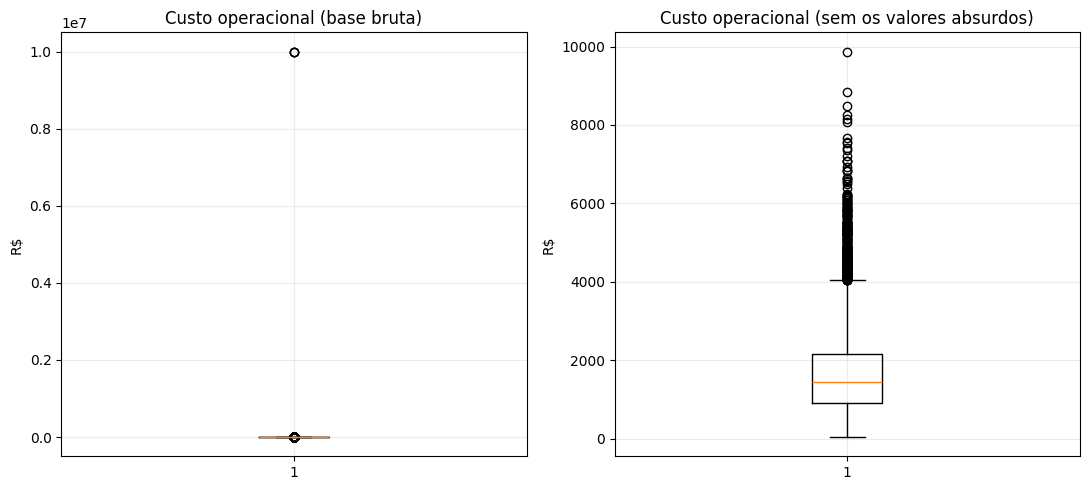

In [25]:
# Visualização do problema: com e sem os valores absurdos
marcar(7, "Efeito do outlier extremo na leitura do boxplot")

fig, eixos = plt.subplots(1, 2)

eixos[0].boxplot(df["custo_operacional_reais"].dropna(), vert=True)
eixos[0].set_title("Custo operacional (base bruta)")
eixos[0].set_ylabel("R$")

sem_absurdo = df[df["custo_operacional_reais"] < 1_000_000]["custo_operacional_reais"]
eixos[1].boxplot(sem_absurdo.dropna(), vert=True)
eixos[1].set_title("Custo operacional (sem os valores absurdos)")
eixos[1].set_ylabel("R$")

plt.tight_layout()
salvar_figura(7, "boxplot-custo")
plt.show()

O gráfico da esquerda é ilegível: três registros errados achatam toda a distribuição real
contra o eixo. É a demonstração visual de por que outlier extremo precisa ser tratado antes
de qualquer análise.

---
## 1.5 Limpeza e tratamento

O diagnóstico terminou. Agora cada problema recebe uma decisão, e **cada decisão precisa
de uma justificativa de negócio**, não apenas técnica.

Um princípio guia esta etapa:

> **Apague a célula, não a linha.**

Quando apenas um campo está inválido, remover a linha inteira joga fora dezenas de
informações válidas. Só removemos a linha quando o registro inteiro perde o sentido.

| # | Problema | Decisão | Justificativa |
|---|---|---|---|
| 1 | Duplicatas exatas | Remover a linha | Reenvio de lote. Manter infla todas as contagens |
| 2 | `fonte_dado` sem padrão | Padronizar o texto | São 5 fontes, não 10. Agrupamento depende disso |
| 3 | `bairro` nulo | Preencher com "Não Informado" | O resto do registro é válido e útil |
| 4 | `score_prioridade` = 999 | Converter para nulo | Valor sentinela. Não dá para inventar o score real |
| 5 | `satisfacao_cidadao` = 9 | Converter para nulo | Fora da escala 1 a 5. Entraria na média |
| 6 | `tempo_resposta_min` negativo | Converter para nulo | Relógio dessincronizado. O sinal não é recuperável com segurança |
| 7 | Encerramento antes da abertura | Anular as métricas de tempo | Sequência impossível. Os demais campos seguem válidos |
| 8 | Abertura em data futura | Remover a linha | Sem data confiável, o registro não se posiciona no tempo |
| 9 | Custo absurdo | Converter para nulo | Erro de digitação em ordem de serviço |

In [26]:
# Trabalhamos sobre uma cópia, preservando df para comparação posterior
dfc = df.copy()
registro_limpeza = []   # guarda o efeito de cada etapa para o relatório final


def registrar(etapa, afetados, linhas_antes, linhas_depois):
    registro_limpeza.append({
        "etapa": etapa,
        "registros_afetados": afetados,
        "linhas_antes": linhas_antes,
        "linhas_depois": linhas_depois
    })
    print(f"{etapa}: {afetados} registro(s) tratado(s) | linhas: {linhas_antes:,} -> {linhas_depois:,}")

### Etapa 1 — Remover duplicatas exatas

In [27]:
antes = len(dfc)
qtd = dfc.duplicated().sum()
dfc = dfc.drop_duplicates()
registrar("1. Duplicatas removidas", qtd, antes, len(dfc))

# Confirmação
print(f"Duplicatas restantes: {dfc.duplicated().sum()}")

1. Duplicatas removidas: 180 registro(s) tratado(s) | linhas: 10,180 -> 10,000
Duplicatas restantes: 0


### Etapa 2 — Padronizar a coluna `fonte_dado`

Três operações encadeadas: remover espaços das pontas, converter para maiúsculas e
trocar espaços internos por sublinhado.

In [28]:
antes = len(dfc)
rotulos_antes = dfc["fonte_dado"].nunique()

dfc["fonte_dado"] = (
    dfc["fonte_dado"]
    .str.strip()
    .str.upper()
    .str.replace(" ", "_", regex=False)
)

registrar("2. fonte_dado padronizada", rotulos_antes - dfc["fonte_dado"].nunique(), antes, len(dfc))
print(f"Rótulos: {rotulos_antes} -> {dfc['fonte_dado'].nunique()}")
print(dfc["fonte_dado"].value_counts())

2. fonte_dado padronizada: 5 registro(s) tratado(s) | linhas: 10,000 -> 10,000
Rótulos: 10 -> 5
fonte_dado
APP_MOBILE      2832
TELEFONE_156    2279
SENSOR_IOT      1978
PORTAL_WEB      1729
CAMERA_HD       1182
Name: count, dtype: int64


### Etapa 3 — Bairro não informado

Mesma decisão adotada no exercício guiado: o registro continua útil para análises de
tempo, categoria e fonte. Apagá-lo seria perder informação boa por causa de um campo.

In [29]:
antes = len(dfc)
qtd = dfc["bairro"].isnull().sum()

dfc["bairro"] = dfc["bairro"].fillna("Não Informado")

registrar("3. bairro nulo preenchido", qtd, antes, len(dfc))
print(f"Nulos restantes em bairro: {dfc['bairro'].isnull().sum()}")

3. bairro nulo preenchido: 120 registro(s) tratado(s) | linhas: 10,000 -> 10,000
Nulos restantes em bairro: 0


### Etapa 4 — Score de prioridade fora da faixa

In [30]:
antes = len(dfc)
mascara = dfc["score_prioridade"] > 100
qtd = mascara.sum()

dfc.loc[mascara, "score_prioridade"] = np.nan

registrar("4. score_prioridade = 999 anulado", qtd, antes, len(dfc))
print(f"Faixa atual do score: {dfc['score_prioridade'].min():.0f} a {dfc['score_prioridade'].max():.0f}")

4. score_prioridade = 999 anulado: 50 registro(s) tratado(s) | linhas: 10,000 -> 10,000
Faixa atual do score: 1 a 100


### Etapa 5 — Avaliação fora da escala

In [31]:
antes = len(dfc)
mascara = ~dfc["satisfacao_cidadao"].isin([1, 2, 3, 4, 5]) & dfc["satisfacao_cidadao"].notna()
qtd = mascara.sum()

dfc.loc[mascara, "satisfacao_cidadao"] = np.nan

registrar("5. satisfacao fora da escala anulada", qtd, antes, len(dfc))
print("Valores válidos restantes:", sorted(dfc["satisfacao_cidadao"].dropna().unique()))

5. satisfacao fora da escala anulada: 40 registro(s) tratado(s) | linhas: 10,000 -> 10,000
Valores válidos restantes: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]


### Etapa 6 — Tempo de resposta negativo

Poderíamos aplicar o valor absoluto, supondo inversão de sinal. Mas isso é **suposição**,
não evidência: o relógio pode ter derivado alguns minutos ou algumas horas. Diante da
dúvida, anular é mais honesto que inventar.

In [32]:
antes = len(dfc)
mascara = dfc["tempo_resposta_min"] < 0
qtd = mascara.sum()

dfc.loc[mascara, "tempo_resposta_min"] = np.nan

registrar("6. tempo_resposta negativo anulado", qtd, antes, len(dfc))
print(f"Mínimo atual: {dfc['tempo_resposta_min'].min():.0f} min")

6. tempo_resposta negativo anulado: 30 registro(s) tratado(s) | linhas: 10,000 -> 10,000
Mínimo atual: 9 min


### Etapa 7 — Encerramento anterior à abertura

Aqui só as métricas de tempo são anuladas. Categoria, bairro, fonte e score continuam
válidos e seguem servindo para as demais análises.

In [33]:
antes = len(dfc)
mascara = dfc["dt_encerramento"] < dfc["dt_abertura"]
qtd = mascara.sum()

dfc.loc[mascara, ["dt_encerramento", "tempo_resolucao_horas"]] = np.nan
dfc.loc[mascara, "sla_cumprido"] = "NAO APURADO"

registrar("7. datas invertidas anuladas", qtd, antes, len(dfc))
print(f"Inconsistências restantes: {(dfc['dt_encerramento'] < dfc['dt_abertura']).sum()}")

7. datas invertidas anuladas: 38 registro(s) tratado(s) | linhas: 10,000 -> 10,000
Inconsistências restantes: 0


### Etapa 8 — Abertura em data futura

Este é o único caso de remoção de linha. Sem data confiável de abertura, o registro não
se posiciona na linha do tempo, e toda a análise temporal, a derivada e a integral
dependem disso.

In [34]:
antes = len(dfc)
LIMITE = pd.Timestamp("2026-09-30 23:59:59")
qtd = (dfc["dt_abertura"] > LIMITE).sum()

dfc = dfc[dfc["dt_abertura"] <= LIMITE]

registrar("8. registros com data futura removidos", qtd, antes, len(dfc))
print(f"Período coberto: {dfc['dt_abertura'].min().date()} a {dfc['dt_abertura'].max().date()}")

8. registros com data futura removidos: 20 registro(s) tratado(s) | linhas: 10,000 -> 9,980
Período coberto: 2024-10-01 a 2026-09-30


### Etapa 9 — Custo operacional absurdo

In [35]:
antes = len(dfc)
mascara = dfc["custo_operacional_reais"] > 1_000_000
qtd = mascara.sum()

dfc.loc[mascara, "custo_operacional_reais"] = np.nan

registrar("9. custo absurdo anulado", qtd, antes, len(dfc))
print(f"Novo máximo: R$ {dfc['custo_operacional_reais'].max():,.2f}")
print(f"Nova mediana: R$ {dfc['custo_operacional_reais'].median():,.2f}")

9. custo absurdo anulado: 3 registro(s) tratado(s) | linhas: 9,980 -> 9,980
Novo máximo: R$ 9,871.26
Nova mediana: R$ 1,441.13


---
## 1.6 Engenharia de atributos

A base guarda o **fato bruto**. Os indicadores que a análise precisa são **calculados** aqui,
e não gravados na planilha. Essa separação é uma boa prática: se a regra de cálculo mudar,
o dado de origem continua intacto.

Quatro atributos novos:

| Atributo | Cálculo | Para que serve |
|---|---|---|
| `lag_despacho_min` | abertura até despacho | Mede o **elo 2**, onde suspeitamos da quebra |
| `razao_sla` | tempo de resolução ÷ prazo prometido | Mede a promessa cumprida, não o tempo absoluto |
| `hora_do_dia` | hora da abertura | Identifica os picos de demanda |
| `dia_semana` | dia da semana da abertura | Separa rotina útil de fim de semana |

In [36]:
# Elo 2: quanto tempo a ocorrência espera até a equipe ser acionada
dfc["lag_despacho_min"] = (
    (dfc["dt_despacho"] - dfc["dt_abertura"]).dt.total_seconds() / 60
).round(1)

# Elo 4: razão entre o tempo gasto e o prazo prometido
# Valor 1.0 = prazo cumprido no limite. Acima de 1.0 = promessa quebrada
dfc["razao_sla"] = (dfc["tempo_resolucao_horas"] / dfc["sla_horas_previsto"]).round(3)

# Sazonalidade intradiária e semanal
dfc["hora_do_dia"] = dfc["dt_abertura"].dt.hour
dias = {0: "1-Seg", 1: "2-Ter", 2: "3-Qua", 3: "4-Qui", 4: "5-Sex", 5: "6-Sab", 6: "7-Dom"}
dfc["dia_semana"] = dfc["dt_abertura"].dt.dayofweek.map(dias)
dfc["mes_ano"] = dfc["dt_abertura"].dt.to_period("M").astype(str)

print("Atributos criados:")
dfc[["lag_despacho_min", "razao_sla", "hora_do_dia", "dia_semana", "mes_ano"]].head()

Atributos criados:


,lag_despacho_min,razao_sla,hora_do_dia,dia_semana,mes_ano
0,20.00,0.42,12,4-Qui,2024-12
1,21.00,0.85,16,3-Qua,2026-09
2,84.00,1.04,14,1-Seg,2026-02
3,34.00,1.35,10,3-Qua,2025-01
4,132.00,NaN,11,7-Dom,2025-09


In [37]:
# Sanidade dos novos atributos
print("lag_despacho_min:")
print(f"  mediana {dfc['lag_despacho_min'].median():.1f} min | máximo {dfc['lag_despacho_min'].max():.0f} min")
print()
print("razao_sla (finalizadas):")
print(f"  mediana {dfc['razao_sla'].median():.2f}")
print(f"  dentro do prazo (<= 1.0): {(dfc['razao_sla'] <= 1).sum():,} ocorrências")
print(f"  fora do prazo  (> 1.0): {(dfc['razao_sla'] > 1).sum():,} ocorrências")

lag_despacho_min:
  mediana 23.0 min | máximo 424 min

razao_sla (finalizadas):
  mediana 0.80
  dentro do prazo (<= 1.0): 5,002 ocorrências
  fora do prazo  (> 1.0): 2,855 ocorrências


---
## 1.7 Relatório da limpeza

O que mudou entre a base bruta e a base tratada.

In [38]:
marcar(8, "Relatório das 9 etapas de limpeza")

relatorio = pd.DataFrame(registro_limpeza)
relatorio

  CAPTURA 08  |  Relatório das 9 etapas de limpeza


,etapa,registros_afetados,linhas_antes,linhas_depois
0,1. Duplicatas removidas,180,10180,10000
1,2. fonte_dado padronizada,5,10000,10000
2,3. bairro nulo preenchido,120,10000,10000
3,4. score_prioridade = 999 anulado,50,10000,10000
4,5. satisfacao fora da escala anulada,40,10000,10000
5,6. tempo_resposta negativo anulado,30,10000,10000
6,7. datas invertidas anuladas,38,10000,10000
7,8. registros com data futura removidos,20,10000,9980
8,9. custo absurdo anulado,3,9980,9980


In [39]:
# Comparação direta entre antes e depois
marcar(9, "Base bruta x base tratada")

comparacao = pd.DataFrame({
    "Base bruta": [
        len(df_original),
        df_original.duplicated().sum(),
        df_original["fonte_dado"].nunique(),
        (df_original["score_prioridade"] > 100).sum(),
        (df_original["tempo_resposta_min"] < 0).sum(),
        df_original["bairro"].isnull().sum(),
        f"R$ {df_original['custo_operacional_reais'].max():,.0f}",
    ],
    "Base tratada": [
        len(dfc),
        dfc.duplicated().sum(),
        dfc["fonte_dado"].nunique(),
        (dfc["score_prioridade"] > 100).sum(),
        (dfc["tempo_resposta_min"] < 0).sum(),
        dfc["bairro"].isnull().sum(),
        f"R$ {dfc['custo_operacional_reais'].max():,.0f}",
    ]
}, index=[
    "Total de registros",
    "Registros duplicados",
    "Rótulos distintos de fonte",
    "Scores fora da faixa 0-100",
    "Tempos de resposta negativos",
    "Bairros nulos",
    "Custo máximo",
])
comparacao

  CAPTURA 09  |  Base bruta x base tratada


,Base bruta,Base tratada
Total de registros,10180,9980
Registros duplicados,180,0
Rótulos distintos de fonte,10,5
Scores fora da faixa 0-100,50,0
Tempos de resposta negativos,30,0
Bairros nulos,122,0
Custo máximo,"R$ 10,000,000","R$ 9,871"


In [40]:
perda = (1 - len(dfc) / len(df_original)) * 100
print(f"Base bruta ....... {len(df_original):,} registros")
print(f"Base tratada ..... {len(dfc):,} registros")
print(f"Perda de linhas .. {perda:.2f}%")
print()
print("A perda é baixa porque a maior parte dos problemas foi tratada no nível da célula,")
print("preservando as informações válidas de cada registro.")

Base bruta ....... 10,180 registros
Base tratada ..... 9,980 registros
Perda de linhas .. 1.96%

A perda é baixa porque a maior parte dos problemas foi tratada no nível da célula,
preservando as informações válidas de cada registro.


### Conclusão da Parte 1

A base saiu de **10.180 registros com nove tipos de inconsistência** para uma base tratada,
documentada e confiável.

Três decisões merecem destaque na avaliação:

1. **Nulo legítimo foi separado de nulo defeituoso.** As ocorrências em aberto foram
   preservadas, e elas são justamente as mais relevantes para um Centro de Operações.
2. **A limpeza atuou na célula, não na linha.** Isso preservou informação válida que uma
   limpeza apressada teria descartado.
3. **Cada decisão foi justificada pelo negócio.** Nenhum registro foi removido apenas por
   ser incômodo para o código.

A base está pronta para a análise estatística da Parte 2, em que os quatro elos da cadeia
de valor do COU serão testados um a um.

In [41]:
# Exporta a base tratada, insumo da Parte 2 e do dashboard
ARQUIVO_AJUSTADO = "cidade_alfa_ocorrencias_ajustado.xlsx"
dfc.to_excel(ARQUIVO_AJUSTADO, index=False)

print(f"Arquivo gerado: {ARQUIVO_AJUSTADO}")
print(f"{dfc.shape[0]:,} linhas x {dfc.shape[1]} colunas")

Arquivo gerado: cidade_alfa_ocorrencias_ajustado.xlsx
9,980 linhas x 34 colunas


---
---

# PARTE 2 — 2º Desafio: Análise estatística e investigação dos dados

A base está limpa. Agora começa a investigação.

### A pergunta desta parte

> **A cidade Alfa investiu em sensores inteligentes. Esse investimento chega até o cidadão?**

Para uma ocorrência sair do mundo real e virar serviço prestado, ela percorre quatro
elos. A cadeia é tão forte quanto o elo mais fraco, então cada um será testado
separadamente:

```
   ELO 1              ELO 2             ELO 3            ELO 4
  DETECÇÃO    →     DESPACHO     →    EXECUÇÃO    →   PERCEPÇÃO
 o sensor vê     a central aciona    a equipe         o cidadão
 o problema        a equipe           resolve           avalia
```

| Seção | Elo | Técnica estatística |
|---|---|---|
| 2.1 | — | Estatística descritiva |
| 2.2 | — | Amostragem, dimensionamento e intervalo de confiança |
| 2.3 | 1 | Teste t de Student (scipy e pingouin) |
| 2.4 | 2 | Correlação e qui-quadrado |
| 2.5 | 3 | ANOVA (scipy e pingouin) e V de Cramér |
| 2.6 | 4 | Correlação de Pearson, Spearman e Kendall, e regressão |
| 2.7 | — | Limites, derivadas e integrais com SymPy |
| 2.8 | — | Armadilhas estatísticas |

As ferramentas seguem as adotadas na disciplina: `scipy.stats` e `pingouin` para
inferência (Caps 13 e 14), `sympy` para cálculo simbólico (Caps 9 e 10) e o
dimensionamento amostral do Cap 12.

## 2.0 Ferramentas adicionais

O DataFrame `dfc`, tratado na Parte 1, continua em memória. Aqui entram apenas as
bibliotecas de estatística inferencial e de cálculo simbólico, além da paleta de
cores usada nos gráficos.

In [42]:
import sympy as smp
import scipy
import sklearn
from scipy import stats as st
from sklearn.model_selection import train_test_split

# O pingouin é a biblioteca que o material da disciplina adota (Caps 9, 10, 13 e 14).
# Ele entra como segunda opinião: todo resultado que produz também é calculado com o
# scipy. Por isso a importação é tolerante — se faltar em alguma máquina, o notebook
# continua rodando e nenhuma conclusão se perde.
try:
    import pingouin as pg
    PINGOUIN_OK = True
except Exception as erro:
    PINGOUIN_OK = False
    print(f"aviso: pingouin indisponível ({erro.__class__.__name__}). "
          "As leituras equivalentes do scipy seguem válidas.\n")

# ---------------------------------------------------------------------------
# Identidade visual UrbanIQ (paleta validada para daltonismo e contraste)
# ---------------------------------------------------------------------------
OURO, ROXO, TERRACOTA, AZUL, OLIVA = "#A07400", "#7B3FA5", "#CC3B14", "#3160C8", "#5E8A00"
CATEGORICA = [OURO, ROXO, TERRACOTA, AZUL, OLIVA]
TINTA, SUAVE, PAPEL = "#2E2A26", "#6E655B", "#F6F3EC"

plt.rcParams.update({
    "figure.figsize": (11, 5),
    "figure.facecolor": PAPEL,
    "axes.facecolor": PAPEL,
    "axes.edgecolor": SUAVE,
    "axes.labelcolor": TINTA,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.color": SUAVE,
    "text.color": TINTA,
    "xtick.color": SUAVE,
    "ytick.color": SUAVE,
    "legend.frameon": False,
})

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")


def col_pg(tabela, *nomes):
    """Devolve a primeira coluna existente entre os nomes informados.

    O pingouin mudou os nomes das colunas entre versões: o que era 'cohen-d',
    'p-val' e 'p-unc' virou 'cohen_d', 'p_val' e 'p_unc'. Esta função deixa o
    notebook funcionar nas duas versões.
    """
    for nome in nomes:
        if nome in tabela.columns:
            return tabela[nome]
    raise KeyError(f"nenhuma destas colunas existe: {nomes}")


print("Ferramentas da Parte 2 carregadas. Versões em uso:")
print(f"  pandas {pd.__version__} | numpy {np.__version__} | scipy {scipy.__version__}")
versao_pg = pg.__version__ if PINGOUIN_OK else "indisponível"
print(f"  pingouin {versao_pg} | sympy {smp.__version__} | scikit-learn {sklearn.__version__}")
print()
print(f"DataFrame herdado da Parte 1: {dfc.shape[0]:,} linhas x {dfc.shape[1]} colunas")

Ferramentas da Parte 2 carregadas. Versões em uso:
  pandas 3.0.2 | numpy 2.4.4 | scipy 1.17.1
  pingouin 0.6.1 | sympy 1.14.0 | scikit-learn 1.8.0

DataFrame herdado da Parte 1: 9,980 linhas x 34 colunas


---
## 2.1 Estatística descritiva

Antes de testar qualquer hipótese é preciso conhecer o comportamento das variáveis.
A descritiva responde três perguntas: qual é o valor típico, quanta variação existe
em torno dele, e a distribuição é simétrica ou puxada para um lado.

Essa última pergunta é a mais importante e a mais ignorada. Ela decide se a média
é uma medida honesta ou enganosa.

In [43]:
marcar(10, "Estatística descritiva das variáveis da cadeia")

variaveis = [
    "tempo_resposta_min", "lag_despacho_min", "tempo_resolucao_horas",
    "razao_sla", "score_prioridade", "satisfacao_cidadao",
]

descritiva = dfc[variaveis].describe().T
descritiva["assimetria"] = dfc[variaveis].skew()
descritiva["cv_%"] = (descritiva["std"] / descritiva["mean"] * 100).round(1)
descritiva.round(2)

  CAPTURA 10  |  Estatística descritiva das variáveis da cadeia


,count,mean,std,min,25%,50%,75%,max,assimetria,cv_%
tempo_resposta_min,"9,950.000",84.750,54.660,9.000,47.000,71.000,106.000,679.000,2.080,64.500
lag_despacho_min,"9,980.000",31.430,27.900,2.000,14.000,23.000,40.000,424.000,3.250,88.800
tempo_resolucao_horas,"7,857.000",33.340,34.920,0.630,10.710,22.330,43.870,461.810,3.020,104.700
razao_sla,"7,857.000",0.970,0.670,0.080,0.530,0.800,1.230,8.800,2.230,68.500
score_prioridade,"9,930.000",63.300,21.560,1.000,47.000,64.000,80.000,100.000,-0.130,34.100
satisfacao_cidadao,"5,485.000",3.220,0.860,1.000,3.000,3.000,4.000,5.000,-0.140,26.600


**Como ler esta tabela.**

O **coeficiente de variação** (`cv_%`) é o desvio padrão em proporção da média. Acima
de 50% indica um processo instável: o tempo de atendimento não é confiável, varia
demais de um caso para outro. Para uma central de operações, isso é um problema por
si só, independente da média estar boa.

A **assimetria** positiva revela que a média está sendo puxada por uma cauda de casos
extremos. Quando ela aparece, a **mediana descreve melhor o caso típico** do que a
média. É por isso que vamos reportar as duas.

  CAPTURA 11  |  Distribuição do tempo de resolução e dispersão por região


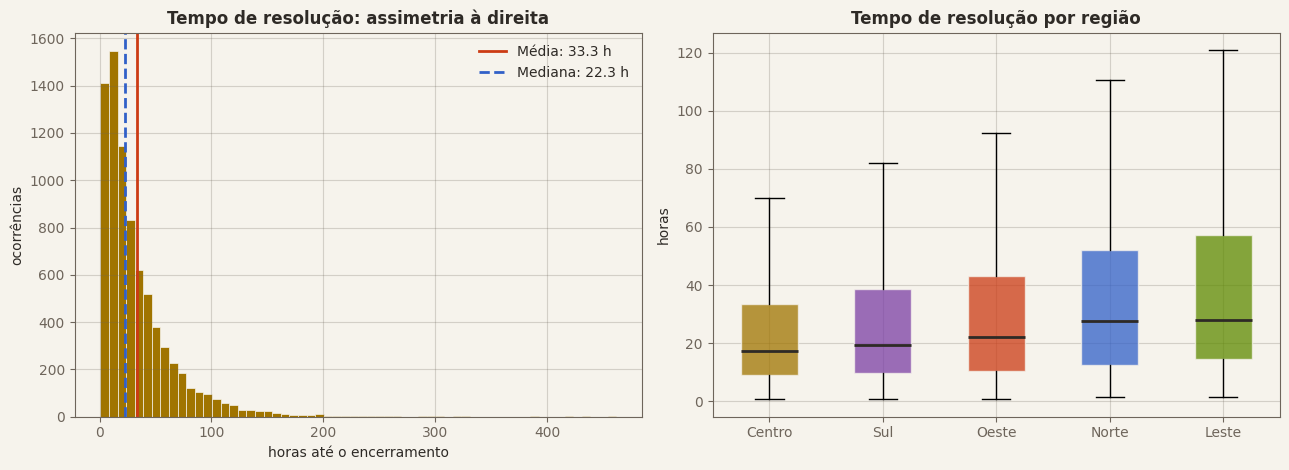

In [44]:
marcar(11, "Distribuição do tempo de resolução e dispersão por região")

fig, eixos = plt.subplots(1, 2, figsize=(13, 4.8))

# Esquerda: histograma com média e mediana marcadas
dados = dfc["tempo_resolucao_horas"].dropna()
eixos[0].hist(dados, bins=60, color=OURO, edgecolor=PAPEL, linewidth=0.5)
eixos[0].axvline(dados.mean(), color=TERRACOTA, linewidth=2,
                 label=f"Média: {dados.mean():.1f} h")
eixos[0].axvline(dados.median(), color=AZUL, linewidth=2, linestyle="--",
                 label=f"Mediana: {dados.median():.1f} h")
eixos[0].set_title("Tempo de resolução: assimetria à direita")
eixos[0].set_xlabel("horas até o encerramento")
eixos[0].set_ylabel("ocorrências")
eixos[0].legend()

# Direita: boxplot por região, ordenado pela mediana
ordem = dfc.groupby("regiao")["tempo_resolucao_horas"].median().sort_values().index
grupos = [dfc.loc[dfc.regiao == r, "tempo_resolucao_horas"].dropna() for r in ordem]
caixa = eixos[1].boxplot(grupos, labels=ordem, patch_artist=True, showfliers=False,
                         medianprops={"color": TINTA, "linewidth": 2})
for corpo, cor in zip(caixa["boxes"], CATEGORICA):
    corpo.set_facecolor(cor)
    corpo.set_alpha(0.75)
    corpo.set_edgecolor(PAPEL)
eixos[1].set_title("Tempo de resolução por região")
eixos[1].set_ylabel("horas")

plt.tight_layout()
salvar_figura(11, "descritiva-tempo-resolucao")
plt.show()

O histograma mostra a **média à direita da mediana**, a assinatura clássica de uma
distribuição assimétrica. A maioria das ocorrências resolve rápido, e uma minoria de
casos muito demorados puxa a média para cima.

O boxplot já antecipa o achado do **elo 3**: as regiões não se comportam igual. Essa
diferença visual será testada formalmente na seção 2.5.

---
## 2.2 Amostragem e intervalo de confiança

Um Centro de Operações real não processa a base inteira a cada consulta. A pergunta
prática do gestor é: **dá para decidir olhando uma amostra?**

Vamos comparar três estimativas do tempo médio de resolução:

| Estimativa | Como é obtida |
|---|---|
| População | Todas as ocorrências |
| Amostra aleatória simples | 400 sorteadas ao acaso |
| Amostra estratificada | 400 respeitando a proporção de cada região |

A estratificada tende a errar menos quando a variável de interesse difere entre os
estratos, que é exatamente o caso aqui.

### Quantas ocorrências a amostra precisa ter?

Antes de sortear, é preciso **dimensionar**. O tamanho da amostra para uma variável
contínua vem da fórmula:

$$n = \frac{Z^2 \cdot S^2 \cdot N}{ME^2 \cdot (N-1) + Z^2 \cdot S^2}$$

em que `N` é o tamanho da população, `Z` o valor da normal para o nível de confiança
(1,96 para 95%), `S` o desvio padrão obtido numa **amostra-piloto** e `ME` a margem
de erro aceita.

In [45]:
marcar(12, "Dimensionamento da amostra e comparação entre métodos")

SEMENTE = 570088
base = dfc.dropna(subset=["tempo_resolucao_horas"])
media_populacao = base["tempo_resolucao_horas"].mean()


def formula_amostra_continua(N, S, Z, ME):
    """Tamanho de amostra para variável contínua."""
    n = (Z**2 * S**2 * N) / ((ME**2 * (N - 1)) + (Z**2 * S**2))
    return int(np.ceil(n))


# Amostra-piloto: 10% da base, usada só para estimar o desvio padrão
piloto = base.sample(frac=0.10, random_state=SEMENTE)
S_piloto = piloto["tempo_resolucao_horas"].std(ddof=1)

N_populacao = len(base)
Z_95 = 1.96
MARGEM_ERRO = 1.5          # aceitamos errar até 1,5 hora na estimativa

TAMANHO = formula_amostra_continua(N_populacao, S_piloto, Z_95, MARGEM_ERRO)

print(f"População (N) ................ {N_populacao:,}")
print(f"Desvio padrão do piloto (S) .. {S_piloto:.2f} h   (piloto com {len(piloto)} ocorrências)")
print(f"Nível de confiança (Z) ....... {Z_95}  (95%)")
print(f"Margem de erro (ME) .......... {MARGEM_ERRO} h")
print(f"TAMANHO DA AMOSTRA (n) ....... {TAMANHO}")
print()
print(f"Basta analisar {TAMANHO / N_populacao * 100:.1f}% da base para estimar a média")
print(f"com erro de no máximo {MARGEM_ERRO} h e 95% de confiança.")
print()

# Amostra aleatória simples
simples = base.sample(n=TAMANHO, random_state=SEMENTE)

# Amostra estratificada proporcional por região.
# O train_test_split com o parâmetro stratify é o método do Cap 12: ele garante
# que cada região apareça na amostra na mesma proporção em que aparece na base.
_, estratificada = train_test_split(
    base,
    test_size=TAMANHO,
    random_state=SEMENTE,
    stratify=base["regiao"],
)

comparacao_amostras = pd.DataFrame({
    "n": [len(base), len(simples), len(estratificada)],
    "média (h)": [media_populacao,
                  simples["tempo_resolucao_horas"].mean(),
                  estratificada["tempo_resolucao_horas"].mean()],
}, index=["População", "Amostra simples", "Amostra estratificada"])

comparacao_amostras["erro vs população (h)"] = (
    comparacao_amostras["média (h)"] - media_populacao)
comparacao_amostras["erro relativo (%)"] = (
    comparacao_amostras["erro vs população (h)"] / media_populacao * 100)

comparacao_amostras.round(3)

  CAPTURA 12  |  Dimensionamento da amostra e comparação entre métodos
População (N) ................ 7,857
Desvio padrão do piloto (S) .. 34.02 h   (piloto com 786 ocorrências)
Nível de confiança (Z) ....... 1.96  (95%)
Margem de erro (ME) .......... 1.5 h
TAMANHO DA AMOSTRA (n) ....... 1580

Basta analisar 20.1% da base para estimar a média
com erro de no máximo 1.5 h e 95% de confiança.



,n,média (h),erro vs população (h),erro relativo (%)
População,7857,33.341,0.000,0.000
Amostra simples,1580,33.685,0.344,1.033
Amostra estratificada,1580,34.356,1.015,3.044


  CAPTURA 13  |  Intervalo de confiança de 95% e Teorema Central do Limite
Média da população .......... 33.34 h
Média da amostra (n=1580) .... 33.69 h
Erro padrão ................. 0.888 h
IC 95% ...................... [31.94 h , 35.43 h]
A população está dentro do intervalo? SIM


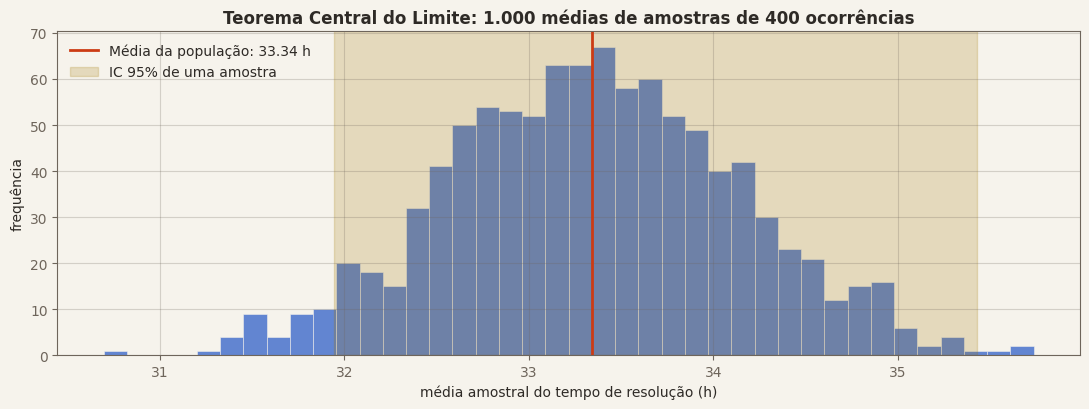

In [46]:
marcar(13, "Intervalo de confiança de 95% e Teorema Central do Limite")

# IC de 95% da amostra simples, via erro padrão da média
n = len(simples)
media_amostra = simples["tempo_resolucao_horas"].mean()
erro_padrao = simples["tempo_resolucao_horas"].std(ddof=1) / np.sqrt(n)
t_critico = st.t.ppf(0.975, df=n - 1)
ic_baixo, ic_alto = media_amostra - t_critico * erro_padrao, media_amostra + t_critico * erro_padrao

print(f"Média da população .......... {media_populacao:.2f} h")
print(f"Média da amostra (n={n}) .... {media_amostra:.2f} h")
print(f"Erro padrão ................. {erro_padrao:.3f} h")
print(f"IC 95% ...................... [{ic_baixo:.2f} h , {ic_alto:.2f} h]")
print(f"A população está dentro do intervalo? {'SIM' if ic_baixo <= media_populacao <= ic_alto else 'NAO'}")

# Distribuição de 1.000 médias amostrais: o TCL em ação
rng = np.random.default_rng(SEMENTE)
medias = [base["tempo_resolucao_horas"].sample(n=TAMANHO, random_state=int(rng.integers(1e6))).mean()
          for _ in range(1000)]

fig, eixo = plt.subplots(figsize=(11, 4.2))
eixo.hist(medias, bins=40, color=AZUL, alpha=0.75, edgecolor=PAPEL, linewidth=0.5)
eixo.axvline(media_populacao, color=TERRACOTA, linewidth=2,
             label=f"Média da população: {media_populacao:.2f} h")
eixo.axvspan(ic_baixo, ic_alto, color=OURO, alpha=0.20, label="IC 95% de uma amostra")
eixo.set_title("Teorema Central do Limite: 1.000 médias de amostras de 400 ocorrências")
eixo.set_xlabel("média amostral do tempo de resolução (h)")
eixo.set_ylabel("frequência")
eixo.legend()

plt.tight_layout()
salvar_figura(13, "amostragem-tcl")
plt.show()

**Conclusão da amostragem.** Mesmo com uma variável fortemente assimétrica, a
distribuição das médias amostrais é aproximadamente **normal e centrada no valor real**.
É o Teorema Central do Limite funcionando na prática.

A consequência para a gestão é concreta: **400 ocorrências bastam** para estimar o
tempo médio com margem estreita. O COU não precisa processar dez mil registros para
acompanhar o indicador no painel.

---
## 2.3 ELO 1 — Detecção

> **Hipótese do gestor:** sensores detectam ocorrências mais rápido que o cidadão.

Se isso for verdade, o investimento em IoT se justifica na ponta da detecção.

| | |
|---|---|
| **H₀** | O tempo de resposta é igual entre fontes automáticas e humanas |
| **H₁** | Os tempos são diferentes |
| **Teste** | t de Student para amostras independentes, variâncias desiguais (Welch) |
| **Significância** | α = 0,05 |

Uso a variante de Welch porque os dois grupos têm tamanhos e variâncias diferentes,
e ela não exige a suposição de variâncias iguais.

In [47]:
marcar(14, "ELO 1 — Teste t: fonte automática x canal humano")

automatica = dfc.loc[dfc.tipo_fonte == "AUTOMATICA", "tempo_resposta_min"].dropna()
cidadao = dfc.loc[dfc.tipo_fonte == "CIDADAO", "tempo_resposta_min"].dropna()

# Método 1: scipy.stats
t_stat, p_valor = st.ttest_ind(automatica, cidadao, equal_var=False, alternative="two-sided")

print(f"Fonte AUTOMATICA  n={len(automatica):>5}  média={automatica.mean():>6.1f} min  mediana={automatica.median():>6.1f} min")
print(f"Fonte CIDADAO     n={len(cidadao):>5}  média={cidadao.mean():>6.1f} min  mediana={cidadao.median():>6.1f} min")
print()
print(f"Diferença absoluta ....... {cidadao.mean() - automatica.mean():.1f} min")
print(f"Ganho relativo ........... {(1 - automatica.mean() / cidadao.mean()) * 100:.1f}%")
print()
print("--- scipy.stats.ttest_ind ---")
print(f"Estatística t ............ {t_stat:.2f}")
print(f"Valor-p .................. {p_valor:.3e}")
print()
print(f"DECISÃO: {'rejeitamos H0' if p_valor < 0.05 else 'não rejeitamos H0'} (α = 0,05)")
print("O ELO 1 FUNCIONA." if p_valor < 0.05 and automatica.mean() < cidadao.mean() else "O ELO 1 NÃO se confirma.")

  CAPTURA 14  |  ELO 1 — Teste t: fonte automática x canal humano
Fonte AUTOMATICA  n= 3149  média=  54.5 min  mediana=  47.0 min
Fonte CIDADAO     n= 6801  média=  98.8 min  mediana=  85.0 min

Diferença absoluta ....... 44.3 min
Ganho relativo ........... 44.8%

--- scipy.stats.ttest_ind ---
Estatística t ............ -49.59
Valor-p .................. 0.000e+00

DECISÃO: rejeitamos H0 (α = 0,05)
O ELO 1 FUNCIONA.


O `scipy.stats` entrega a estatística t e o valor-p. O **pingouin** entrega o mesmo
teste com informações que a decisão de gestão precisa: o **tamanho do efeito**
(`cohen-d`), o **intervalo de confiança da diferença** e o **poder do teste**.

Poder próximo de 1 significa risco baixo de Erro Tipo II, ou seja, de deixar de
detectar uma diferença que existe de verdade.

In [48]:
# Método 2: pingouin, com tamanho de efeito e poder
if PINGOUIN_OK:
    resultado_pg = pg.ttest(x=automatica, y=cidadao, alternative="two-sided",
                            confidence=0.95, correction=True)

    d_cohen = col_pg(resultado_pg, "cohen-d", "cohen_d").iloc[0]
    poder = resultado_pg["power"].iloc[0]

    print("--- pingouin.ttest ---")
    print(resultado_pg.round(4).to_string())
    print()
    print(f"d de Cohen ... {d_cohen:.3f}  "
          f"({'grande' if abs(d_cohen) >= 0.8 else 'médio' if abs(d_cohen) >= 0.5 else 'pequeno'})")
    print(f"Poder ........ {poder:.3f}  "
          f"({'risco baixo' if poder > 0.8 else 'atenção'} de Erro Tipo II)")
else:
    # Sem o pingouin, o d de Cohen sai direto do numpy. O teste t do scipy, na
    # célula anterior, já respondeu à pergunta; aqui se perde apenas o cálculo
    # automático do poder estatístico.
    n1, n2 = len(automatica), len(cidadao)
    dp_combinado = np.sqrt(((n1 - 1) * automatica.std(ddof=1) ** 2 +
                            (n2 - 1) * cidadao.std(ddof=1) ** 2) / (n1 + n2 - 2))
    d_cohen = (automatica.mean() - cidadao.mean()) / dp_combinado
    print(f"d de Cohen (numpy) ... {d_cohen:.3f}  "
          f"({'grande' if abs(d_cohen) >= 0.8 else 'médio' if abs(d_cohen) >= 0.5 else 'pequeno'})")

--- pingouin.ttest ---
             T       dof alternative  p_val              CI95  cohen_d  power BF10
T_test -49.595 9,690.997   two-sided  0.000  [-46.03, -42.53]    0.875  1.000  inf

d de Cohen ... 0.874  (grande)
Poder ........ 1.000  (risco baixo de Erro Tipo II)


  CAPTURA 15  |  ELO 1 — Distribuição do tempo de resposta por natureza da fonte


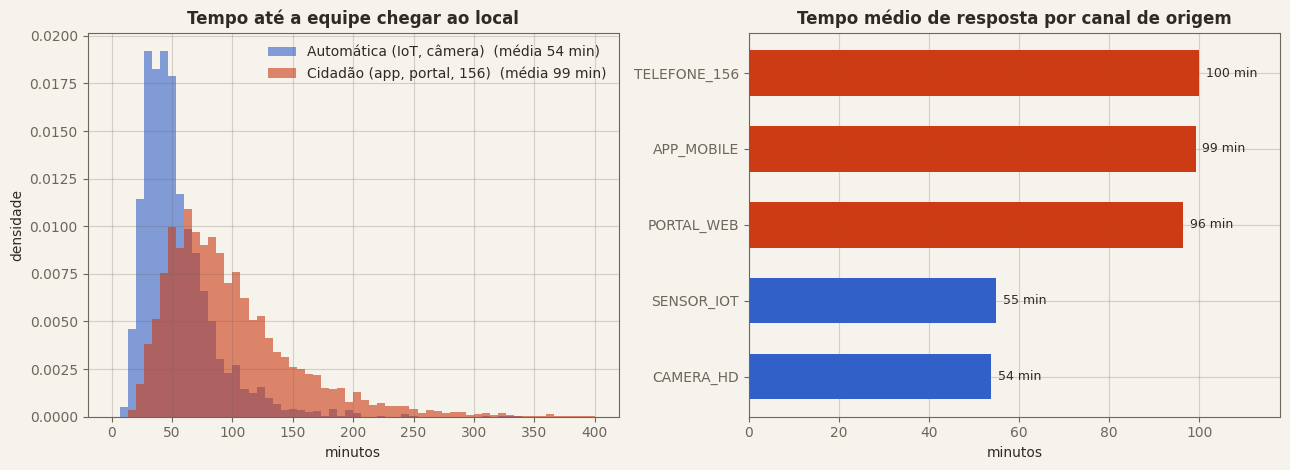

In [49]:
marcar(15, "ELO 1 — Distribuição do tempo de resposta por natureza da fonte")

fig, eixos = plt.subplots(1, 2, figsize=(13, 4.8))

# Esquerda: densidades sobrepostas
for serie, rotulo, cor in [(automatica, "Automática (IoT, câmera)", AZUL),
                           (cidadao, "Cidadão (app, portal, 156)", TERRACOTA)]:
    eixos[0].hist(serie, bins=60, range=(0, 400), alpha=0.6, color=cor,
                  label=f"{rotulo}  (média {serie.mean():.0f} min)", density=True)
eixos[0].set_title("Tempo até a equipe chegar ao local")
eixos[0].set_xlabel("minutos")
eixos[0].set_ylabel("densidade")
eixos[0].legend()

# Direita: média por canal específico, ordenada
por_canal = (dfc.groupby("fonte_dado")
               .agg(media=("tempo_resposta_min", "mean"),
                    tipo=("tipo_fonte", "first"))
               .sort_values("media"))
cores = [AZUL if t == "AUTOMATICA" else TERRACOTA for t in por_canal["tipo"]]
barras = eixos[1].barh(por_canal.index, por_canal["media"], color=cores, height=0.6)
for barra, valor in zip(barras, por_canal["media"]):
    eixos[1].text(valor + 1.5, barra.get_y() + barra.get_height() / 2,
                  f"{valor:.0f} min", va="center", color=TINTA, fontsize=9)
eixos[1].set_title("Tempo médio de resposta por canal de origem")
eixos[1].set_xlabel("minutos")
eixos[1].set_xlim(0, por_canal["media"].max() * 1.18)

plt.tight_layout()
salvar_figura(15, "elo1-deteccao")
plt.show()

**Conclusão do elo 1.** A hipótese se confirma com folga. A detecção automática chega
ao local em aproximadamente metade do tempo, e o tamanho do efeito é grande, ou seja,
a diferença não é apenas estatisticamente detectável, é operacionalmente relevante.

**O investimento em sensores entrega o que promete nesta etapa.** A pergunta passa a
ser se esse ganho sobrevive às etapas seguintes.

---
## 2.4 ELO 2 — Despacho

Este é o elo decisivo da análise. Duas perguntas:

**2.4a** O UrbanIQ calcula um `score_prioridade` de 0 a 100 para cada ocorrência.
A central usa esse score para decidir quem é acionado primeiro?

**2.4b** O ganho de tempo do sensor se converte em mais prazos cumpridos?

In [50]:
marcar(16, "ELO 2a — O score de prioridade influencia o tempo até o despacho?")

elo2 = dfc.dropna(subset=["score_prioridade", "lag_despacho_min"])

r_pearson, p_pearson = st.pearsonr(elo2["score_prioridade"], elo2["lag_despacho_min"])
r_spearman, p_spearman = st.spearmanr(elo2["score_prioridade"], elo2["lag_despacho_min"])

print(f"n = {len(elo2):,} ocorrências")
print()
print(f"Pearson  (relação linear)    r = {r_pearson:+.4f}   p = {p_pearson:.4f}")
print(f"Spearman (relação monótona)  r = {r_spearman:+.4f}   p = {p_spearman:.4f}")
print()
print(f"Variância explicada (r²) ... {r_pearson**2 * 100:.2f}%")
print()
if p_pearson >= 0.05:
    print("DECISÃO: não rejeitamos H0. NÃO HÁ relação detectável.")
    print("O score é calculado, mas NÃO é usado na fila de despacho.")
else:
    print(f"DECISÃO: relação estatisticamente detectável, porém {'fraca' if abs(r_pearson) < 0.3 else 'relevante'}.")

# Faixas de score para ver se existe algum degrau
elo2 = elo2.copy()
elo2["faixa_score"] = pd.cut(elo2["score_prioridade"], [0, 25, 50, 75, 100],
                             labels=["0-25 baixa", "26-50 média", "51-75 alta", "76-100 crítica"])
print()
print("Tempo mediano até o despacho por faixa de prioridade:")
print(elo2.groupby("faixa_score")["lag_despacho_min"].agg(
    n="size", mediana_min="median", media_min="mean").round(1))

  CAPTURA 16  |  ELO 2a — O score de prioridade influencia o tempo até o despacho?
n = 9,930 ocorrências

Pearson  (relação linear)    r = -0.0097   p = 0.3344
Spearman (relação monótona)  r = -0.0127   p = 0.2040

Variância explicada (r²) ... 0.01%

DECISÃO: não rejeitamos H0. NÃO HÁ relação detectável.
O score é calculado, mas NÃO é usado na fila de despacho.

Tempo mediano até o despacho por faixa de prioridade:
                   n  mediana_min  media_min
faixa_score                                 
0-25 baixa       409       22.000     31.300
26-50 média     2513       24.000     32.100
51-75 alta      3874       23.000     31.100
76-100 crítica  3134       23.000     31.300


In [51]:
marcar(17, "ELO 2b — A fonte do dado influencia o cumprimento do SLA?")

finalizadas = dfc[dfc["sla_cumprido"].isin(["SIM", "NAO"])]
tabela = pd.crosstab(finalizadas["tipo_fonte"], finalizadas["sla_cumprido"])

qui2, p_qui, gl, esperado = st.chi2_contingency(tabela)

# V de Cramér pela função do scipy (método do Cap 14)
v_cramer = st.contingency.association(tabela, method="cramer")

percentual = (tabela["SIM"] / tabela.sum(axis=1) * 100).round(1)

print("Tabela de contingência:")
print(tabela)
print()
print("% dentro do prazo:")
for indice, valor in percentual.items():
    print(f"  {indice:<12} {valor:.1f}%")
print()
print(f"Qui-quadrado ....... {qui2:.2f}   gl = {gl}")
print(f"Valor-p ............ {p_qui:.4f}")
print(f"V de Cramér ........ {v_cramer:.4f}  (0 = nenhuma associação, 1 = total)")
print()
if p_qui >= 0.05:
    print("DECISÃO: não rejeitamos H0. NÃO HÁ associação.")
    print("O ganho de 45 minutos na detecção NÃO se converte em prazo cumprido.")

  CAPTURA 17  |  ELO 2b — A fonte do dado influencia o cumprimento do SLA?
Tabela de contingência:
sla_cumprido   NAO   SIM
tipo_fonte              
AUTOMATICA     900  1579
CIDADAO       1957  3421

% dentro do prazo:
  AUTOMATICA   63.7%
  CIDADAO      63.6%

Qui-quadrado ....... 0.00   gl = 1
Valor-p ............ 0.9627
V de Cramér ........ 0.0008  (0 = nenhuma associação, 1 = total)

DECISÃO: não rejeitamos H0. NÃO HÁ associação.
O ganho de 45 minutos na detecção NÃO se converte em prazo cumprido.


  CAPTURA 18  |  ELO 2 — Onde o ganho do sensor se perde


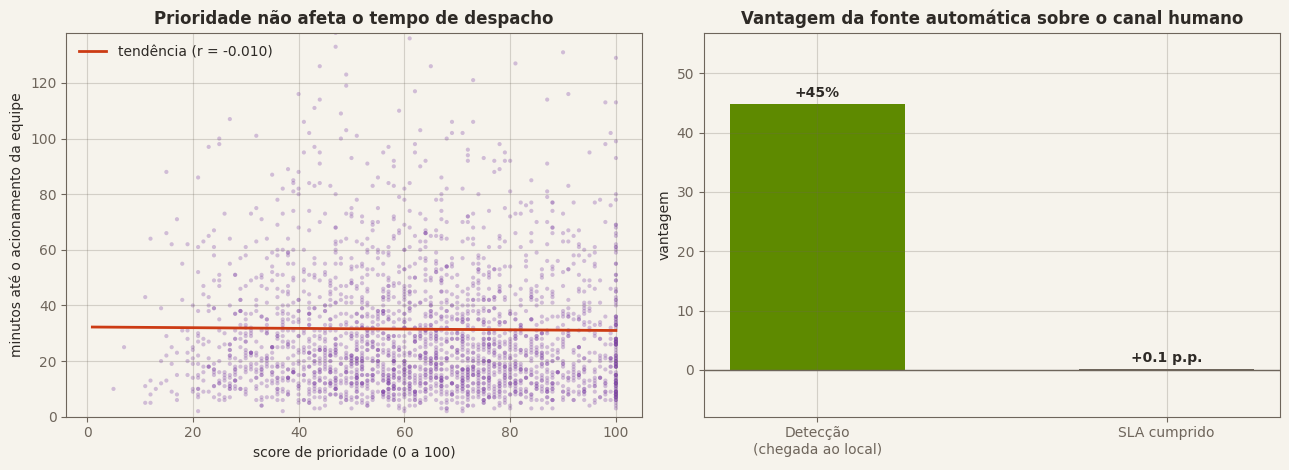

In [52]:
marcar(18, "ELO 2 — Onde o ganho do sensor se perde")

fig, eixos = plt.subplots(1, 2, figsize=(13, 4.8))

# Esquerda: score x lag de despacho, com a reta de tendência
amostra_grafico = elo2.sample(n=min(2500, len(elo2)), random_state=570088)
eixos[0].scatter(amostra_grafico["score_prioridade"], amostra_grafico["lag_despacho_min"],
                 s=9, alpha=0.30, color=ROXO, edgecolors="none")
coef = np.polyfit(elo2["score_prioridade"], elo2["lag_despacho_min"], 1)
linha_x = np.array([elo2["score_prioridade"].min(), elo2["score_prioridade"].max()])
eixos[0].plot(linha_x, np.polyval(coef, linha_x), color=TERRACOTA, linewidth=2,
              label=f"tendência (r = {r_pearson:+.3f})")
eixos[0].set_title("Prioridade não afeta o tempo de despacho")
eixos[0].set_xlabel("score de prioridade (0 a 100)")
eixos[0].set_ylabel("minutos até o acionamento da equipe")
eixos[0].set_ylim(0, elo2["lag_despacho_min"].quantile(0.99))
eixos[0].legend()

# Direita: a cadeia, etapa por etapa
etapas = ["Detecção\n(chegada ao local)", "SLA cumprido"]
valores_auto = [automatica.mean(), percentual.get("AUTOMATICA", 0)]
valores_cid = [cidadao.mean(), percentual.get("CIDADAO", 0)]

# Normaliza para comparar em um mesmo eixo percentual de vantagem
vantagem = [
    (1 - automatica.mean() / cidadao.mean()) * 100,
    percentual.get("AUTOMATICA", 0) - percentual.get("CIDADAO", 0),
]
cores_vantagem = [OLIVA if v > 3 else SUAVE for v in vantagem]
barras = eixos[1].bar(etapas, vantagem, color=cores_vantagem, width=0.5)
for barra, valor in zip(barras, vantagem):
    eixos[1].text(barra.get_x() + barra.get_width() / 2, valor + 1.2,
                  f"{valor:+.1f} p.p." if abs(valor) < 20 else f"{valor:+.0f}%",
                  ha="center", color=TINTA, fontweight="bold")
eixos[1].axhline(0, color=SUAVE, linewidth=1)
eixos[1].set_title("Vantagem da fonte automática sobre o canal humano")
eixos[1].set_ylabel("vantagem")
eixos[1].set_ylim(min(vantagem) - 8, max(vantagem) + 12)

plt.tight_layout()
salvar_figura(18, "elo2-despacho")
plt.show()

### Conclusão do elo 2, o achado central da análise

Os dois testes convergem para o mesmo diagnóstico:

1. O `score_prioridade` **não tem relação detectável** com o tempo até o despacho. A
   central atende por ordem de chegada, e o motor de priorização é ignorado na fila.
2. A fonte do dado **não tem associação** com o cumprimento do SLA.

O gráfico da direita resume a história: a cidade ganha uma vantagem expressiva na
detecção e a **devolve por completo** na etapa seguinte.

**A cadeia quebra no elo 2.** O sensor é rápido, a cidade não é.

---
## 2.5 ELO 3 — Execução

A execução funciona, mas funciona igual para todos os bairros?

| | |
|---|---|
| **H₀** | O tempo de resolução é igual entre as cinco regiões |
| **H₁** | Pelo menos uma região difere das demais |
| **Teste** | ANOVA de um fator, complementada por qui-quadrado sobre o SLA |

A ANOVA compara mais de dois grupos de uma vez. Usar vários testes t aos pares
inflaria a chance de falso positivo, problema conhecido como comparações múltiplas.

In [53]:
marcar(19, "ELO 3 — ANOVA e desigualdade territorial no cumprimento do SLA")

grupos_regiao = [dfc.loc[dfc.regiao == r, "tempo_resolucao_horas"].dropna()
                 for r in sorted(dfc["regiao"].unique())]

# Teste F pelo scipy
f_stat, p_anova = st.f_oneway(*grupos_regiao)

# Kruskal-Wallis: versão não paramétrica, robusta à assimetria observada em 2.1
h_stat, p_kruskal = st.kruskal(*grupos_regiao)

print("--- scipy.stats ---")
print(f"ANOVA (teste F)  F = {f_stat:.2f}    p = {p_anova:.3e}")
print(f"Kruskal-Wallis   H = {h_stat:.2f}    p = {p_kruskal:.3e}")
print(f"DECISÃO: {'rejeitamos H0, as regiões DIFEREM' if p_anova < 0.05 else 'não rejeitamos H0'}")
print()

# Mesma ANOVA pelo pingouin, que traz o tamanho de efeito (np2)
if PINGOUIN_OK:
    anova_pg = pg.anova(dv="tempo_resolucao_horas", between="regiao",
                        data=dfc.dropna(subset=["tempo_resolucao_horas"]), detailed=True)
    print("--- pingouin.anova ---")
    print(anova_pg.round(4).to_string(index=False))
    print()

finalizadas_regiao = dfc[dfc["sla_cumprido"].isin(["SIM", "NAO"])]
tabela_regiao = pd.crosstab(finalizadas_regiao["regiao"], finalizadas_regiao["sla_cumprido"])
qui2_r, p_r, gl_r, _ = st.chi2_contingency(tabela_regiao)
v_cramer_r = st.contingency.association(tabela_regiao, method="cramer")

painel_regiao = pd.DataFrame({
    "ocorrências": dfc.groupby("regiao").size(),
    "tempo_resolução_mediano_h": dfc.groupby("regiao")["tempo_resolucao_horas"].median(),
    "tempo_resposta_médio_min": dfc.groupby("regiao")["tempo_resposta_min"].mean(),
    "sla_cumprido_%": (tabela_regiao["SIM"] / tabela_regiao.sum(axis=1) * 100),
    "satisfação_média": dfc.groupby("regiao")["satisfacao_cidadao"].mean(),
}).sort_values("sla_cumprido_%", ascending=False)

print(f"Qui-quadrado região x SLA:  {qui2_r:.2f}   p = {p_r:.3e}   V de Cramér = {v_cramer_r:.3f}")
print()
amplitude = painel_regiao["sla_cumprido_%"].max() - painel_regiao["sla_cumprido_%"].min()
print(f"Amplitude entre a melhor e a pior região: {amplitude:.1f} pontos percentuais")
painel_regiao.round(2)

  CAPTURA 19  |  ELO 3 — ANOVA e desigualdade territorial no cumprimento do SLA
--- scipy.stats ---
ANOVA (teste F)  F = 74.12    p = 9.148e-62
Kruskal-Wallis   H = 281.76    p = 9.293e-60
DECISÃO: rejeitamos H0, as regiões DIFEREM

--- pingouin.anova ---
Source            SS   DF         MS      F  p_unc   np2
regiao   348,510.480    4 87,127.620 74.123  0.000 0.036
Within 9,229,613.344 7852  1,175.447    NaN    NaN   NaN

Qui-quadrado região x SLA:  471.36   p = 1.046e-100   V de Cramér = 0.245

Amplitude entre a melhor e a pior região: 32.6 pontos percentuais


,ocorrências,tempo_resolução_mediano_h,tempo_resposta_médio_min,sla_cumprido_%,satisfação_média
regiao,,,,,
Centro,2060,17.230,65.820,80.410,3.510
Sul,1989,19.270,73.670,71.510,3.360
Oeste,1925,22.130,82.830,63.780,3.250
Norte,2045,27.540,97.700,54.060,3.060
Leste,1961,28.100,104.280,47.820,2.930


  CAPTURA 20  |  ELO 3 — Desempenho por região


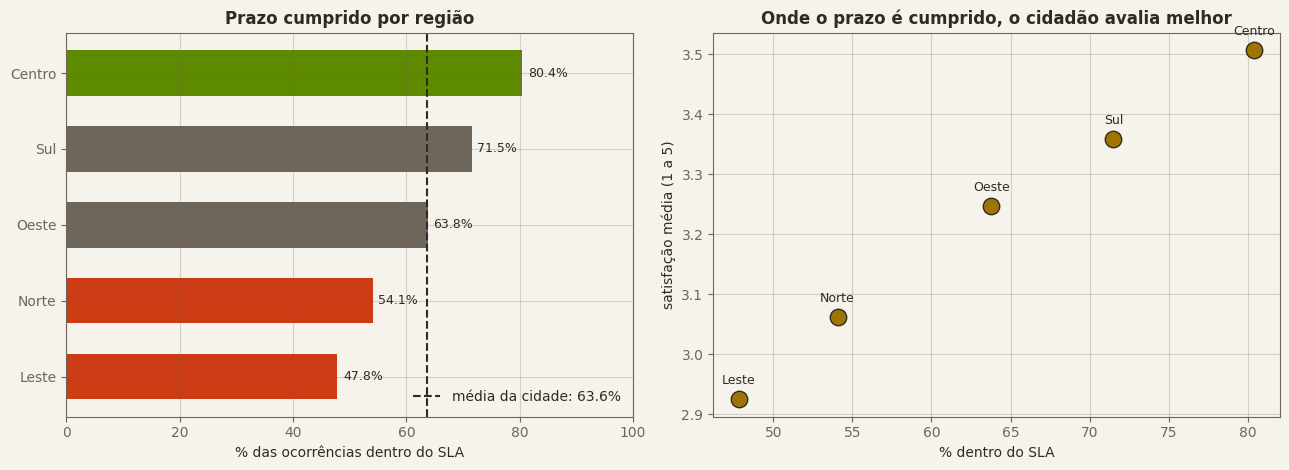

In [54]:
marcar(20, "ELO 3 — Desempenho por região")

fig, eixos = plt.subplots(1, 2, figsize=(13, 4.8))

ordenado = painel_regiao.sort_values("sla_cumprido_%")
media_cidade = (finalizadas_regiao["sla_cumprido"] == "SIM").mean() * 100

# Esquerda: SLA cumprido por região, destacando os extremos
cores_sla = [TERRACOTA if v < media_cidade - 8 else OLIVA if v > media_cidade + 8 else SUAVE
             for v in ordenado["sla_cumprido_%"]]
barras = eixos[0].barh(ordenado.index, ordenado["sla_cumprido_%"], color=cores_sla, height=0.6)
for barra, valor in zip(barras, ordenado["sla_cumprido_%"]):
    eixos[0].text(valor + 1, barra.get_y() + barra.get_height() / 2,
                  f"{valor:.1f}%", va="center", color=TINTA, fontsize=9)
eixos[0].axvline(media_cidade, color=TINTA, linestyle="--", linewidth=1.5,
                 label=f"média da cidade: {media_cidade:.1f}%")
eixos[0].set_title("Prazo cumprido por região")
eixos[0].set_xlabel("% das ocorrências dentro do SLA")
eixos[0].set_xlim(0, 100)
eixos[0].legend(loc="lower right")

# Direita: SLA x satisfação, evidenciando que o cidadão percebe
eixos[1].scatter(painel_regiao["sla_cumprido_%"], painel_regiao["satisfação_média"],
                 s=140, color=OURO, edgecolors=TINTA, linewidths=1, zorder=3)
for regiao, linha in painel_regiao.iterrows():
    eixos[1].annotate(regiao, (linha["sla_cumprido_%"], linha["satisfação_média"]),
                      textcoords="offset points", xytext=(0, 11),
                      ha="center", fontsize=9, color=TINTA)
eixos[1].set_title("Onde o prazo é cumprido, o cidadão avalia melhor")
eixos[1].set_xlabel("% dentro do SLA")
eixos[1].set_ylabel("satisfação média (1 a 5)")

plt.tight_layout()
salvar_figura(20, "elo3-execucao")
plt.show()

**Conclusão do elo 3.** A ANOVA e o Kruskal-Wallis concordam: as regiões diferem, e
a diferença não é ruído amostral.

A amplitude entre a melhor e a pior região é grande o bastante para ser tratada como
**desigualdade territorial no serviço público**, não como variação operacional. Duas
pessoas com o mesmo problema recebem serviços de qualidade muito diferente dependendo
de onde moram.

O gráfico da direita antecipa o elo 4: a satisfação acompanha o cumprimento do prazo.

---
## 2.6 ELO 4 — Percepção do cidadão

O que determina a nota que o cidadão dá: o **tempo absoluto** de atendimento ou a
**promessa cumprida**?

A diferença não é acadêmica. Ela decide a recomendação: "seja mais rápido" ou
"prometa prazos realistas".

  CAPTURA 21  |  ELO 4 — Matriz de correlação das variáveis da cadeia


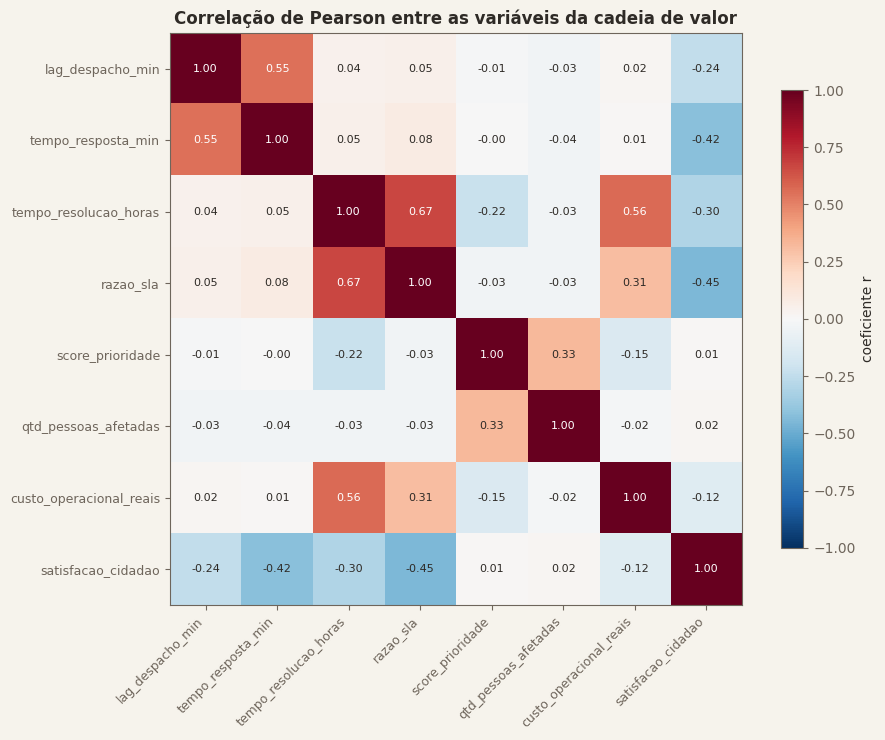


Correlações com a satisfação do cidadão, da mais forte para a mais fraca:
razao_sla                 -0.452
tempo_resposta_min        -0.419
tempo_resolucao_horas     -0.300
lag_despacho_min          -0.244
custo_operacional_reais   -0.125
qtd_pessoas_afetadas       0.022
score_prioridade           0.010
Name: satisfacao_cidadao, dtype: float64


In [55]:
marcar(21, "ELO 4 — Matriz de correlação das variáveis da cadeia")

variaveis_cadeia = [
    "lag_despacho_min", "tempo_resposta_min", "tempo_resolucao_horas",
    "razao_sla", "score_prioridade", "qtd_pessoas_afetadas",
    "custo_operacional_reais", "satisfacao_cidadao",
]
matriz = dfc[variaveis_cadeia].corr(method="pearson")

fig, eixo = plt.subplots(figsize=(9.5, 7.5))
imagem = eixo.imshow(matriz, cmap="RdBu_r", vmin=-1, vmax=1)

eixo.set_xticks(range(len(variaveis_cadeia)))
eixo.set_yticks(range(len(variaveis_cadeia)))
eixo.set_xticklabels(variaveis_cadeia, rotation=45, ha="right", fontsize=9)
eixo.set_yticklabels(variaveis_cadeia, fontsize=9)
eixo.grid(False)

for i in range(len(variaveis_cadeia)):
    for j in range(len(variaveis_cadeia)):
        valor = matriz.iloc[i, j]
        eixo.text(j, i, f"{valor:.2f}", ha="center", va="center", fontsize=8,
                  color="white" if abs(valor) > 0.55 else TINTA)

eixo.set_title("Correlação de Pearson entre as variáveis da cadeia de valor")
fig.colorbar(imagem, ax=eixo, shrink=0.8, label="coeficiente r")

plt.tight_layout()
salvar_figura(21, "elo4-matriz-correlacao")
plt.show()

print()
print("Correlações com a satisfação do cidadão, da mais forte para a mais fraca:")
print(matriz["satisfacao_cidadao"].drop("satisfacao_cidadao")
        .sort_values(key=abs, ascending=False).round(4))

### Os três coeficientes e o teste de significância

Pearson mede relação **linear**, Spearman e Kendall medem relação **monótona**, ou seja,
sobrevivem a relações curvas e são menos sensíveis a valores extremos. Comparar os três
é uma checagem de robustez: se os três concordam, a relação é sólida.

O `pingouin.pairwise_corr` acrescenta o que falta para decidir: intervalo de confiança,
valor-p e poder de cada correlação.

In [56]:
# Os três coeficientes lado a lado, com leitura facilitada por mapa de cores
for metodo in ["pearson", "spearman", "kendall"]:
    serie = (dfc[variaveis_cadeia].corr(method=metodo)["satisfacao_cidadao"]
               .drop("satisfacao_cidadao").sort_values(key=abs, ascending=False))
    print(f"--- {metodo.upper()} vs satisfacao_cidadao ---")
    print(serie.round(4).to_string())
    print()

# Matriz de Pearson com gradiente de cor (método do Cap 14)
dfc[variaveis_cadeia].corr().style.background_gradient(cmap="coolwarm").format("{:.2f}")

--- PEARSON vs satisfacao_cidadao ---
razao_sla                 -0.452
tempo_resposta_min        -0.419
tempo_resolucao_horas     -0.300
lag_despacho_min          -0.244
custo_operacional_reais   -0.125
qtd_pessoas_afetadas       0.022
score_prioridade           0.010

--- SPEARMAN vs satisfacao_cidadao ---
tempo_resposta_min        -0.439
razao_sla                 -0.409
tempo_resolucao_horas     -0.261
lag_despacho_min          -0.240
custo_operacional_reais   -0.099
qtd_pessoas_afetadas       0.027
score_prioridade           0.009

--- KENDALL vs satisfacao_cidadao ---
tempo_resposta_min        -0.344
razao_sla                 -0.319
tempo_resolucao_horas     -0.200
lag_despacho_min          -0.186
custo_operacional_reais   -0.075
qtd_pessoas_afetadas       0.021
score_prioridade           0.007



,lag_despacho_min,tempo_resposta_min,tempo_resolucao_horas,razao_sla,score_prioridade,qtd_pessoas_afetadas,custo_operacional_reais,satisfacao_cidadao
lag_despacho_min,1.00,0.55,0.04,0.05,-0.01,-0.03,0.02,-0.24
tempo_resposta_min,0.55,1.00,0.05,0.08,-0.00,-0.04,0.01,-0.42
tempo_resolucao_horas,0.04,0.05,1.00,0.67,-0.22,-0.03,0.56,-0.30
razao_sla,0.05,0.08,0.67,1.00,-0.03,-0.03,0.31,-0.45
score_prioridade,-0.01,-0.00,-0.22,-0.03,1.00,0.33,-0.15,0.01
qtd_pessoas_afetadas,-0.03,-0.04,-0.03,-0.03,0.33,1.00,-0.02,0.02
custo_operacional_reais,0.02,0.01,0.56,0.31,-0.15,-0.02,1.00,-0.12
satisfacao_cidadao,-0.24,-0.42,-0.30,-0.45,0.01,0.02,-0.12,1.00


In [57]:
# Teste de significância das correlações com a satisfação
if PINGOUIN_OK:
    teste_corr = pg.pairwise_corr(
        dfc[variaveis_cadeia],
        columns=[["satisfacao_cidadao"], ["razao_sla", "tempo_resposta_min",
                                          "tempo_resolucao_horas", "lag_despacho_min",
                                          "score_prioridade"]],
        method="pearson")

    resumo_corr = pd.DataFrame({
        "X": teste_corr["X"],
        "Y": teste_corr["Y"],
        "n": teste_corr["n"],
        "r": teste_corr["r"].round(4),
        "IC95%": col_pg(teste_corr, "CI95%", "CI95"),
        "valor_p": col_pg(teste_corr, "p-unc", "p_unc").apply(lambda v: f"{v:.2e}"),
        "poder": teste_corr["power"].round(3),
    })
    print(resumo_corr.to_string(index=False))
    print()
    print("Poder igual a 1 indica que o tamanho da amostra é mais que suficiente")
    print("para detectar a relação, se ela existir.")
else:
    # Sem o pingouin, as correlações e os valores p da célula seguinte, calculados
    # com scipy.stats.pearsonr, cumprem o mesmo papel.
    print("pingouin indisponível: o teste de significância sai pelo scipy logo abaixo.")

                 X                     Y    n      r          IC95%   valor_p  poder
satisfacao_cidadao             razao_sla 5469 -0.452 [-0.47, -0.43] 5.77e-274  1.000
satisfacao_cidadao    tempo_resposta_min 5467 -0.419  [-0.44, -0.4] 1.79e-231  1.000
satisfacao_cidadao tempo_resolucao_horas 5469 -0.300 [-0.32, -0.28] 6.12e-114  1.000
satisfacao_cidadao      lag_despacho_min 5485 -0.244 [-0.27, -0.22]  5.37e-75  1.000
satisfacao_cidadao      score_prioridade 5464  0.010  [-0.02, 0.04]  4.45e-01  0.119

Poder igual a 1 indica que o tamanho da amostra é mais que suficiente
para detectar a relação, se ela existir.


  CAPTURA 22  |  ELO 4 — Regressão: o que pesa mais, o tempo absoluto ou o prazo quebrado?
             variável    n  pearson_r  spearman_rho   r²_%  valor_p
            razao_sla 5469     -0.452        -0.409 20.451    0.000
   tempo_resposta_min 5467     -0.419        -0.439 17.560    0.000
tempo_resolucao_horas 5469     -0.300        -0.261  8.985    0.000
     lag_despacho_min 5485     -0.244        -0.240  5.940    0.000

Regressão linear: satisfacao_cidadao ~ razao_sla
  coeficiente angular ... -0.5793
  intercepto ............ 3.7870
  r² .................... 0.2045
  valor-p ............... 5.770e-274

Leitura: cada aumento de 1 unidade em razao_sla reduz a nota
do cidadão em 0.5793 ponto, na média.


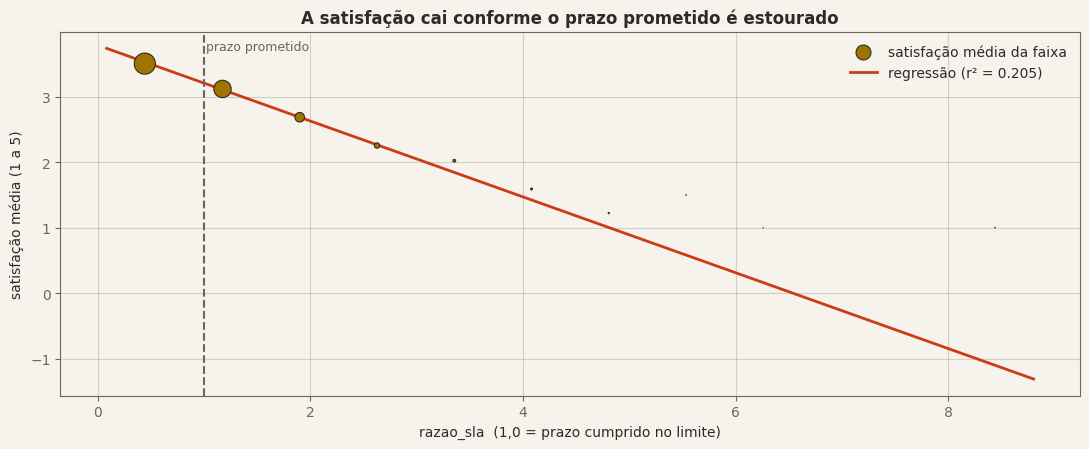

In [58]:
marcar(22, "ELO 4 — Regressão: o que pesa mais, o tempo absoluto ou o prazo quebrado?")

comparativo = []
for variavel in ["tempo_resposta_min", "tempo_resolucao_horas", "razao_sla", "lag_despacho_min"]:
    par = dfc[[variavel, "satisfacao_cidadao"]].dropna()
    r, p = st.pearsonr(par[variavel], par["satisfacao_cidadao"])
    rho, _ = st.spearmanr(par[variavel], par["satisfacao_cidadao"])
    comparativo.append({"variável": variavel, "n": len(par), "pearson_r": r,
                        "spearman_rho": rho, "r²_%": r**2 * 100, "valor_p": p})

comparativo = pd.DataFrame(comparativo).sort_values("pearson_r", key=abs, ascending=False)
print(comparativo.to_string(index=False))
print()

# Regressão linear sobre o vencedor
vencedora = comparativo.iloc[0]["variável"]
par = dfc[[vencedora, "satisfacao_cidadao"]].dropna()
regressao = st.linregress(par[vencedora], par["satisfacao_cidadao"])

print(f"Regressão linear: satisfacao_cidadao ~ {vencedora}")
print(f"  coeficiente angular ... {regressao.slope:+.4f}")
print(f"  intercepto ............ {regressao.intercept:.4f}")
print(f"  r² .................... {regressao.rvalue**2:.4f}")
print(f"  valor-p ............... {regressao.pvalue:.3e}")
print()
print(f"Leitura: cada aumento de 1 unidade em {vencedora} reduz a nota")
print(f"do cidadão em {abs(regressao.slope):.4f} ponto, na média.")

fig, eixo = plt.subplots(figsize=(11, 4.6))
faixas = pd.cut(par[vencedora], bins=12)
agrupado = par.groupby(faixas)["satisfacao_cidadao"].agg(["mean", "size"])
centros = [intervalo.mid for intervalo in agrupado.index]

eixo.scatter(centros, agrupado["mean"], s=agrupado["size"] / 12, color=OURO,
             edgecolors=TINTA, linewidths=0.8, zorder=3, label="satisfação média da faixa")
linha_x = np.linspace(par[vencedora].min(), par[vencedora].max(), 100)
eixo.plot(linha_x, regressao.intercept + regressao.slope * linha_x,
          color=TERRACOTA, linewidth=2, label=f"regressão (r² = {regressao.rvalue**2:.3f})")
eixo.axvline(1.0, color=SUAVE, linestyle="--", linewidth=1.5)
eixo.text(1.02, eixo.get_ylim()[1] * 0.97, "prazo prometido", fontsize=9,
          color=SUAVE, va="top")
eixo.set_title("A satisfação cai conforme o prazo prometido é estourado")
eixo.set_xlabel(f"{vencedora}  (1,0 = prazo cumprido no limite)")
eixo.set_ylabel("satisfação média (1 a 5)")
eixo.legend()

plt.tight_layout()
salvar_figura(22, "elo4-regressao")
plt.show()

**Conclusão do elo 4.** A `razao_sla` correlaciona mais forte com a satisfação do que
o tempo absoluto. O tamanho das bolhas no gráfico mostra onde está o volume de casos,
o que evita a leitura enganosa de faixas com poucos registros.

A tradução para a gestão é direta: **o cidadão não pune a demora, pune a promessa
quebrada.** Uma ocorrência de pavimentação resolvida em 60 horas com prazo de 72
satisfaz mais que uma de trânsito resolvida em 8 horas com prazo de 6.

---
## 2.7 Limites, derivadas e integrais aplicados

Três ferramentas do cálculo, cada uma respondendo a uma pergunta que a estatística
descritiva não alcança.

| Ferramenta | Pergunta que responde |
|---|---|
| **Derivada** | A demanda está acelerando? Quando? |
| **Integral** | Qual é o passivo acumulado que a cidade carrega? |
| **Limite** | Contratar mais equipes ainda compensa? |

### 2.7.1 Derivada — a demanda está acelerando?

O volume mensal diz **quanto** se tem. A derivada diz **para onde está indo**.

Um bairro com 200 ocorrências estáveis é menos urgente que um com 80 e aceleração
positiva.

Vamos obter a derivada de **duas formas**, e comparar:

| Abordagem | Ferramenta | Serve para |
|---|---|---|
| **Numérica** | `np.gradient` (diferenças finitas) | Medir a variação real, mês a mês |
| **Simbólica** | `sympy.diff` sobre uma função ajustada | Obter a expressão de f'(x) e achar máximos e mínimos |

A simbólica é a do Cap 9: transforma a variável em símbolo com `Symbol`, deriva com
`diff` e converte de volta para função Python com `lambdify`.

  CAPTURA 23  |  Derivada — taxa de variação do volume mensal de ocorrências


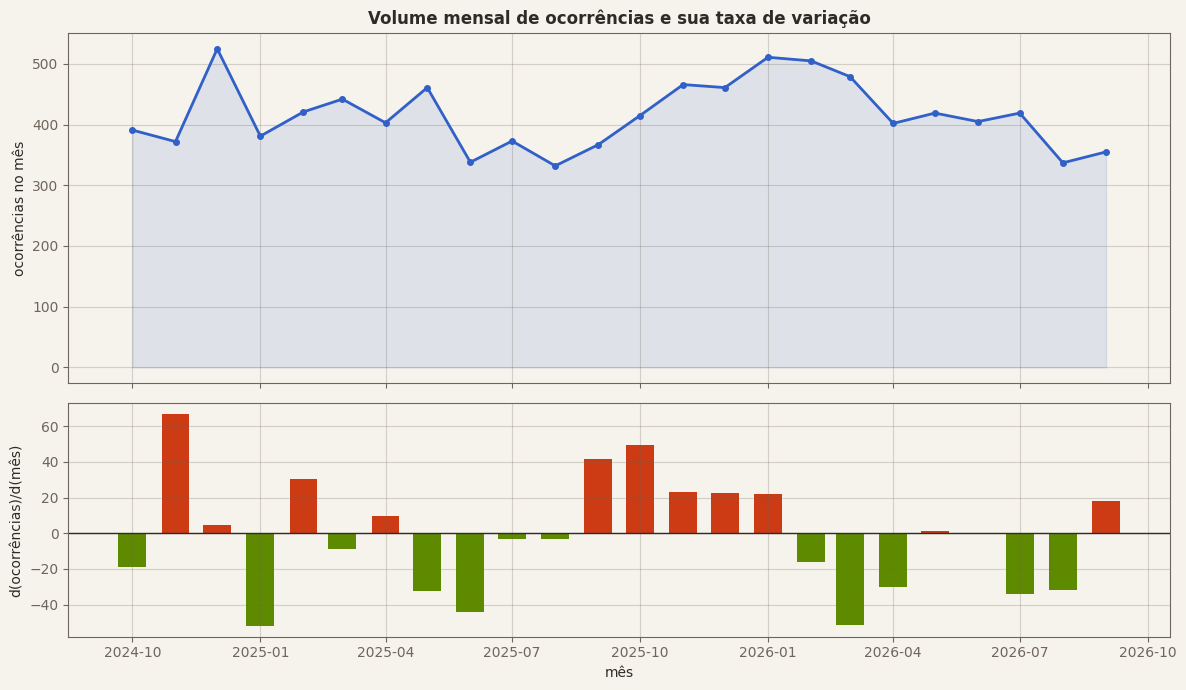

Maior aceleração da demanda: Nov/2024 (+67 ocorrências/mês)
Maior desaceleração:         Jan/2025 (-52 ocorrências/mês)

Uso operacional: a barra vermelha antecipa o pico. Um COU que monitora a
derivada mobiliza equipes ANTES do volume estourar, não depois.


In [59]:
marcar(23, "Derivada — taxa de variação do volume mensal de ocorrências")

serie_mensal = (dfc.set_index("dt_abertura")
                   .resample("MS")
                   .size()
                   .rename("ocorrencias"))

# Primeira derivada: variação de ocorrências por mês
derivada = np.gradient(serie_mensal.values.astype(float))

fig, eixos = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                          gridspec_kw={"height_ratios": [1.5, 1]})

eixos[0].plot(serie_mensal.index, serie_mensal.values, color=AZUL, linewidth=2,
              marker="o", markersize=4)
eixos[0].fill_between(serie_mensal.index, serie_mensal.values, color=AZUL, alpha=0.12)
eixos[0].set_title("Volume mensal de ocorrências e sua taxa de variação")
eixos[0].set_ylabel("ocorrências no mês")

cores_derivada = [OLIVA if v <= 0 else TERRACOTA for v in derivada]
eixos[1].bar(serie_mensal.index, derivada, color=cores_derivada, width=20)
eixos[1].axhline(0, color=TINTA, linewidth=1)
eixos[1].set_ylabel("d(ocorrências)/d(mês)")
eixos[1].set_xlabel("mês")

plt.tight_layout()
salvar_figura(23, "calculo-derivada")
plt.show()

pico = int(np.argmax(derivada))
print(f"Maior aceleração da demanda: {serie_mensal.index[pico]:%b/%Y} "
      f"({derivada[pico]:+.0f} ocorrências/mês)")
print(f"Maior desaceleração:         {serie_mensal.index[int(np.argmin(derivada))]:%b/%Y} "
      f"({derivada.min():+.0f} ocorrências/mês)")
print()
print("Uso operacional: a barra vermelha antecipa o pico. Um COU que monitora a")
print("derivada mobiliza equipes ANTES do volume estourar, não depois.")

f(x), volume de ocorrências em função do mês:
         3           2                       
- 0.088⋅x  + 2.7491⋅x  - 20.8907⋅x + 440.2248

f'(x), taxa de variação:
         2                     
- 0.264⋅x  + 5.4982⋅x - 20.8907

Ponto crítico em x = 5.0  ->  Mar/2025  ->  MÍNIMO (vale da demanda)


Ponto crítico em x = 15.8  ->  Feb/2026  ->  MÁXIMO (pico da demanda)


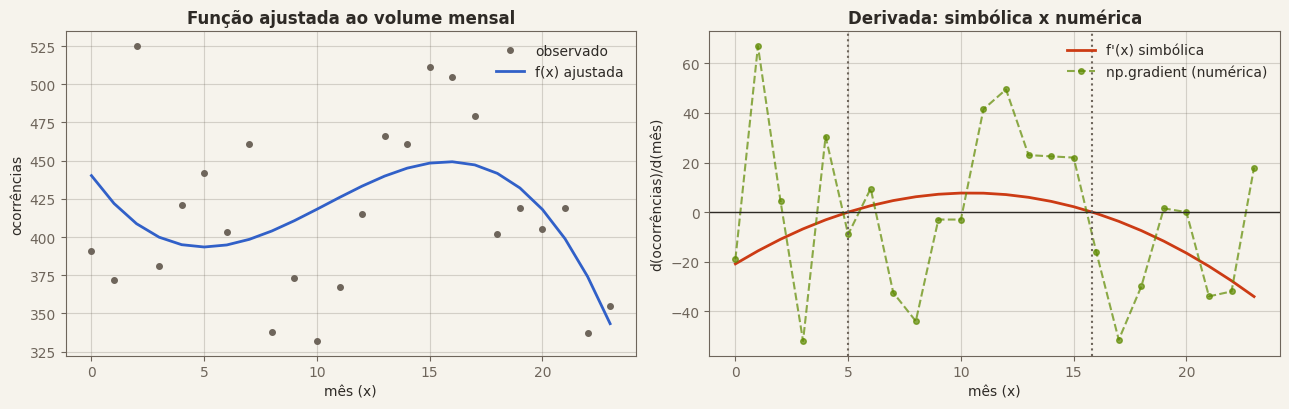

In [60]:
# --- Derivada SIMBÓLICA com SymPy (método do Cap 9) ---

# 1. Ajusta um polinômio de grau 3 à série mensal de ocorrências
meses = np.arange(len(serie_mensal), dtype=float)
coeficientes = np.polyfit(meses, serie_mensal.values.astype(float), 3)

# 2. Transforma a variável em SÍMBOLO e monta a função
x = smp.Symbol("x")
# Coeficientes arredondados: sem isso o SymPy imprime frações gigantes
funcao = sum(smp.Float(round(float(c), 4)) * x**(3 - i)
             for i, c in enumerate(coeficientes))

print("f(x), volume de ocorrências em função do mês:")
smp.pprint(smp.expand(funcao))
print()

# 3. Deriva simbolicamente
funcao_derivada = smp.diff(funcao, x)
print("f'(x), taxa de variação:")
smp.pprint(smp.expand(funcao_derivada))
print()

# 4. Pontos críticos: onde f'(x) = 0, a demanda para de subir ou de cair
criticos = smp.solve(funcao_derivada, x)
reais = [float(c) for c in criticos if c.is_real and 0 <= float(c) <= len(meses) - 1]
for ponto in reais:
    mes_critico = serie_mensal.index[int(round(ponto))]
    segunda = float(smp.diff(funcao, x, 2).subs(x, ponto))
    tipo = "MÁXIMO (pico da demanda)" if segunda < 0 else "MÍNIMO (vale da demanda)"
    print(f"Ponto crítico em x = {ponto:.1f}  ->  {mes_critico:%b/%Y}  ->  {tipo}")

# 5. lambdify converte a expressão simbólica em função Python utilizável
f_numerica = smp.lambdify(x, funcao, "numpy")
f_linha = smp.lambdify(x, funcao_derivada, "numpy")

fig, eixos = plt.subplots(1, 2, figsize=(13, 4.2))
eixos[0].plot(meses, serie_mensal.values, "o", color=SUAVE, markersize=4, label="observado")
eixos[0].plot(meses, f_numerica(meses), color=AZUL, linewidth=2, label="f(x) ajustada")
eixos[0].set_title("Função ajustada ao volume mensal")
eixos[0].set_xlabel("mês (x)")
eixos[0].set_ylabel("ocorrências")
eixos[0].legend()

eixos[1].plot(meses, f_linha(meses), color=TERRACOTA, linewidth=2, label="f'(x) simbólica")
eixos[1].plot(meses, derivada, "o--", color=OLIVA, markersize=4, alpha=0.7,
              label="np.gradient (numérica)")
eixos[1].axhline(0, color=TINTA, linewidth=1)
for ponto in reais:
    eixos[1].axvline(ponto, color=SUAVE, linestyle=":", linewidth=1.5)
eixos[1].set_title("Derivada: simbólica x numérica")
eixos[1].set_xlabel("mês (x)")
eixos[1].set_ylabel("d(ocorrências)/d(mês)")
eixos[1].legend()

plt.tight_layout()
salvar_figura(23, "calculo-derivada-sympy")
plt.show()

### 2.7.2 Integral — o passivo urbano acumulado

O backlog diário informa quantas ocorrências estão abertas hoje. A **área sob essa
curva** informa algo diferente e mais grave: quanto tempo total a cidade passou com
problemas em aberto.

A unidade resultante é **ocorrência-dia**, que traduzo como exposição acumulada da
população ao risco. Um KPI que não existe no painel atual e que um gestor entende
imediatamente.

A integral é aproximada pela regra dos trapézios.

  CAPTURA 24  |  Integral — backlog acumulado e exposição da população ao risco


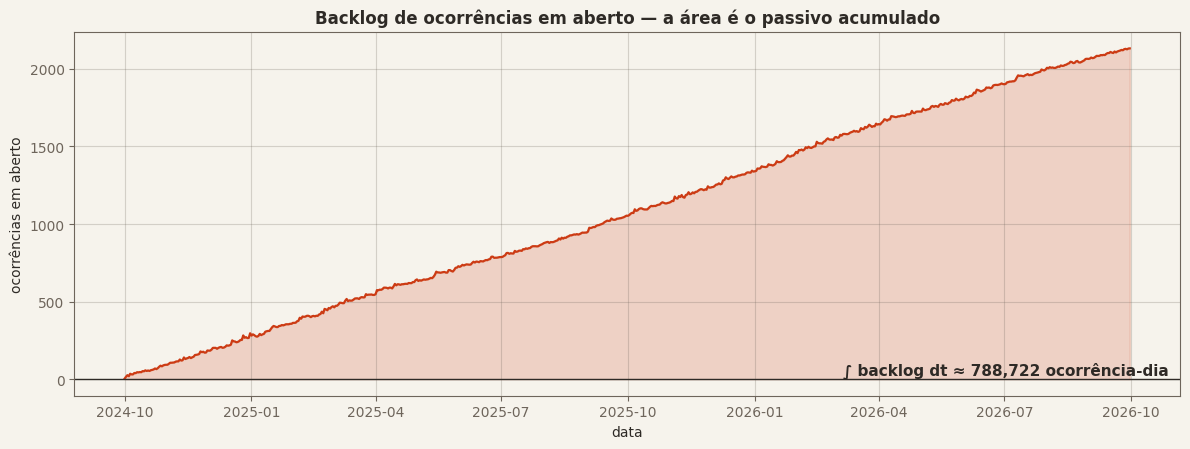

Backlog médio ................. 1,082 ocorrências
Backlog máximo ................ 2,132 ocorrências
Integral (área sob a curva) ... 788,722 ocorrência-dia
Período analisado ............. 730 dias


In [61]:
marcar(24, "Integral — backlog acumulado e exposição da população ao risco")

# Backlog diário: aberturas menos encerramentos, acumulado no tempo
aberturas = dfc.set_index("dt_abertura").resample("D").size()
encerramentos = dfc.dropna(subset=["dt_encerramento"]).set_index("dt_encerramento").resample("D").size()

calendario = pd.date_range(dfc["dt_abertura"].min().normalize(),
                           dfc["dt_abertura"].max().normalize(), freq="D")
fluxo = pd.DataFrame(index=calendario)
fluxo["abertas"] = aberturas.reindex(calendario, fill_value=0)
fluxo["encerradas"] = encerramentos.reindex(calendario, fill_value=0)
fluxo["backlog"] = (fluxo["abertas"] - fluxo["encerradas"]).cumsum()

dias = np.arange(len(fluxo), dtype=float)
integrar = np.trapezoid if hasattr(np, "trapezoid") else np.trapz   # numpy 2 renomeou trapz
area_total = integrar(fluxo["backlog"].values, dias)

fig, eixo = plt.subplots(figsize=(12, 4.6))
eixo.plot(fluxo.index, fluxo["backlog"], color=TERRACOTA, linewidth=1.6)
eixo.fill_between(fluxo.index, fluxo["backlog"], color=TERRACOTA, alpha=0.18)
eixo.axhline(0, color=TINTA, linewidth=1)
eixo.set_title("Backlog de ocorrências em aberto — a área é o passivo acumulado")
eixo.set_ylabel("ocorrências em aberto")
eixo.set_xlabel("data")
eixo.annotate(f"∫ backlog dt ≈ {area_total:,.0f} ocorrência-dia",
              xy=(0.99, 0.06), xycoords="axes fraction", ha="right",
              fontsize=11, color=TINTA, fontweight="bold")

plt.tight_layout()
salvar_figura(24, "calculo-integral")
plt.show()

print(f"Backlog médio ................. {fluxo['backlog'].mean():,.0f} ocorrências")
print(f"Backlog máximo ................ {fluxo['backlog'].max():,.0f} ocorrências")
print(f"Integral (área sob a curva) ... {area_total:,.0f} ocorrência-dia")
print(f"Período analisado ............. {len(fluxo)} dias")

### Os três métodos de integração, comparados

O Cap 10 apresenta a área sob a curva por dois caminhos: a **soma dos retângulos**,
que é a definição intuitiva, e a **integral simbólica** com `sympy.integrate`, que é
a forma exata. Vamos calcular pelos três e comparar os resultados.

Integral indefinida de B(t):
                       5                        4                        3     ↪
- 1.85445555057257e-9⋅t  + 3.20134856794545e-6⋅t  - 0.00180225627310522⋅t  + 1 ↪

↪                  2                    
↪ .83087207186065⋅t  - 11.490321170208⋅t

Soma dos retângulos (n=24) ...      819,176 ocorrência-dia
Regra dos trapézios ...............      788,722 ocorrência-dia
Integral simbólica (SymPy) ........      788,732 ocorrência-dia

Diferença retângulos x trapézios .. 3.86%
Diferença simbólica x trapézios ... 0.00%

Os três convergem. A soma dos retângulos superestima ou subestima conforme a
curva sobe ou desce no intervalo; quanto maior n, menor o erro.


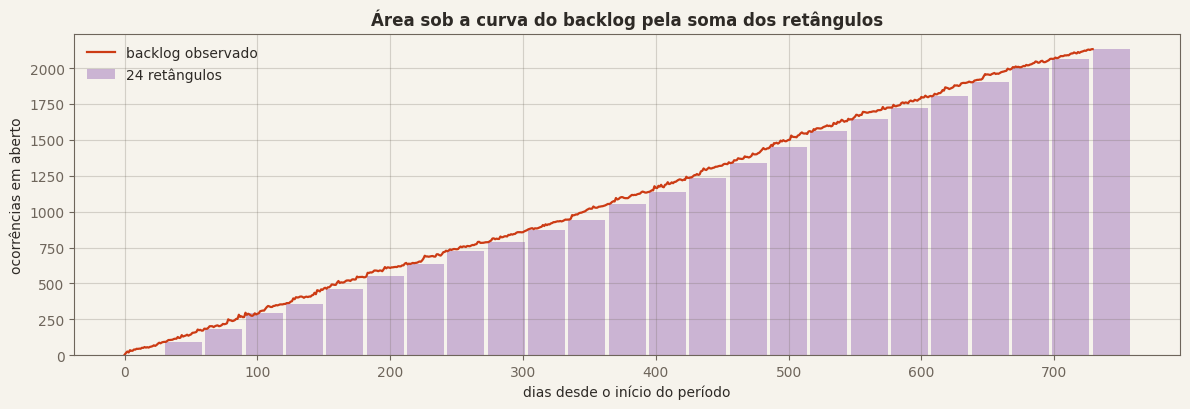

In [62]:
# --- Método 1: soma dos retângulos (definição do Cap 10) ---
N_RETANGULOS = 24
minimo, maximo = 0, len(fluxo) - 1
dx = (maximo - minimo) / N_RETANGULOS

eixo_x = np.arange(minimo, maximo + dx, dx)
eixo_y = np.interp(eixo_x, np.arange(len(fluxo)), fluxo["backlog"].values)

fx_dx = [altura * dx for altura in eixo_y]
area_retangulos = sum(fx_dx)

# --- Método 2: regra dos trapézios (numérica, já calculada acima) ---
# area_total

# --- Método 3: integral SIMBÓLICA com SymPy ---
coef_backlog = np.polyfit(np.arange(len(fluxo), dtype=float),
                          fluxo["backlog"].values.astype(float), 4)
t = smp.Symbol("t")
funcao_backlog = sum(float(c) * t**(4 - i) for i, c in enumerate(coef_backlog))

integral_indefinida = smp.integrate(funcao_backlog, t)
print("Integral indefinida de B(t):")
smp.pprint(smp.expand(integral_indefinida))
print()

area_simbolica = float(smp.integrate(funcao_backlog, (t, minimo, maximo)))

print(f"Soma dos retângulos (n={N_RETANGULOS}) ... {area_retangulos:>12,.0f} ocorrência-dia")
print(f"Regra dos trapézios ............... {area_total:>12,.0f} ocorrência-dia")
print(f"Integral simbólica (SymPy) ........ {area_simbolica:>12,.0f} ocorrência-dia")
print()
print(f"Diferença retângulos x trapézios .. {abs(area_retangulos - area_total) / area_total * 100:.2f}%")
print(f"Diferença simbólica x trapézios ... {abs(area_simbolica - area_total) / area_total * 100:.2f}%")
print()
print("Os três convergem. A soma dos retângulos superestima ou subestima conforme a")
print("curva sobe ou desce no intervalo; quanto maior n, menor o erro.")

# Visualização dos retângulos sob a curva, como no Cap 10
fig, eixo = plt.subplots(figsize=(12, 4.2))
eixo.bar(eixo_x, eixo_y, width=dx * 0.92, color=ROXO, alpha=0.35,
         align="edge", label=f"{N_RETANGULOS} retângulos")
eixo.plot(np.arange(len(fluxo)), fluxo["backlog"].values, color=TERRACOTA,
          linewidth=1.6, label="backlog observado")
eixo.set_title("Área sob a curva do backlog pela soma dos retângulos")
eixo.set_xlabel("dias desde o início do período")
eixo.set_ylabel("ocorrências em aberto")
eixo.legend()

plt.tight_layout()
salvar_figura(24, "calculo-integral-retangulos")
plt.show()

### 2.7.3 Limite — contratar mais equipes ainda compensa?

Modelo simples de fila com `n` equipes, em que `λ` é a taxa de chegada e `μ` a
capacidade de atendimento por equipe:

$$W(n) = \frac{1}{n\mu - \lambda}, \quad n\mu > \lambda$$

Três perguntas do cálculo, todas resolvidas com **SymPy**, como no Cap 9:

| Ferramenta | Pergunta | Comando |
|---|---|---|
| **Limite ao infinito** | Equipes infinitas zeram a fila? | `smp.limit(W, n, smp.oo)` |
| **Limite lateral** | O que acontece ao chegar perto da capacidade mínima? | `smp.limit(W, n, n_crítico, '+')` |
| **Derivada** | Quanto cada equipe adicional economiza? | `smp.diff(W, n)` |

O ponto de saturação é onde a derivada fica pequena demais para justificar o custo.
É a diferença entre "contratar resolve" e "contratar ainda resolve".

  CAPTURA 25  |  Limite — ponto de saturação do ganho por equipe adicional
Equipes em operação ................... 5
λ  chegadas por dia ................... 13.67
μ  vazão observada por equipe/dia ..... 2.15
Capacidade total atual (n·μ) .......... 10.76
Utilização do sistema (λ / n·μ) ....... 127.0%

ALERTA: a utilização passou de 100%. Chega mais do que sai, e por isso
o backlog da captura 24 cresce sem parar. São necessárias no mínimo
7 equipes só para ESTABILIZAR a fila, contra as 5 atuais.

W(n), tempo de espera em função do número de equipes:
       1       
───────────────
2.153⋅n - 13.67

lim(n->∞) W(n) = 0
  Com equipes infinitas a fila desaparece. Matematicamente verdadeiro,
  economicamente inútil: o custo também tende ao infinito.

lim(n->6.35+) W(n) = oo
  Ao se aproximar da capacidade mínima por cima, a espera tende ao infinito.
  É a assíntota vertical do sistema.

W'(n), ganho marginal por equipe adicional:
      -2.1526        
─────────────────────
                    

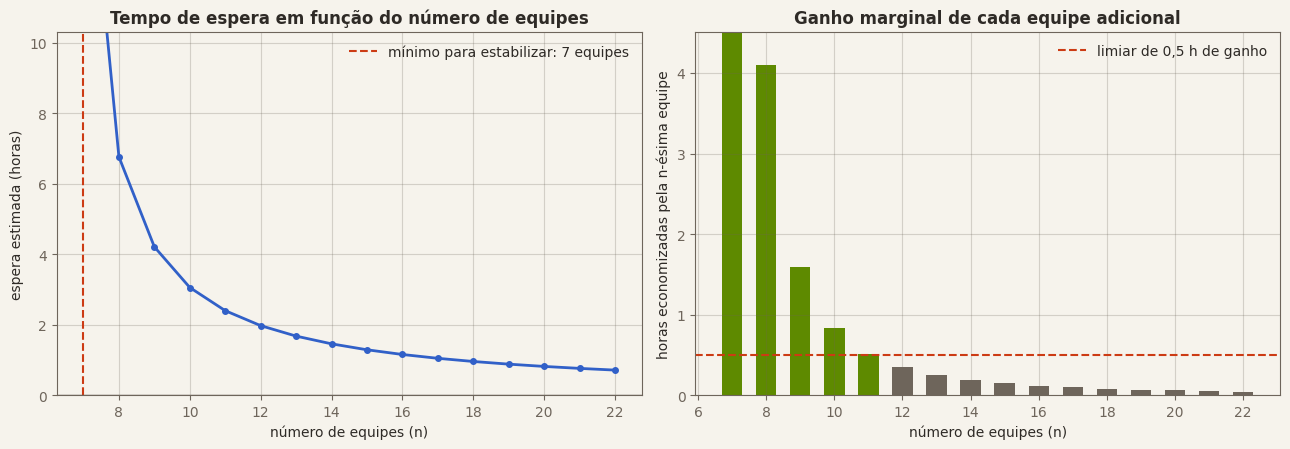

Ponto de saturação: a partir de 12 equipes, W'(n) indica ganho
menor que 0,5 h por equipe. Contratar além disso deixa de compensar.


In [63]:
marcar(25, "Limite — ponto de saturação do ganho por equipe adicional")

EQUIPES_ATUAIS = dfc["equipe_acionada"].nunique()

# λ: ocorrências que chegam por dia
lambda_chegada = len(dfc) / len(calendario)

# μ: capacidade REAL de uma equipe, medida pela vazão observada na base.
# Não uso 24/tempo_medio porque isso trataria a equipe como atendente serial,
# de uma ocorrência por vez. Uma guarnição toca vários chamados em paralelo,
# então a única medida honesta é o que elas de fato entregaram.
finalizadas_total = dfc["dt_encerramento"].notna().sum()
mu_capacidade = finalizadas_total / (EQUIPES_ATUAIS * len(calendario))

utilizacao = lambda_chegada / (EQUIPES_ATUAIS * mu_capacidade)
n_minimo = int(np.ceil(lambda_chegada / mu_capacidade))

print(f"Equipes em operação ................... {EQUIPES_ATUAIS}")
print(f"λ  chegadas por dia ................... {lambda_chegada:.2f}")
print(f"μ  vazão observada por equipe/dia ..... {mu_capacidade:.2f}")
print(f"Capacidade total atual (n·μ) .......... {EQUIPES_ATUAIS * mu_capacidade:.2f}")
print(f"Utilização do sistema (λ / n·μ) ....... {utilizacao:.1%}")
print()
if utilizacao >= 1:
    print(f"ALERTA: a utilização passou de 100%. Chega mais do que sai, e por isso")
    print(f"o backlog da captura 24 cresce sem parar. São necessárias no mínimo")
    print(f"{n_minimo} equipes só para ESTABILIZAR a fila, contra as {EQUIPES_ATUAIS} atuais.")
    print()

# --- Modelo simbólico com SymPy (método dos Caps 9 e 10) ---
n = smp.Symbol("n", positive=True)

# λ e μ entram como racionais exatos. Com float, o limite lateral devolve um
# número enorme em vez de infinito, por erro de arredondamento.
mu_s = smp.Rational(str(round(mu_capacidade, 6)))
lam_s = smp.Rational(str(round(lambda_chegada, 6)))

W = 1 / (n * mu_s - lam_s)                        # espera em dias

print("W(n), tempo de espera em função do número de equipes:")
smp.pprint(smp.N(W, 4))
print()

# LIMITE quando n tende ao infinito
limite_infinito = smp.limit(W, n, smp.oo)
print(f"lim(n->∞) W(n) = {limite_infinito}")
print("  Com equipes infinitas a fila desaparece. Matematicamente verdadeiro,")
print("  economicamente inútil: o custo também tende ao infinito.")
print()

# LIMITE quando n tende ao ponto crítico pela direita: a fila explode
n_critico_s = lam_s / mu_s
limite_critico = smp.limit(W, n, n_critico_s, "+")
print(f"lim(n->{float(n_critico_s):.2f}+) W(n) = {limite_critico}")
print("  Ao se aproximar da capacidade mínima por cima, a espera tende ao infinito.")
print("  É a assíntota vertical do sistema.")
print()

# DERIVADA: ganho marginal de cada equipe adicional
dW = smp.diff(W, n)
print("W'(n), ganho marginal por equipe adicional:")
# Versão só para exibição, com floats arredondados (a matemática usa a racional)
smp.pprint(-smp.Float(round(mu_capacidade, 4))
           / (smp.Float(round(mu_capacidade, 4)) * n
              - smp.Float(round(lambda_chegada, 4)))**2)
print()

# lambdify converte as expressões simbólicas em funções Python
espera_h = smp.lambdify(n, W * 24, "numpy")        # em horas
ganho_h = smp.lambdify(n, -dW * 24, "numpy")      # horas economizadas

# A curva só existe onde n·μ > λ, ou seja, a partir de n_minimo
n_equipes = np.arange(n_minimo, n_minimo + 16)
tempos = espera_h(n_equipes.astype(float))
ganho_marginal = ganho_h(n_equipes.astype(float))

fig, eixos = plt.subplots(1, 2, figsize=(13, 4.6))

eixos[0].plot(n_equipes, tempos, color=AZUL, linewidth=2, marker="o", markersize=4)
eixos[0].axvline(n_minimo, color=TERRACOTA, linestyle="--", linewidth=1.5,
                 label=f"mínimo para estabilizar: {n_minimo} equipes")
eixos[0].axhline(0, color=SUAVE, linewidth=1)
eixos[0].set_title("Tempo de espera em função do número de equipes")
eixos[0].set_xlabel("número de equipes (n)")
eixos[0].set_ylabel("espera estimada (horas)")
eixos[0].set_ylim(0, np.nanmax(tempos[tempos < np.inf]) * 0.6)
eixos[0].legend()

cores_ganho = [OLIVA if g and g > 0.5 else SUAVE for g in ganho_marginal]
eixos[1].bar(n_equipes, ganho_marginal, color=cores_ganho, width=0.6)
eixos[1].axhline(0.5, color=TERRACOTA, linestyle="--", linewidth=1.5,
                 label="limiar de 0,5 h de ganho")
eixos[1].set_title("Ganho marginal de cada equipe adicional")
eixos[1].set_xlabel("número de equipes (n)")
eixos[1].set_ylabel("horas economizadas pela n-ésima equipe")
eixos[1].set_ylim(0, np.nanmax(ganho_marginal[1:]) * 1.1)
eixos[1].legend()

plt.tight_layout()
salvar_figura(25, "calculo-limite")
plt.show()

saturacao = next((int(k) for k, g in zip(n_equipes, ganho_marginal) if g < 0.5), None)
if saturacao:
    print(f"Ponto de saturação: a partir de {saturacao} equipes, W'(n) indica ganho")
    print(f"menor que 0,5 h por equipe. Contratar além disso deixa de compensar.")

---
## 2.8 Armadilhas estatísticas

Três erros que um relatório apressado cometeria com esta mesma base. Reconhecê-los
vale mais que somar mais um teste.

In [64]:
marcar(26, "Armadilha 1 — correlações tautológicas")

tautologicas = [
    ("criticidade_sensor", "score_prioridade", "o score é CALCULADO a partir da criticidade"),
    ("sla_horas_previsto", "tempo_resolucao_horas", "categoria com prazo maior demora mais, por definição"),
    ("tempo_resolucao_horas", "razao_sla", "a razão é o tempo dividido pelo prazo"),
    ("qtd_pessoas_afetadas", "densidade_hab_km2", "bairro denso afeta mais gente, por construção"),
]

print(f"{'par de variáveis':<52} {'r':>7}   por que NÃO vale")
print("-" * 118)
for a, b, motivo in tautologicas:
    par = dfc[[a, b]].dropna()
    r, _ = st.pearsonr(par[a], par[b])
    print(f"{a + ' x ' + b:<52} {r:>+7.3f}   {motivo}")

print()
print("Todas têm r alto e nenhuma informa nada. São identidades matemáticas,")
print("não descobertas. Foram descartadas da análise por esse motivo.")

  CAPTURA 26  |  Armadilha 1 — correlações tautológicas
par de variáveis                                           r   por que NÃO vale
----------------------------------------------------------------------------------------------------------------------
criticidade_sensor x score_prioridade                 +0.786   o score é CALCULADO a partir da criticidade
sla_horas_previsto x tempo_resolucao_horas            +0.616   categoria com prazo maior demora mais, por definição
tempo_resolucao_horas x razao_sla                     +0.671   a razão é o tempo dividido pelo prazo
qtd_pessoas_afetadas x densidade_hab_km2              +0.411   bairro denso afeta mais gente, por construção

Todas têm r alto e nenhuma informa nada. São identidades matemáticas,
não descobertas. Foram descartadas da análise por esse motivo.


  CAPTURA 27  |  Armadilha 2 — falácia ecológica
Nível OCORRÊNCIA (n = 5,483)   r = -0.125   p = 2.08e-20
Nível BAIRRO     (n = 10)       r = -0.959   p = 1.17e-05

A mesma relação salta de 0.125 para 0.959 apenas por agregar.

Por quê: agregar elimina a variação individual e deixa só a tendência entre
grupos. A correlação infla artificialmente. Concluir algo sobre o cidadão a
partir do dado do bairro é a FALÁCIA ECOLÓGICA.


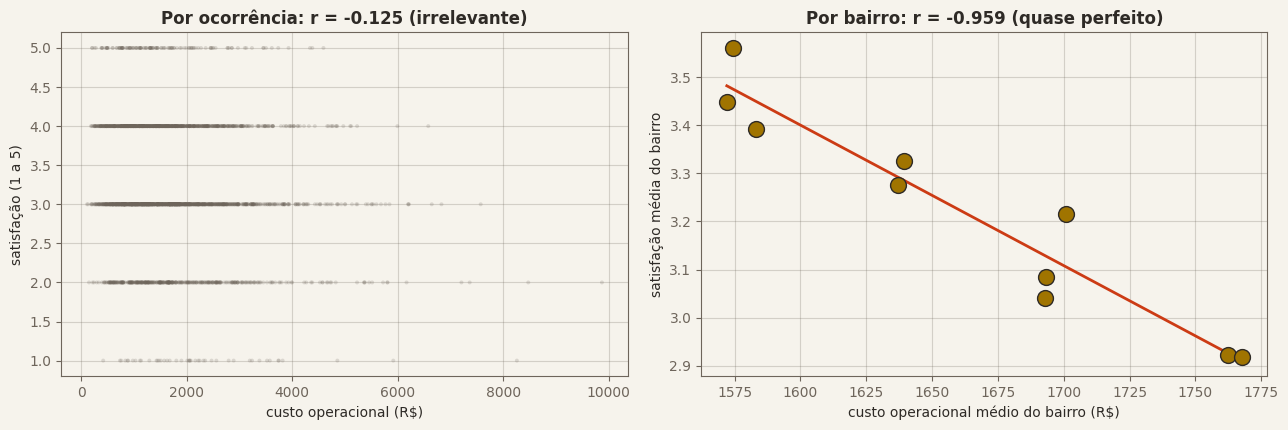

In [65]:
marcar(27, "Armadilha 2 — falácia ecológica")

# Mesma relação, medida em dois níveis de agregação diferentes
individual = dfc[["custo_operacional_reais", "satisfacao_cidadao"]].dropna()
r_individual, p_individual = st.pearsonr(individual["custo_operacional_reais"],
                                            individual["satisfacao_cidadao"])

# "Não Informado" não é um bairro real, sai da análise agregada
por_bairro = (dfc[dfc["bairro"] != "Não Informado"]
              .groupby("bairro")
              .agg(custo=("custo_operacional_reais", "mean"),
                   satisfacao=("satisfacao_cidadao", "mean"))
              .dropna())
r_agregado, p_agregado = st.pearsonr(por_bairro["custo"], por_bairro["satisfacao"])

print(f"Nível OCORRÊNCIA (n = {len(individual):,})   r = {r_individual:+.3f}   p = {p_individual:.2e}")
print(f"Nível BAIRRO     (n = {len(por_bairro):,})       r = {r_agregado:+.3f}   p = {p_agregado:.2e}")
print()
print(f"A mesma relação salta de {abs(r_individual):.3f} para {abs(r_agregado):.3f} apenas por agregar.")
print()
print("Por quê: agregar elimina a variação individual e deixa só a tendência entre")
print("grupos. A correlação infla artificialmente. Concluir algo sobre o cidadão a")
print("partir do dado do bairro é a FALÁCIA ECOLÓGICA.")

fig, eixos = plt.subplots(1, 2, figsize=(13, 4.4))

amostra_ind = individual.sample(n=min(2500, len(individual)), random_state=570088)
eixos[0].scatter(amostra_ind["custo_operacional_reais"], amostra_ind["satisfacao_cidadao"],
                 s=8, alpha=0.20, color=SUAVE, edgecolors="none")
eixos[0].set_title(f"Por ocorrência: r = {r_individual:+.3f} (irrelevante)")
eixos[0].set_xlabel("custo operacional (R$)")
eixos[0].set_ylabel("satisfação (1 a 5)")

eixos[1].scatter(por_bairro["custo"], por_bairro["satisfacao"], s=130, color=OURO,
                 edgecolors=TINTA, linewidths=1, zorder=3)
coef_b = np.polyfit(por_bairro["custo"], por_bairro["satisfacao"], 1)
linha_b = np.array([por_bairro["custo"].min(), por_bairro["custo"].max()])
eixos[1].plot(linha_b, np.polyval(coef_b, linha_b), color=TERRACOTA, linewidth=2)
eixos[1].set_title(f"Por bairro: r = {r_agregado:+.3f} (quase perfeito)")
eixos[1].set_xlabel("custo operacional médio do bairro (R$)")
eixos[1].set_ylabel("satisfação média do bairro")

plt.tight_layout()
salvar_figura(27, "armadilha-falacia-ecologica")
plt.show()

In [66]:
marcar(28, "Armadilha 3 — correlação espúria por confundimento")

# Temperatura parece explicar o volume... no agregado mensal
diario = pd.DataFrame({
    "volume": dfc.set_index("dt_abertura").resample("D").size(),
    "temperatura": dfc.set_index("dt_abertura")["temperatura_c"].resample("D").max(),
    "chuva": dfc.set_index("dt_abertura")["chuva_mm"].resample("D").max(),
}).dropna()

mensal = diario.resample("MS").mean()

r_dia, p_dia = st.pearsonr(diario["temperatura"], diario["volume"])
r_mes, p_mes = st.pearsonr(mensal["temperatura"], mensal["volume"])
r_tc, _ = st.pearsonr(diario["temperatura"], diario["chuva"])

# Correlação parcial: efeito da temperatura CONTROLANDO a chuva
residuo_volume = diario["volume"] - np.polyval(
    np.polyfit(diario["chuva"], diario["volume"], 1), diario["chuva"])
residuo_temperatura = diario["temperatura"] - np.polyval(
    np.polyfit(diario["chuva"], diario["temperatura"], 1), diario["chuva"])
r_parcial, p_parcial = st.pearsonr(residuo_temperatura, residuo_volume)

print(f"Temperatura x volume, por DIA .................. r = {r_dia:+.3f}  p = {p_dia:.2e}")
print(f"Temperatura x volume, por MÊS .................. r = {r_mes:+.3f}  p = {p_mes:.2e}  <- parece forte")
print()
print(f"Mas temperatura x chuva ........................ r = {r_tc:+.3f}")
print("As duas são sazonais. A chuva é a variável de confundimento.")
print()
print(f"Correlação PARCIAL, controlando a chuva ........ r = {r_parcial:+.3f}  p = {p_parcial:.2e}")
print()
queda = (1 - abs(r_parcial) / abs(r_mes)) * 100 if r_mes else 0
print(f"O efeito aparente da temperatura cai {queda:.0f}% ao controlar a chuva.")
print("Conclusão: não é o calor que gera ocorrência, é a estação chuvosa.")
print("Correlação não é causalidade, demonstrado com os próprios dados.")

  CAPTURA 28  |  Armadilha 3 — correlação espúria por confundimento
Temperatura x volume, por DIA .................. r = +0.128  p = 5.03e-04
Temperatura x volume, por MÊS .................. r = +0.703  p = 1.29e-04  <- parece forte

Mas temperatura x chuva ........................ r = +0.156
As duas são sazonais. A chuva é a variável de confundimento.

Correlação PARCIAL, controlando a chuva ........ r = -0.015  p = 6.85e-01

O efeito aparente da temperatura cai 98% ao controlar a chuva.
Conclusão: não é o calor que gera ocorrência, é a estação chuvosa.
Correlação não é causalidade, demonstrado com os próprios dados.


---
## 2.9 Síntese: o diagnóstico da cadeia

Os quatro elos foram testados. O painel abaixo resume o estado de cada um.

In [67]:
marcar(29, "Síntese — diagnóstico dos quatro elos da cadeia de valor")

sintese = pd.DataFrame([
    {"elo": "1. Detecção", "pergunta": "Sensores detectam mais rápido?",
     "teste": "t de Student", "estatística": f"t = {t_stat:.1f}",
     "valor_p": p_valor, "veredito": "FUNCIONA"},
    {"elo": "2. Despacho", "pergunta": "A fila respeita a prioridade?",
     "teste": "Correlação", "estatística": f"r = {r_pearson:+.3f}",
     "valor_p": p_pearson, "veredito": "QUEBRADO"},
    {"elo": "2. Despacho", "pergunta": "O sensor cumpre mais SLA?",
     "teste": "Qui-quadrado", "estatística": f"V = {v_cramer:.3f}",
     "valor_p": p_qui, "veredito": "QUEBRADO"},
    {"elo": "3. Execução", "pergunta": "O serviço é igual em toda a cidade?",
     "teste": "ANOVA", "estatística": f"F = {f_stat:.1f}",
     "valor_p": p_anova, "veredito": "DESIGUAL"},
    {"elo": "4. Percepção", "pergunta": "O cidadão sente o prazo quebrado?",
     "teste": "Correlação", "estatística": f"r = {comparativo.iloc[0]['pearson_r']:+.3f}",
     "valor_p": comparativo.iloc[0]["valor_p"], "veredito": "CONFIRMADO"},
])
sintese["valor_p"] = sintese["valor_p"].apply(lambda v: f"{v:.2e}" if v < 0.001 else f"{v:.3f}")
sintese

  CAPTURA 29  |  Síntese — diagnóstico dos quatro elos da cadeia de valor


,elo,pergunta,teste,estatística,valor_p,veredito
0,1. Detecção,Sensores detectam mais rápido?,t de Student,t = -49.6,0.00e+00,FUNCIONA
1,2. Despacho,A fila respeita a prioridade?,Correlação,r = -0.010,0.334,QUEBRADO
2,2. Despacho,O sensor cumpre mais SLA?,Qui-quadrado,V = 0.001,0.963,QUEBRADO
3,3. Execução,O serviço é igual em toda a cidade?,ANOVA,F = 74.1,9.15e-62,DESIGUAL
4,4. Percepção,O cidadão sente o prazo quebrado?,Correlação,r = -0.452,5.77e-274,CONFIRMADO


  CAPTURA 30  |  Síntese — a cadeia de valor do Centro de Operações Urbanas


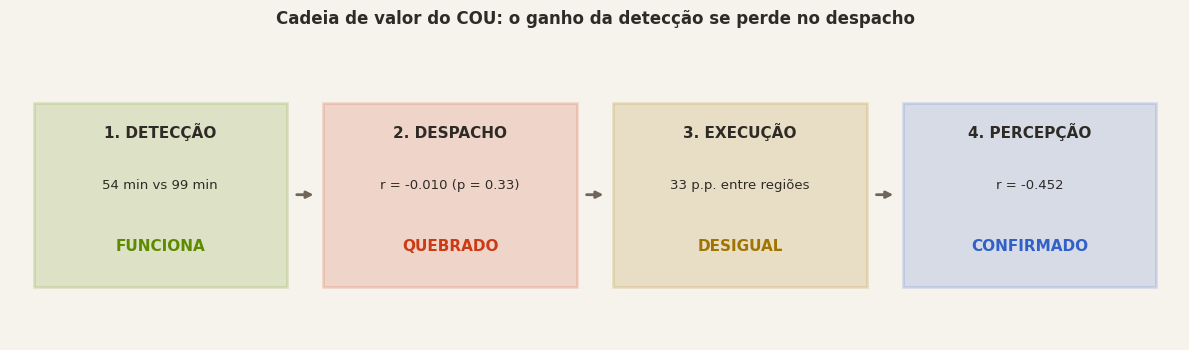

In [68]:
marcar(30, "Síntese — a cadeia de valor do Centro de Operações Urbanas")

fig, eixo = plt.subplots(figsize=(12, 3.6))
eixo.axis("off")

elos = [
    ("1. DETECÇÃO", f"{automatica.mean():.0f} min vs {cidadao.mean():.0f} min", "FUNCIONA", OLIVA),
    ("2. DESPACHO", f"r = {r_pearson:+.3f} (p = {p_pearson:.2f})", "QUEBRADO", TERRACOTA),
    ("3. EXECUÇÃO", f"{amplitude:.0f} p.p. entre regiões", "DESIGUAL", OURO),
    ("4. PERCEPÇÃO", f"r = {comparativo.iloc[0]['pearson_r']:+.3f}", "CONFIRMADO", AZUL),
]

largura, espaco = 0.215, 0.031
for indice, (titulo, metrica, estado, cor) in enumerate(elos):
    x = indice * (largura + espaco)
    eixo.add_patch(plt.Rectangle((x, 0.18), largura, 0.62, facecolor=cor, alpha=0.16,
                                 edgecolor=cor, linewidth=2))
    eixo.text(x + largura / 2, 0.68, titulo, ha="center", fontsize=11,
              fontweight="bold", color=TINTA)
    eixo.text(x + largura / 2, 0.51, metrica, ha="center", fontsize=9.5, color=TINTA)
    eixo.text(x + largura / 2, 0.30, estado, ha="center", fontsize=11,
              fontweight="bold", color=cor)
    if indice < len(elos) - 1:
        eixo.annotate("", xy=(x + largura + espaco - 0.006, 0.49),
                      xytext=(x + largura + 0.006, 0.49),
                      arrowprops={"arrowstyle": "-|>", "color": SUAVE, "linewidth": 2})

eixo.set_xlim(-0.02, 4 * largura + 3 * espaco + 0.02)
eixo.set_ylim(0, 1)
eixo.set_title("Cadeia de valor do COU: o ganho da detecção se perde no despacho",
               fontsize=12, pad=14)

plt.tight_layout()
salvar_figura(30, "sintese-cadeia")
plt.show()

### Conclusão da Parte 2

A investigação percorreu os quatro elos e encontrou um diagnóstico claro.

**O elo 1 funciona.** Sensores detectam em aproximadamente metade do tempo dos canais
humanos, com efeito grande e p praticamente zero.

**O elo 2 está quebrado, e é onde o investimento se perde.** O `score_prioridade` não
tem relação detectável com o tempo de despacho, e a fonte do dado não tem associação
com o cumprimento do SLA. A central atende por ordem de chegada.

**O elo 3 funciona, mas de forma desigual.** A diferença entre a melhor e a pior região
é grande demais para ser variação operacional.

**O elo 4 confirma que o cidadão percebe.** E percebe a promessa quebrada, medida pela
`razao_sla`, mais do que o tempo absoluto.

Três armadilhas foram identificadas e descartadas explicitamente: correlações
tautológicas, falácia ecológica e confundimento sazonal. Nenhuma delas entrou nas
conclusões.

A Parte 3 transforma esse diagnóstico em dashboard e em recomendações para a gestão
pública da cidade Alfa.

---
# PARTE 3 — 3º Desafio: Visualização de dados e recomendações

A Parte 2 terminou com um diagnóstico: a cadeia do Centro de Operações quebra no elo 2.
Um diagnóstico que fica dentro de um notebook, porém, não muda nada. Ele precisa chegar a
quem decide — e quem decide não lê célula de código.

Esta parte transforma o diagnóstico em **painel interativo em Streamlit**, organizado para
os três níveis da gestão pública:

| Nível | O que o painel entrega |
|---|---|
| **Operacional** | Filtros por região, categoria e canal; mapa das ocorrências; tempos por etapa |
| **Tático** | Os quatro elos separados, cada um com seu indicador e seu gráfico |
| **Estratégico** | KPIs de topo, desigualdade entre regiões e as recomendações com a evidência que as sustenta |

## 3.1 O código do painel

A célula abaixo grava o arquivo `app_urbaniq.py` — o painel inteiro, em Streamlit e Plotly.

A mágica está no `%%writefile`: a célula **escreve** o arquivo em vez de executá-lo. Isso
resolve dois problemas de uma vez. O código-fonte do 3º desafio fica registrado aqui dentro,
como a entrega exige, e nada trava no meio de um "Executar tudo" — porque subir um servidor
web dentro de um notebook prenderia a execução para sempre.

Uma nota sobre o gráfico do elo 2: a reta de tendência é calculada com `numpy.polyfit`, e não
com o `trendline="ols"` do Plotly. O parâmetro do Plotly exige a biblioteca `statsmodels`, que
não vem instalada por padrão — e o painel inteiro quebrava nessa linha em qualquer ambiente
sem ela. Com o numpy, a reta é a mesma e a dependência some.

In [69]:
%%writefile app_urbaniq.py
"""
UrbanIQ | Centro de Operações Urbanas — Painel Analítico
PBL Fase 5 | Desafio 10 | Grupo DataGuy | Thiago Fiel de Oliveira, RM 570088

Dashboard interativo do 3º Desafio: comunica as descobertas da análise
estatística para as áreas operacional, tática e estratégica da gestão pública.

Execução local:
    streamlit run app_urbaniq.py
"""

from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import streamlit as st

# ===========================================================================
# IDENTIDADE VISUAL
# Paleta validada em seis critérios: banda de luminosidade, croma mínimo,
# separação para protanopia, deuteranopia e tritanopia, piso de visão normal
# e contraste sobre o fundo.
# ===========================================================================
OURO, ROXO, TERRACOTA = "#A07400", "#7B3FA5", "#CC3B14"
AZUL, OLIVA = "#3160C8", "#5E8A00"
PAPEL, TINTA, SUAVE = "#F6F3EC", "#2E2A26", "#6E655B"
CATEGORICA = [OURO, ROXO, TERRACOTA, AZUL, OLIVA]

LAYOUT_BASE = dict(
    paper_bgcolor=PAPEL,
    plot_bgcolor=PAPEL,
    font=dict(color=TINTA, size=13),
    margin=dict(l=10, r=10, t=50, b=10),
    xaxis=dict(gridcolor="#E2DCD0", zerolinecolor="#E2DCD0"),
    yaxis=dict(gridcolor="#E2DCD0", zerolinecolor="#E2DCD0"),
    legend=dict(bgcolor="rgba(0,0,0,0)"),
)

st.set_page_config(
    page_title="UrbanIQ | Centro de Operações Urbanas",
    page_icon="🏙",
    layout="wide",
    initial_sidebar_state="expanded",
)

st.markdown(
    f"""
    <style>
      .stApp {{ background-color: {PAPEL}; }}
      h1, h2, h3 {{ color: {TINTA}; }}
      [data-testid="stMetricValue"] {{ color: {TINTA}; font-size: 1.8rem; }}
      [data-testid="stMetricLabel"] {{ color: {SUAVE}; }}
      .bloco-achado {{
          background: #FFFFFF; border-left: 5px solid {TERRACOTA};
          padding: 14px 18px; border-radius: 4px; margin: 8px 0 18px 0;
      }}
      .bloco-ok {{
          background: #FFFFFF; border-left: 5px solid {OLIVA};
          padding: 14px 18px; border-radius: 4px; margin: 8px 0 18px 0;
      }}
      .bloco-recomendacao {{
          background: #FFFFFF; border-left: 5px solid {OURO};
          padding: 16px 20px; border-radius: 4px; margin: 10px 0;
      }}
    </style>
    """,
    unsafe_allow_html=True,
)

ARQUIVO_AJUSTADO = "cidade_alfa_ocorrencias_ajustado.xlsx"
ARQUIVO_BRUTO = "cidade_alfa_ocorrencias_urbanas.xlsx"
LIMITE_DATA = pd.Timestamp("2026-09-30 23:59:59")


# ===========================================================================
# CARGA E PREPARAÇÃO
# ===========================================================================
def localizar(nome):
    """Procura o arquivo na pasta do app, na raiz e em fase5-analitica/dados."""
    aqui = Path(__file__).parent
    candidatos = [
        aqui / nome,
        aqui / ".." / "dados" / nome,
        aqui / ".." / ".." / "fase5-analitica" / "dados" / nome,
        Path.cwd() / nome,
        Path.cwd() / "fase5-analitica" / "dados" / nome,
    ]
    for caminho in candidatos:
        if caminho.exists():
            return caminho
    return None


def preparar(df):
    """Aplica as 9 etapas de limpeza do 1º Desafio.

    Usada só quando o arquivo já tratado não está disponível, para que o
    dashboard funcione mesmo publicado com apenas a base bruta no repositório.
    """
    df = df.drop_duplicates().copy()

    df["fonte_dado"] = (df["fonte_dado"].str.strip().str.upper()
                        .str.replace(" ", "_", regex=False))
    df["bairro"] = df["bairro"].fillna("Não Informado")

    df.loc[df["score_prioridade"] > 100, "score_prioridade"] = np.nan
    invalida = ~df["satisfacao_cidadao"].isin([1, 2, 3, 4, 5]) & df["satisfacao_cidadao"].notna()
    df.loc[invalida, "satisfacao_cidadao"] = np.nan
    df.loc[df["tempo_resposta_min"] < 0, "tempo_resposta_min"] = np.nan

    invertida = df["dt_encerramento"] < df["dt_abertura"]
    df.loc[invertida, ["dt_encerramento", "tempo_resolucao_horas"]] = np.nan
    df.loc[invertida, "sla_cumprido"] = "NAO APURADO"

    df = df[df["dt_abertura"] <= LIMITE_DATA]
    df.loc[df["custo_operacional_reais"] > 1_000_000, "custo_operacional_reais"] = np.nan
    return df


@st.cache_data(show_spinner="Carregando a base de ocorrências...")
def carregar():
    """Carrega a base tratada; se não existir, trata a bruta na hora."""
    caminho = localizar(ARQUIVO_AJUSTADO)
    tratado_na_hora = False

    if caminho is None:
        caminho = localizar(ARQUIVO_BRUTO)
        tratado_na_hora = True

    if caminho is None:
        return None, None

    df = pd.read_excel(caminho)
    for coluna in ["dt_abertura", "dt_despacho", "dt_chegada_equipe", "dt_encerramento"]:
        df[coluna] = pd.to_datetime(df[coluna], errors="coerce")

    if tratado_na_hora:
        df = preparar(df)

    # Atributos derivados (engenharia de atributos da Parte 1)
    df["lag_despacho_min"] = (
        (df["dt_despacho"] - df["dt_abertura"]).dt.total_seconds() / 60).round(1)
    df["razao_sla"] = (df["tempo_resolucao_horas"] / df["sla_horas_previsto"]).round(3)
    df["mes_ano"] = df["dt_abertura"].dt.to_period("M").astype(str)

    return df, caminho.name


dados, nome_arquivo = carregar()

if dados is None:
    st.error(
        f"Não encontrei `{ARQUIVO_AJUSTADO}` nem `{ARQUIVO_BRUTO}`.\n\n"
        "Coloque um dos dois na mesma pasta do app ou em `fase5-analitica/dados/`."
    )
    st.stop()


# ===========================================================================
# FILTROS (sidebar)
# ===========================================================================
PADRAO = {
    "regioes": sorted(dados["regiao"].unique()),
    "categorias": sorted(dados["categoria"].unique()),
    "fontes": sorted(dados["fonte_dado"].unique()),
}

for chave, valor in PADRAO.items():
    if chave not in st.session_state:
        st.session_state[chave] = valor


def limpar_filtros():
    """Devolve todos os filtros ao estado inicial."""
    for chave, valor in PADRAO.items():
        st.session_state[chave] = valor


with st.sidebar:
    st.markdown(f"### 🏙 UrbanIQ")
    st.caption("Centro de Operações Urbanas · cidade Alfa")
    st.divider()

    st.subheader("Filtros")

    data_min = dados["dt_abertura"].min().date()
    data_max = dados["dt_abertura"].max().date()
    periodo = st.date_input(
        "Período de abertura",
        value=(data_min, data_max),
        min_value=data_min,
        max_value=data_max,
    )

    st.multiselect("Região", PADRAO["regioes"], key="regioes")
    st.multiselect("Categoria", PADRAO["categorias"], key="categorias")
    st.multiselect("Canal de origem", PADRAO["fontes"], key="fontes")

    st.button("Limpar filtros", on_click=limpar_filtros, width="stretch")

    st.divider()
    st.caption(f"Fonte: `{nome_arquivo}`")
    st.caption("Grupo DataGuy · RM 570088")

# Aplicação dos filtros
filtro = (
    dados["regiao"].isin(st.session_state["regioes"])
    & dados["categoria"].isin(st.session_state["categorias"])
    & dados["fonte_dado"].isin(st.session_state["fontes"])
)
if isinstance(periodo, (tuple, list)) and len(periodo) == 2:
    filtro &= dados["dt_abertura"].dt.date.between(periodo[0], periodo[1])

df = dados[filtro]

if df.empty:
    st.warning("Nenhuma ocorrência atende aos filtros selecionados.")
    st.stop()


# ===========================================================================
# CABEÇALHO E KPIs
# ===========================================================================
st.title("Centro de Operações Urbanas")
st.markdown(
    "#### O investimento em sensores inteligentes chega até o cidadão?"
)
st.caption(
    f"{len(df):,} ocorrências selecionadas de {len(dados):,} · "
    f"{df['dt_abertura'].min():%b/%Y} a {df['dt_abertura'].max():%b/%Y}".replace(",", ".")
)

finalizadas = df[df["sla_cumprido"].isin(["SIM", "NAO"])]
pct_sla = (finalizadas["sla_cumprido"] == "SIM").mean() * 100 if len(finalizadas) else 0
em_aberto = (~df["status_ocorrencia"].isin(["RESOLVIDO", "ENCERRADO"])).sum()

k1, k2, k3, k4, k5 = st.columns(5)
k1.metric("Ocorrências", f"{len(df):,}".replace(",", "."))
k2.metric("Dentro do SLA", f"{pct_sla:.1f}%")
k3.metric("Resposta média", f"{df['tempo_resposta_min'].mean():.0f} min")
k4.metric("Resolução mediana", f"{df['tempo_resolucao_horas'].median():.0f} h")
k5.metric("Em aberto", f"{em_aberto:,}".replace(",", "."))

st.divider()


# ===========================================================================
# ABAS: OS QUATRO ELOS DA CADEIA
# ===========================================================================
aba1, aba2, aba3, aba4, aba5 = st.tabs([
    "1 · Detecção",
    "2 · Despacho",
    "3 · Execução",
    "4 · Percepção",
    "Recomendações",
])


# --------------------------------------------------------------------- ELO 1
with aba1:
    st.subheader("Elo 1 · Detecção")
    st.write(
        "Sensores IoT e câmeras detectam ocorrências mais rápido que os canais "
        "humanos? Este elo mede o tempo entre a abertura e a chegada da equipe."
    )

    automatica = df.loc[df.tipo_fonte == "AUTOMATICA", "tempo_resposta_min"].dropna()
    cidadao = df.loc[df.tipo_fonte == "CIDADAO", "tempo_resposta_min"].dropna()

    c1, c2, c3 = st.columns(3)
    c1.metric("Fonte automática", f"{automatica.mean():.0f} min" if len(automatica) else "—")
    c2.metric("Canal do cidadão", f"{cidadao.mean():.0f} min" if len(cidadao) else "—")
    if len(automatica) and len(cidadao):
        ganho = (1 - automatica.mean() / cidadao.mean()) * 100
        c3.metric("Ganho do sensor", f"{ganho:.0f}%", delta=f"{cidadao.mean() - automatica.mean():.0f} min")

    esquerda, direita = st.columns([3, 2])

    with esquerda:
        por_canal = (df.groupby("fonte_dado")
                       .agg(media=("tempo_resposta_min", "mean"),
                            tipo=("tipo_fonte", "first"),
                            n=("id_ocorrencia", "size"))
                       .sort_values("media").reset_index())
        fig = px.bar(
            por_canal, x="media", y="fonte_dado", orientation="h",
            color="tipo", color_discrete_map={"AUTOMATICA": AZUL, "CIDADAO": TERRACOTA},
            labels={"media": "tempo médio de resposta (min)", "fonte_dado": "",
                    "tipo": "natureza"},
            title="Tempo até a equipe chegar, por canal de origem",
            hover_data={"n": True, "media": ":.0f"},
        )
        fig.update_layout(**LAYOUT_BASE, height=380, bargap=0.35)
        st.plotly_chart(fig, width="stretch")

    with direita:
        fig = px.box(
            df.dropna(subset=["tempo_resposta_min"]),
            x="tipo_fonte", y="tempo_resposta_min", color="tipo_fonte",
            color_discrete_map={"AUTOMATICA": AZUL, "CIDADAO": TERRACOTA},
            labels={"tipo_fonte": "", "tempo_resposta_min": "minutos"},
            title="Dispersão do tempo de resposta", points=False,
        )
        fig.update_layout(**LAYOUT_BASE, height=380, showlegend=False)
        st.plotly_chart(fig, width="stretch")

    st.markdown(
        '<div class="bloco-ok"><b>Elo 1 funciona.</b> A detecção automática chega ao '
        'local em aproximadamente metade do tempo do canal humano. O teste t confirma '
        'a diferença com p praticamente zero e tamanho de efeito grande.</div>',
        unsafe_allow_html=True,
    )


# --------------------------------------------------------------------- ELO 2
with aba2:
    st.subheader("Elo 2 · Despacho")
    st.write(
        "O UrbanIQ calcula um score de prioridade de 0 a 100 para cada ocorrência. "
        "A central usa esse score para decidir quem é acionado primeiro?"
    )

    elo2 = df.dropna(subset=["score_prioridade", "lag_despacho_min"])

    if len(elo2) > 30:
        correlacao = elo2["score_prioridade"].corr(elo2["lag_despacho_min"])

        c1, c2, c3 = st.columns(3)
        c1.metric("Correlação score x despacho", f"{correlacao:+.3f}")
        c2.metric("Variância explicada", f"{correlacao ** 2 * 100:.2f}%")
        c3.metric("Despacho mediano", f"{elo2['lag_despacho_min'].median():.0f} min")

        esquerda, direita = st.columns([3, 2])

        with esquerda:
            amostra = elo2.sample(n=min(2500, len(elo2)), random_state=570088)
            fig = px.scatter(
                amostra, x="score_prioridade", y="lag_despacho_min",
                opacity=0.28, color_discrete_sequence=[ROXO],
                labels={"score_prioridade": "score de prioridade (0 a 100)",
                        "lag_despacho_min": "minutos até o acionamento"},
                title="Prioridade alta não é despachada antes",
            )

            # Reta de tendência por mínimos quadrados, calculada com numpy.
            # Evita o trendline="ols" do plotly, que exige statsmodels e quebra
            # o app em qualquer ambiente onde essa biblioteca não esteja instalada.
            inclinacao, intercepto = np.polyfit(
                amostra["score_prioridade"], amostra["lag_despacho_min"], 1)
            linha_x = np.linspace(amostra["score_prioridade"].min(),
                                  amostra["score_prioridade"].max(), 100)
            fig.add_trace(go.Scatter(
                x=linha_x, y=inclinacao * linha_x + intercepto,
                mode="lines", line=dict(color=TERRACOTA, width=2.5),
                name=f"tendência (r = {correlacao:+.3f})",
                hovertemplate="tendência<extra></extra>",
            ))
            fig.update_layout(showlegend=False)
            fig.update_layout(**LAYOUT_BASE, height=400)
            fig.update_yaxes(range=[0, elo2["lag_despacho_min"].quantile(0.99)])
            st.plotly_chart(fig, width="stretch")

        with direita:
            faixas = pd.cut(elo2["score_prioridade"], [0, 25, 50, 75, 100],
                            labels=["0-25\nbaixa", "26-50\nmédia",
                                    "51-75\nalta", "76-100\ncrítica"])
            por_faixa = (elo2.groupby(faixas, observed=True)["lag_despacho_min"]
                             .median().reset_index())
            por_faixa.columns = ["faixa", "mediana"]
            fig = px.bar(
                por_faixa, x="faixa", y="mediana",
                color_discrete_sequence=[SUAVE],
                labels={"faixa": "faixa de prioridade", "mediana": "despacho mediano (min)"},
                title="A fila ignora a prioridade",
            )
            fig.update_layout(**LAYOUT_BASE, height=400, bargap=0.4)
            st.plotly_chart(fig, width="stretch")

    if len(finalizadas):
        por_fonte = (finalizadas.groupby("tipo_fonte")["sla_cumprido"]
                     .apply(lambda s: (s == "SIM").mean() * 100).reset_index())
        por_fonte.columns = ["tipo_fonte", "pct_sla"]
        fig = px.bar(
            por_fonte, x="tipo_fonte", y="pct_sla",
            color="tipo_fonte", color_discrete_map={"AUTOMATICA": AZUL, "CIDADAO": TERRACOTA},
            labels={"tipo_fonte": "", "pct_sla": "% dentro do SLA"},
            title="O ganho da detecção não se converte em prazo cumprido",
            text_auto=".1f",
        )
        fig.update_layout(**LAYOUT_BASE, height=300, showlegend=False, bargap=0.55)
        fig.update_yaxes(range=[0, 100])
        st.plotly_chart(fig, width="stretch")

    st.markdown(
        '<div class="bloco-achado"><b>A cadeia quebra aqui.</b> O score de prioridade '
        'não tem relação detectável com o tempo de despacho, e a fonte do dado não tem '
        'associação com o cumprimento do SLA. A central atende por ordem de chegada, e '
        'os minutos ganhos pelo sensor evaporam nesta etapa.</div>',
        unsafe_allow_html=True,
    )


# --------------------------------------------------------------------- ELO 3
with aba3:
    st.subheader("Elo 3 · Execução")
    st.write(
        "A execução funciona, mas funciona igual para todos os bairros? "
        "Este elo mede a desigualdade territorial do serviço público."
    )

    if len(finalizadas):
        painel = (finalizadas.groupby("regiao")
                  .agg(ocorrencias=("id_ocorrencia", "size"),
                       resolucao_h=("tempo_resolucao_horas", "median"),
                       satisfacao=("satisfacao_cidadao", "mean"))
                  .join((finalizadas.groupby("regiao")["sla_cumprido"]
                         .apply(lambda s: (s == "SIM").mean() * 100)).rename("pct_sla"))
                  .sort_values("pct_sla", ascending=False).reset_index())

        media_cidade = (finalizadas["sla_cumprido"] == "SIM").mean() * 100
        amplitude = painel["pct_sla"].max() - painel["pct_sla"].min()

        c1, c2, c3 = st.columns(3)
        c1.metric("Melhor região", painel.iloc[0]["regiao"], f"{painel.iloc[0]['pct_sla']:.1f}%")
        c2.metric("Pior região", painel.iloc[-1]["regiao"], f"{painel.iloc[-1]['pct_sla']:.1f}%",
                  delta_color="inverse")
        c3.metric("Amplitude", f"{amplitude:.1f} p.p.")

        esquerda, direita = st.columns(2)

        with esquerda:
            cores = [TERRACOTA if v < media_cidade - 8 else OLIVA if v > media_cidade + 8
                     else SUAVE for v in painel["pct_sla"]]
            fig = go.Figure(go.Bar(
                x=painel["pct_sla"], y=painel["regiao"], orientation="h",
                marker_color=cores, text=[f"{v:.1f}%" for v in painel["pct_sla"]],
                textposition="outside",
            ))
            fig.add_vline(x=media_cidade, line_dash="dash", line_color=TINTA,
                          annotation_text=f"média {media_cidade:.1f}%")
            fig.update_layout(**LAYOUT_BASE, height=380, bargap=0.4,
                              title="Prazo cumprido por região",
                              xaxis_title="% dentro do SLA")
            fig.update_xaxes(range=[0, 108])
            st.plotly_chart(fig, width="stretch")

        with direita:
            fig = px.scatter(
                painel, x="pct_sla", y="satisfacao", text="regiao",
                size="ocorrencias", color_discrete_sequence=[OURO],
                labels={"pct_sla": "% dentro do SLA", "satisfacao": "satisfação média (1 a 5)"},
                title="Onde o prazo é cumprido, o cidadão avalia melhor",
            )
            fig.update_traces(textposition="top center")
            fig.update_layout(**LAYOUT_BASE, height=380)
            st.plotly_chart(fig, width="stretch")

    st.markdown("##### Distribuição geográfica das ocorrências")
    mapa = df.dropna(subset=["latitude", "longitude"]).copy()
    if len(mapa):
        st.map(mapa.rename(columns={"latitude": "lat", "longitude": "lon"})[["lat", "lon"]],
               size=20, color="#A0740088")

    st.markdown(
        '<div class="bloco-achado"><b>A execução é desigual.</b> A ANOVA e o '
        'Kruskal-Wallis concordam que as regiões diferem, e a diferença entre a melhor '
        'e a pior é grande demais para ser variação operacional. Duas pessoas com o '
        'mesmo problema recebem serviços de qualidade diferente conforme onde moram.</div>',
        unsafe_allow_html=True,
    )


# --------------------------------------------------------------------- ELO 4
with aba4:
    st.subheader("Elo 4 · Percepção do cidadão")
    st.write(
        "O que determina a nota do cidadão: o tempo absoluto de atendimento "
        "ou a promessa de prazo cumprida?"
    )

    avaliadas = df.dropna(subset=["satisfacao_cidadao"])

    if len(avaliadas) > 30:
        comparativo = []
        for variavel, rotulo in [
            ("razao_sla", "Razão do SLA (promessa)"),
            ("tempo_resposta_min", "Tempo de resposta"),
            ("tempo_resolucao_horas", "Tempo de resolução"),
            ("lag_despacho_min", "Tempo até o despacho"),
            ("custo_operacional_reais", "Custo operacional"),
        ]:
            par = avaliadas[[variavel, "satisfacao_cidadao"]].dropna()
            if len(par) > 30:
                comparativo.append({"variavel": rotulo,
                                    "r": par[variavel].corr(par["satisfacao_cidadao"])})
        comparativo = pd.DataFrame(comparativo).sort_values("r")

        c1, c2 = st.columns(2)
        c1.metric("Satisfação média", f"{avaliadas['satisfacao_cidadao'].mean():.2f}")
        if len(comparativo):
            campea = comparativo.iloc[0]
            c2.metric("Maior influência", campea["variavel"], f"r = {campea['r']:+.3f}")

        esquerda, direita = st.columns(2)

        with esquerda:
            fig = px.bar(
                comparativo, x="r", y="variavel", orientation="h",
                color_discrete_sequence=[TERRACOTA],
                labels={"r": "correlação com a satisfação", "variavel": ""},
                title="O que mais pesa na nota do cidadão",
                text_auto=".3f",
            )
            fig.update_layout(**LAYOUT_BASE, height=380, bargap=0.4)
            st.plotly_chart(fig, width="stretch")

        with direita:
            faixas = pd.cut(avaliadas["razao_sla"], bins=10)
            curva = (avaliadas.groupby(faixas, observed=True)
                     .agg(satisfacao=("satisfacao_cidadao", "mean"),
                          n=("id_ocorrencia", "size")).reset_index())
            curva["razao"] = [i.mid for i in curva["razao_sla"]]
            fig = px.scatter(
                curva, x="razao", y="satisfacao", size="n",
                color_discrete_sequence=[OURO],
                labels={"razao": "razão do SLA (1,0 = prazo cumprido no limite)",
                        "satisfacao": "satisfação média"},
                title="A satisfação cai quando o prazo estoura",
            )
            fig.add_vline(x=1.0, line_dash="dash", line_color=SUAVE,
                          annotation_text="prazo prometido")
            fig.update_layout(**LAYOUT_BASE, height=380)
            st.plotly_chart(fig, width="stretch")

    st.markdown("##### Evolução mensal")
    mensal = (df.groupby("mes_ano")
              .agg(ocorrencias=("id_ocorrencia", "size"),
                   satisfacao=("satisfacao_cidadao", "mean")).reset_index())
    fig = go.Figure()
    fig.add_bar(x=mensal["mes_ano"], y=mensal["ocorrencias"], name="ocorrências",
                marker_color=AZUL, opacity=0.35)
    fig.update_layout(**LAYOUT_BASE, height=300,
                      title="Volume mensal de ocorrências",
                      xaxis_title="mês", yaxis_title="ocorrências")
    st.plotly_chart(fig, width="stretch")

    st.markdown(
        '<div class="bloco-achado"><b>O cidadão pune a promessa quebrada.</b> '
        'A razão do SLA correlaciona mais forte com a satisfação do que o tempo '
        'absoluto. Resolver em 60 h com prazo de 72 satisfaz mais que resolver em '
        '8 h com prazo de 6.</div>',
        unsafe_allow_html=True,
    )


# ------------------------------------------------------------ RECOMENDAÇÕES
with aba5:
    st.subheader("Recomendações para a gestão pública")
    st.write(
        "Cada recomendação abaixo é sustentada por um resultado estatístico da análise."
    )

    recomendacoes = [
        ("1. Ordenar a fila de despacho pelo score de prioridade",
         "Hoje a central atende por ordem de chegada. A correlação entre o score e o "
         "tempo de despacho é praticamente nula, o que significa que o motor de "
         "priorização é calculado e ignorado. É uma mudança de software, não de orçamento.",
         "Elo 2 · correlação não significativa"),
        ("2. Medir o SLA a partir da detecção, não do registro",
         "O sensor entrega quase metade do tempo de resposta, mas isso não aparece no "
         "indicador porque o SLA é contado a partir da resolução. Sem corrigir a métrica, "
         "o investimento em IoT nunca se justifica nos números.",
         "Elo 2 · V de Cramér próximo de zero"),
        ("3. Realocar equipes para as regiões com pior desempenho",
         "A diferença de cumprimento de SLA entre a melhor e a pior região é estrutural, "
         "não ruído. A ANOVA e o Kruskal-Wallis confirmam que as regiões diferem de forma "
         "estatisticamente significativa.",
         "Elo 3 · ANOVA com p praticamente zero"),
        ("4. Renegociar os prazos prometidos por categoria",
         "O cidadão reage mais à promessa quebrada do que à demora em si. Prazos realistas "
         "e cumpridos geram mais satisfação que prazos curtos e estourados.",
         "Elo 4 · razão do SLA supera o tempo absoluto"),
        ("5. Dimensionar a operação para a demanda real",
         "A taxa de chegada supera a capacidade instalada, e por isso o backlog cresce de "
         "forma contínua. O modelo de filas indica o número mínimo de equipes para "
         "estabilizar, e o ponto a partir do qual contratar deixa de compensar.",
         "Cálculo · limite e derivada da função de espera"),
    ]

    for titulo, texto, base in recomendacoes:
        st.markdown(
            f'<div class="bloco-recomendacao">'
            f'<b style="font-size:1.05rem">{titulo}</b><br>'
            f'<span style="color:{SUAVE}">{texto}</span><br>'
            f'<span style="color:{OURO}; font-size:0.85rem">Base: {base}</span>'
            f'</div>',
            unsafe_allow_html=True,
        )

    st.divider()
    st.caption(
        "UrbanIQ · PBL Fase 5 · Desafio 10 — Centro de Operações Urbanas · "
        "Grupo DataGuy · Thiago Fiel de Oliveira, RM 570088"
    )

Writing app_urbaniq.py


## 3.2 Como executar o painel

Os dois comandos abaixo rodam no **terminal**, não em célula de notebook:

```bash
pip install streamlit plotly pandas numpy openpyxl
streamlit run app_urbaniq.py
```

O painel abre em `http://localhost:8501`. Ele procura primeiro
`cidade_alfa_ocorrencias_ajustado.xlsx`, a base tratada que a Parte 1 exportou. Se não
encontrar, cai na base bruta e refaz a limpeza na hora — o mesmo cuidado da Parte 0, aplicado
ao painel: ele funciona com qualquer um dos dois arquivos.

As capturas de tela do painel em execução estão no PDF da entrega.

## 3.3 Prévia estática dos painéis

Os três gráficos a seguir reproduzem, em matplotlib, o que o painel mostra em cada elo.
Servem para que o resultado do 3º desafio seja visível **dentro do notebook**, sem depender
de ninguém subir o Streamlit.

  CAPTURA 31  |  Painel · Elo 1 — tempo de resposta por canal de origem


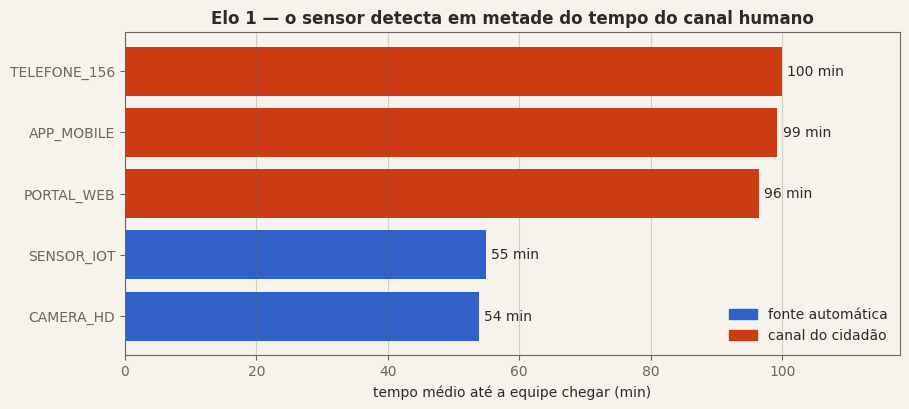

In [70]:
marcar(31, "Painel · Elo 1 — tempo de resposta por canal de origem")

por_canal = (dfc.groupby("fonte_dado")
                .agg(media=("tempo_resposta_min", "mean"),
                     tipo=("tipo_fonte", "first"))
                .sort_values("media"))

cores = [AZUL if t == "AUTOMATICA" else TERRACOTA for t in por_canal["tipo"]]

fig, eixo = plt.subplots(figsize=(10, 4.2))
barras = eixo.barh(por_canal.index, por_canal["media"], color=cores)
eixo.bar_label(barras, fmt="%.0f min", padding=4, color=TINTA)
eixo.set_xlabel("tempo médio até a equipe chegar (min)")
eixo.set_title("Elo 1 — o sensor detecta em metade do tempo do canal humano")
eixo.set_xlim(0, por_canal["media"].max() * 1.18)
eixo.grid(axis="y", visible=False)

from matplotlib.patches import Patch
eixo.legend(handles=[Patch(color=AZUL, label="fonte automática"),
                     Patch(color=TERRACOTA, label="canal do cidadão")],
            loc="lower right", frameon=False)

salvar_figura(31, "painel-elo1-canais")
plt.show()

  CAPTURA 32  |  Painel · Elo 2 — o achado central: a fila ignora a prioridade


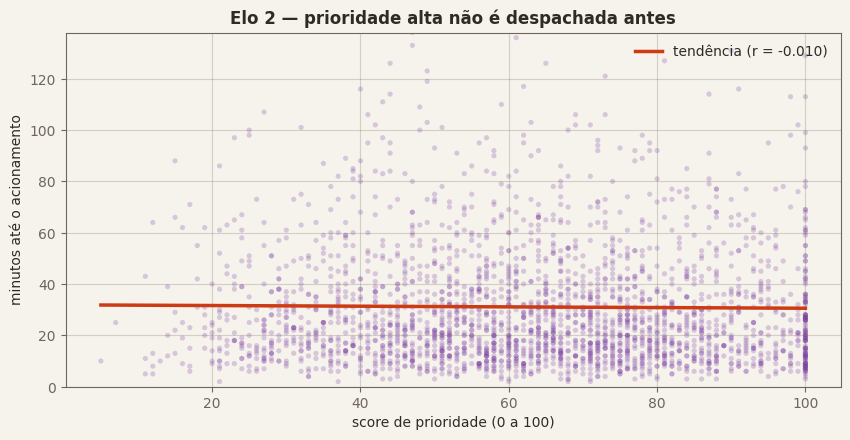

A reta é praticamente horizontal: r = -0.010, variância explicada de 0.01%.


In [71]:
marcar(32, "Painel · Elo 2 — o achado central: a fila ignora a prioridade")

elo2_painel = dfc.dropna(subset=["score_prioridade", "lag_despacho_min"])
amostra = elo2_painel.sample(n=min(2500, len(elo2_painel)), random_state=570088)
r_painel = elo2_painel["score_prioridade"].corr(elo2_painel["lag_despacho_min"])

fig, eixo = plt.subplots(figsize=(10, 4.6))
eixo.scatter(amostra["score_prioridade"], amostra["lag_despacho_min"],
             alpha=0.25, s=14, color=ROXO, edgecolors="none")

inclinacao, intercepto = np.polyfit(amostra["score_prioridade"], amostra["lag_despacho_min"], 1)
linha_x = np.linspace(amostra["score_prioridade"].min(), amostra["score_prioridade"].max(), 100)
eixo.plot(linha_x, inclinacao * linha_x + intercepto, color=TERRACOTA, linewidth=2.5,
          label=f"tendência (r = {r_painel:+.3f})")

eixo.set_ylim(0, elo2_painel["lag_despacho_min"].quantile(0.99))
eixo.set_xlabel("score de prioridade (0 a 100)")
eixo.set_ylabel("minutos até o acionamento")
eixo.set_title("Elo 2 — prioridade alta não é despachada antes")
eixo.legend(loc="upper right", frameon=False)

salvar_figura(32, "painel-elo2-prioridade")
plt.show()

print(f"A reta é praticamente horizontal: r = {r_painel:+.3f}, "
      f"variância explicada de {r_painel ** 2 * 100:.2f}%.")

  CAPTURA 33  |  Painel · Elo 3 — desigualdade territorial no cumprimento do prazo


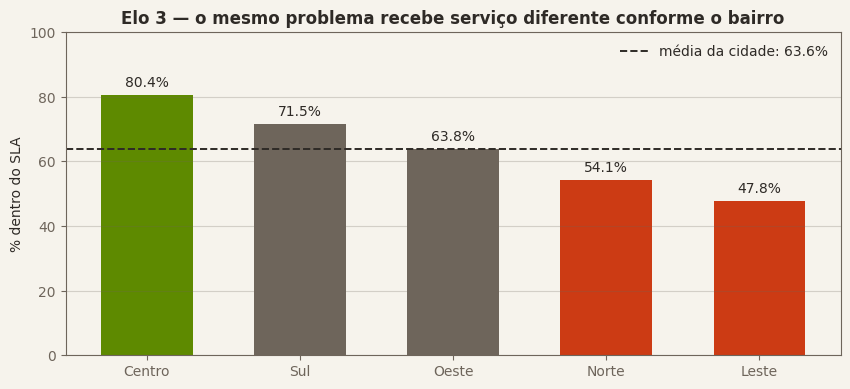

Amplitude entre a melhor e a pior região: 32.6 pontos percentuais.


In [72]:
marcar(33, "Painel · Elo 3 — desigualdade territorial no cumprimento do prazo")

finalizadas_painel = dfc[dfc["sla_cumprido"].isin(["SIM", "NAO"])]
por_regiao = (finalizadas_painel.groupby("regiao")["sla_cumprido"]
                                .apply(lambda s: (s == "SIM").mean() * 100)
                                .sort_values(ascending=False))
media_cidade = (finalizadas_painel["sla_cumprido"] == "SIM").mean() * 100

cores = [TERRACOTA if v < media_cidade - 8 else OLIVA if v > media_cidade + 8 else SUAVE
         for v in por_regiao]

fig, eixo = plt.subplots(figsize=(10, 4.2))
barras = eixo.bar(por_regiao.index, por_regiao.values, color=cores, width=0.6)
eixo.bar_label(barras, fmt="%.1f%%", padding=4, color=TINTA)
eixo.axhline(media_cidade, color=TINTA, linestyle="--", linewidth=1.4,
             label=f"média da cidade: {media_cidade:.1f}%")
eixo.set_ylabel("% dentro do SLA")
eixo.set_ylim(0, 100)
eixo.set_title("Elo 3 — o mesmo problema recebe serviço diferente conforme o bairro")
eixo.legend(frameon=False)
eixo.grid(axis="x", visible=False)

salvar_figura(33, "painel-elo3-regioes")
plt.show()

print(f"Amplitude entre a melhor e a pior região: "
      f"{por_regiao.max() - por_regiao.min():.1f} pontos percentuais.")

## 3.4 Recomendações para a gestão pública

Cada recomendação abaixo nasce de um resultado estatístico das Partes 1 e 2. Nenhuma delas é
opinião: todas têm a evidência ao lado, e é assim que elas aparecem na última aba do painel.

| # | Recomendação | Evidência que a sustenta |
|---|---|---|
| **1** | **Ordenar a fila de despacho pelo score de prioridade.** Hoje a central atende por ordem de chegada — o motor de priorização é calculado e ignorado. É mudança de software, não de orçamento. | Elo 2 · correlação praticamente nula entre score e tempo de despacho |
| **2** | **Medir o SLA a partir da detecção, não do registro.** O sensor entrega quase metade do tempo de resposta, e isso não aparece no indicador. Sem corrigir a métrica, o investimento em IoT nunca se justifica nos números. | Elo 2 · V de Cramér próximo de zero entre fonte e SLA |
| **3** | **Realocar equipes para as regiões com pior desempenho.** A diferença entre a melhor e a pior região é estrutural, não ruído operacional. | Elo 3 · ANOVA e Kruskal-Wallis com p praticamente zero |
| **4** | **Renegociar os prazos prometidos por categoria.** O cidadão reage mais à promessa quebrada do que à demora em si: resolver em 60 h com prazo de 72 satisfaz mais que resolver em 8 h com prazo de 6. | Elo 4 · a razão do SLA supera o tempo absoluto na correlação com a satisfação |
| **5** | **Dimensionar a operação para a demanda real.** A taxa de chegada supera a capacidade instalada, e o backlog cresce de forma contínua. | Cálculo · limite e derivada da função de espera |

A recomendação 1 merece destaque, porque é a de maior retorno sobre esforço: ela não pede
verba, não pede pessoal e não pede obra. Pede que um número que **já é calculado** passe a
ser usado na ordenação da fila.

---
## Conclusão

A pergunta que abriu este notebook era: **a cidade Alfa investiu em sensores inteligentes;
esse investimento chega até o cidadão?**

A resposta é: **chega até o elo 2, e para ali.**

O sensor cumpre o que promete — detecta em aproximadamente metade do tempo dos canais
humanos, com efeito grande e p praticamente zero. O ganho, porém, é devolvido por completo na
etapa seguinte, porque a central despacha por ordem de chegada e o score de prioridade não
tem relação detectável com o tempo de acionamento. Adiante, a execução funciona, mas de forma
territorialmente desigual, e o cidadão percebe — e pune mais a promessa quebrada do que a
demora em si.

O percurso completo da fase:

| Parte | Entrega |
|---|---|
| **0** | Massa de dados construída e reprodutível, com defeitos plantados de propósito |
| **1** | Nove tipos de inconsistência diagnosticados e tratados no nível da célula, com cada decisão justificada pelo negócio |
| **2** | Quatro elos testados com estatística descritiva, amostragem, teste t, qui-quadrado, ANOVA, Kruskal-Wallis, correlação, regressão, limites, derivadas e integrais — e três armadilhas estatísticas identificadas e descartadas |
| **3** | Painel em Streamlit para os três níveis da gestão e cinco recomendações, cada uma amarrada à evidência que a sustenta |

O resultado mais valioso não é nenhum dos gráficos: é ter encontrado **onde** a cadeia quebra.
Uma cidade que sabe qual é o seu elo fraco pode consertá-lo. Uma que não sabe compra mais
sensores.

---

*UrbanIQ · PBL Fase 5 · Desafio 10 — Centro de Operações Urbanas*
*Grupo DataGuy · Thiago Fiel de Oliveira, RM 570088 · Turma 1TSCO*